Import Library 

In [91]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import scipy

from scipy import stats
from scipy.stats import norm, skew, boxcox
from collections import Counter

from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.metrics import mean_squared_error, accuracy_score, auc
from sklearn.base import BaseEstimator, TransformerMixin, RegressorMixin, clone

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier, Pool
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier


#XGBOOST
from xgboost import XGBClassifier

#warning
import warnings
warnings.filterwarnings('ignore')

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/heart_failure_clinical_records_dataset.csv


In [92]:
data = pd.read_csv("/kaggle/input/heart_failure_clinical_records_dataset.csv")

In [93]:
#The Columns
print("Data Columns --> ",data.columns)

Data Columns -->  Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time',
       'DEATH_EVENT'],
      dtype='object')


In [94]:
data.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [95]:
desc = data.describe()
desc

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


In [96]:
print(data.isna().sum())

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [97]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [98]:
def plot_hist(variable):
    print("min {} : {} ".format(variable, min(data[variable])))
    print("max {} : {}".format(variable, max(data[variable])))
    
    plt.figure(figsize=(9,3))
    plt.hist(data[variable], color="darkred")
    plt.xlabel(variable)
    plt.ylabel("Frequency")
    plt.title("{} distribution with hist ".format(variable))
    plt.show()

min age : 40.0 
max age : 95.0


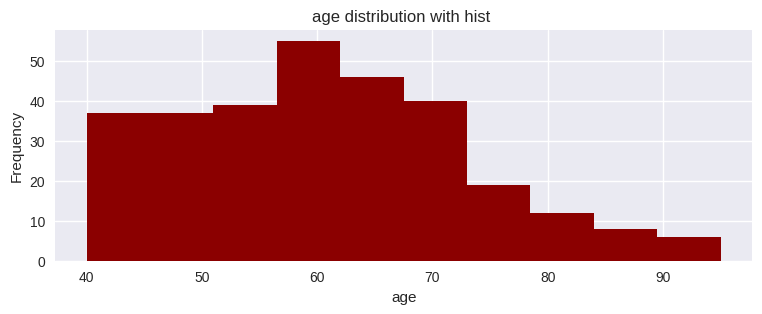

min creatinine_phosphokinase : 23 
max creatinine_phosphokinase : 7861


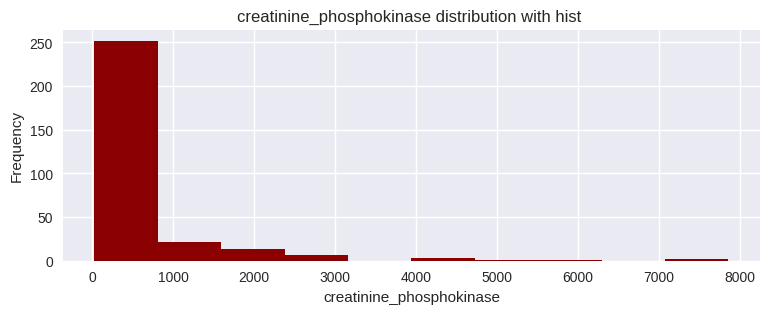

min ejection_fraction : 14 
max ejection_fraction : 80


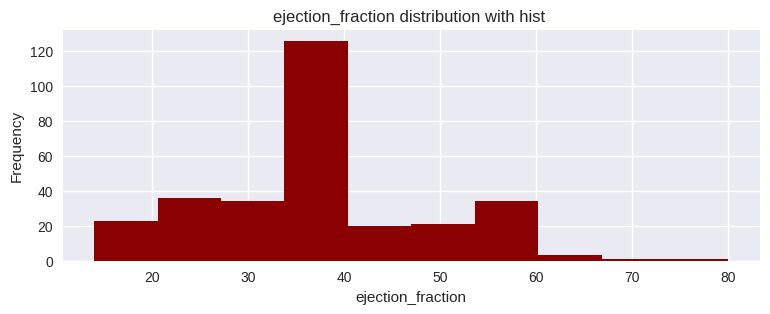

min platelets : 25100.0 
max platelets : 850000.0


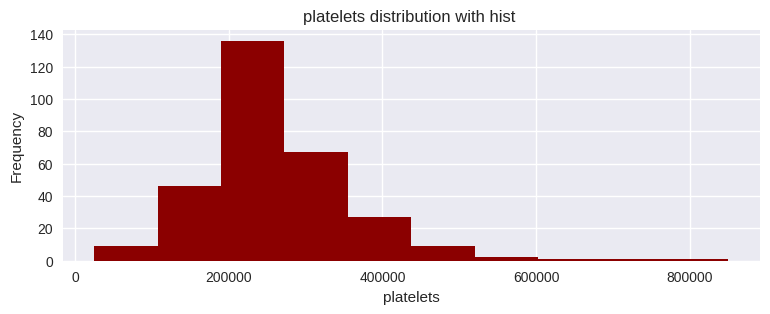

min serum_creatinine : 0.5 
max serum_creatinine : 9.4


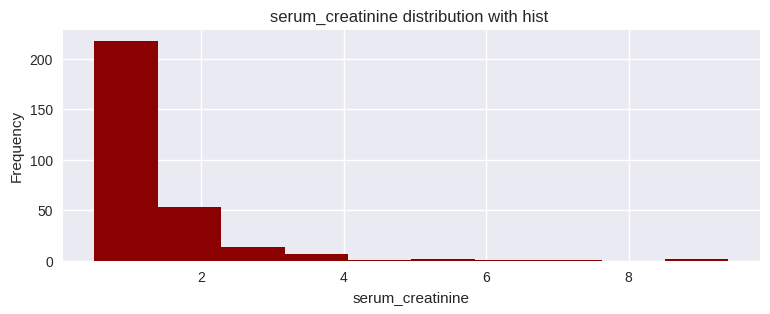

min serum_sodium : 113 
max serum_sodium : 148


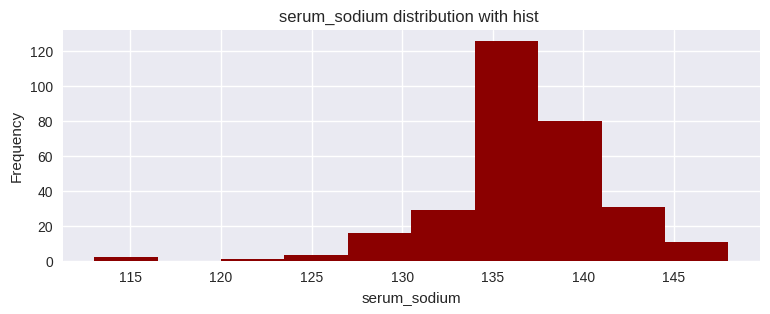

min time : 4 
max time : 285


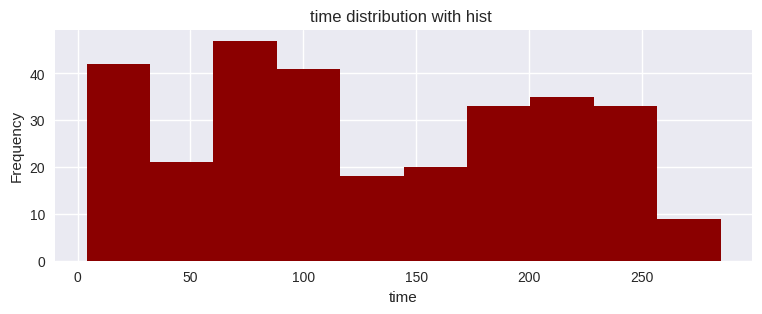

In [99]:
numericVar = ["age","creatinine_phosphokinase","ejection_fraction","platelets","serum_creatinine","serum_sodium","time"]
for n in numericVar:
    plot_hist(n)

In [100]:
def bar_plot(variable):
    
    # get feature
    var = data[variable]
    #count number of categorical variable (value/sample)
    varValue = var.value_counts()

    #visualize
    plt.figure(figsize=(9,3))
    plt.bar(varValue.index, varValue,color = "lightgreen", edgecolor = "black", linewidth = 2)
    plt.xticks(varValue.index, varValue.index.values)
    plt.ylabel("frequency")
    plt.title(variable)
    plt.show()
    print("{}: \n {}".format(variable,varValue))

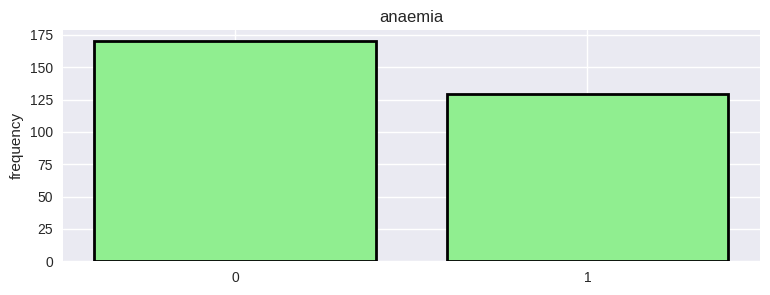

anaemia: 
 anaemia
0    170
1    129
Name: count, dtype: int64


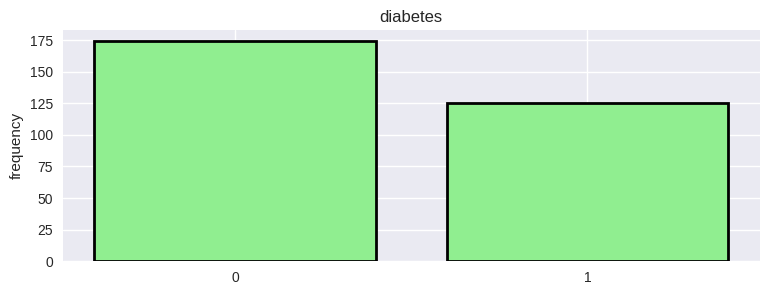

diabetes: 
 diabetes
0    174
1    125
Name: count, dtype: int64


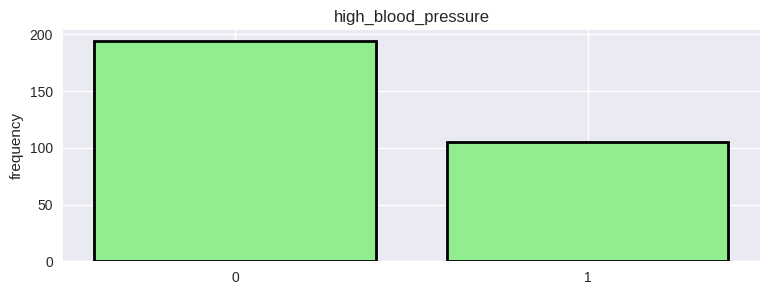

high_blood_pressure: 
 high_blood_pressure
0    194
1    105
Name: count, dtype: int64


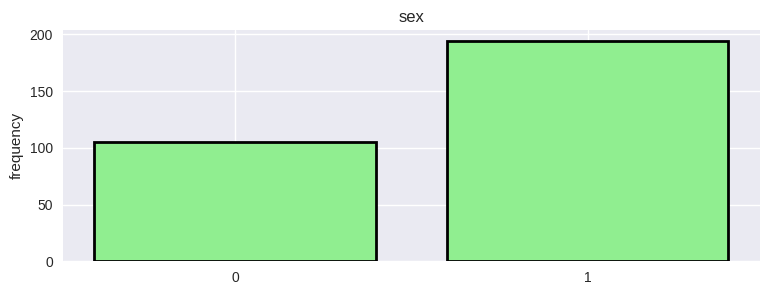

sex: 
 sex
1    194
0    105
Name: count, dtype: int64


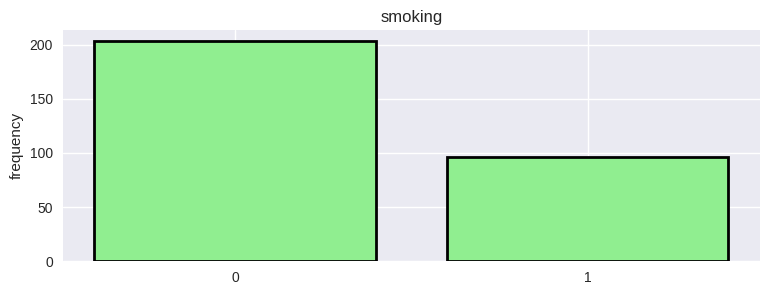

smoking: 
 smoking
0    203
1     96
Name: count, dtype: int64


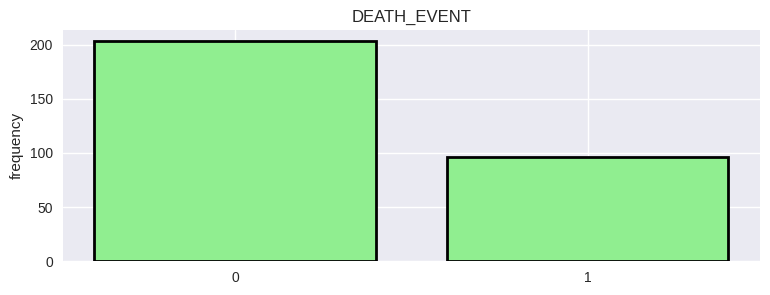

DEATH_EVENT: 
 DEATH_EVENT
0    203
1     96
Name: count, dtype: int64


In [101]:
category = ["anaemia","diabetes","high_blood_pressure","sex","smoking","DEATH_EVENT"]
for c in category:
    bar_plot(c)

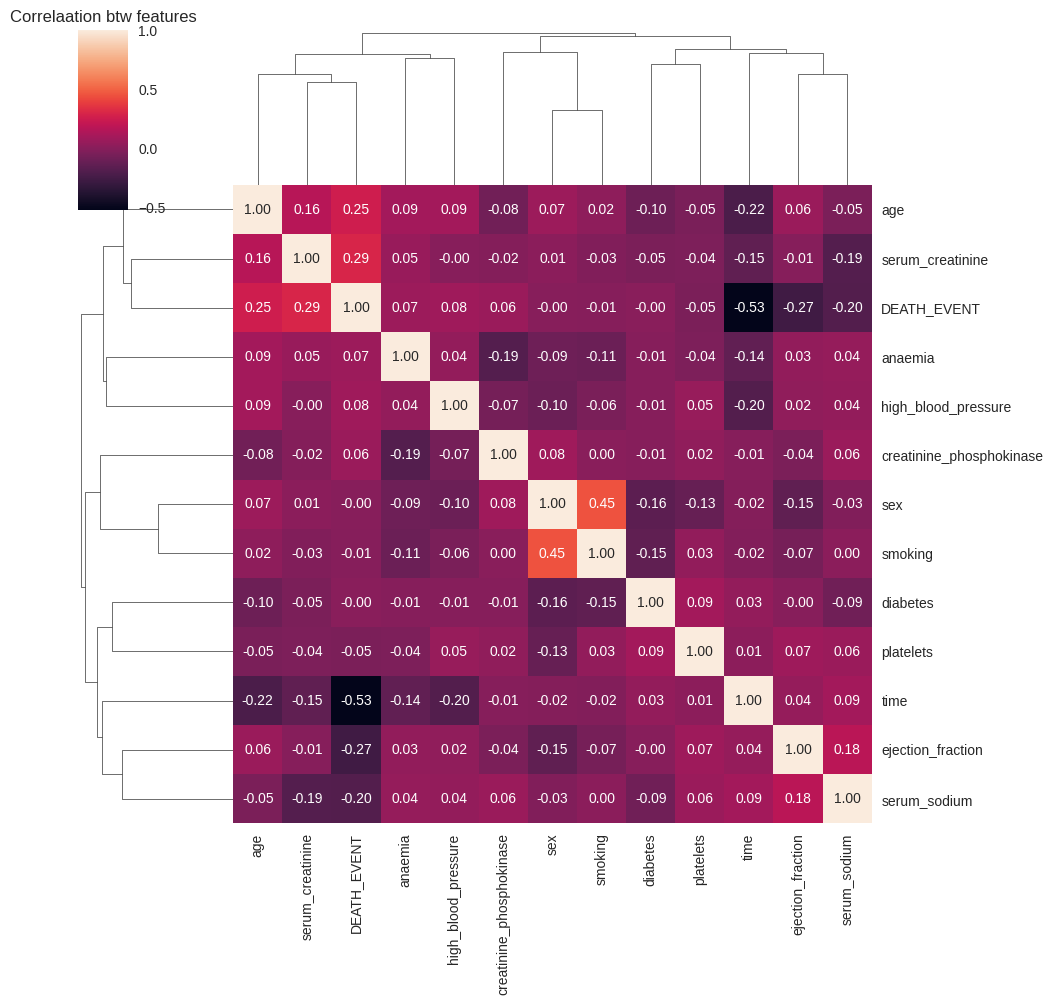

In [102]:
corr_matrix = data.corr()
sns.clustermap(corr_matrix, annot = True, fmt = ".2f")
plt.title("Correlaation btw features")
plt.show()

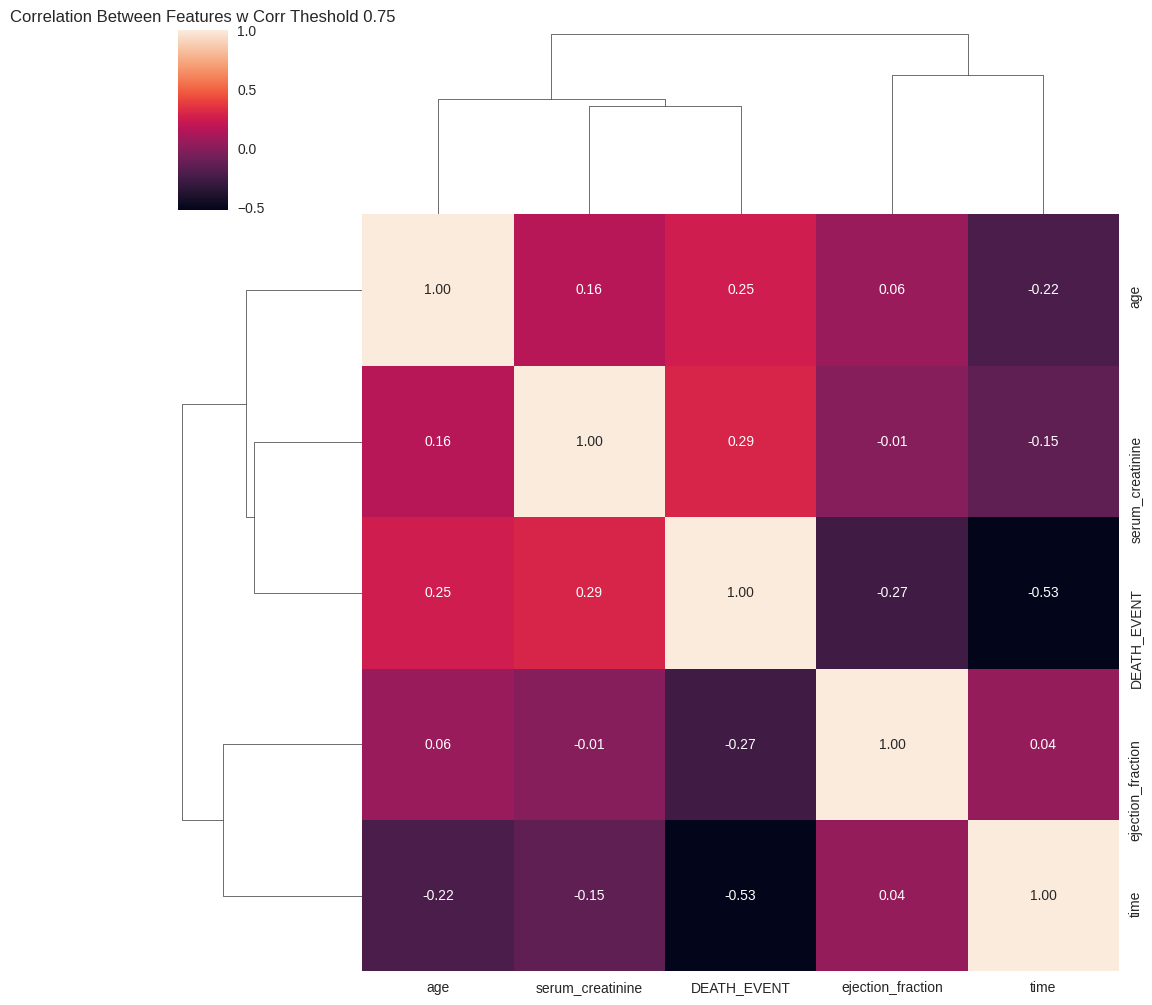

In [103]:
threshold = 0.2 
filtre = np.abs(corr_matrix["DEATH_EVENT"]) > threshold
corr_features = corr_matrix.columns[filtre].tolist()
sns.clustermap(data[corr_features].corr(), annot = True, fmt = ".2f")
plt.title("Correlation Between Features w Corr Theshold 0.75")
plt.show()

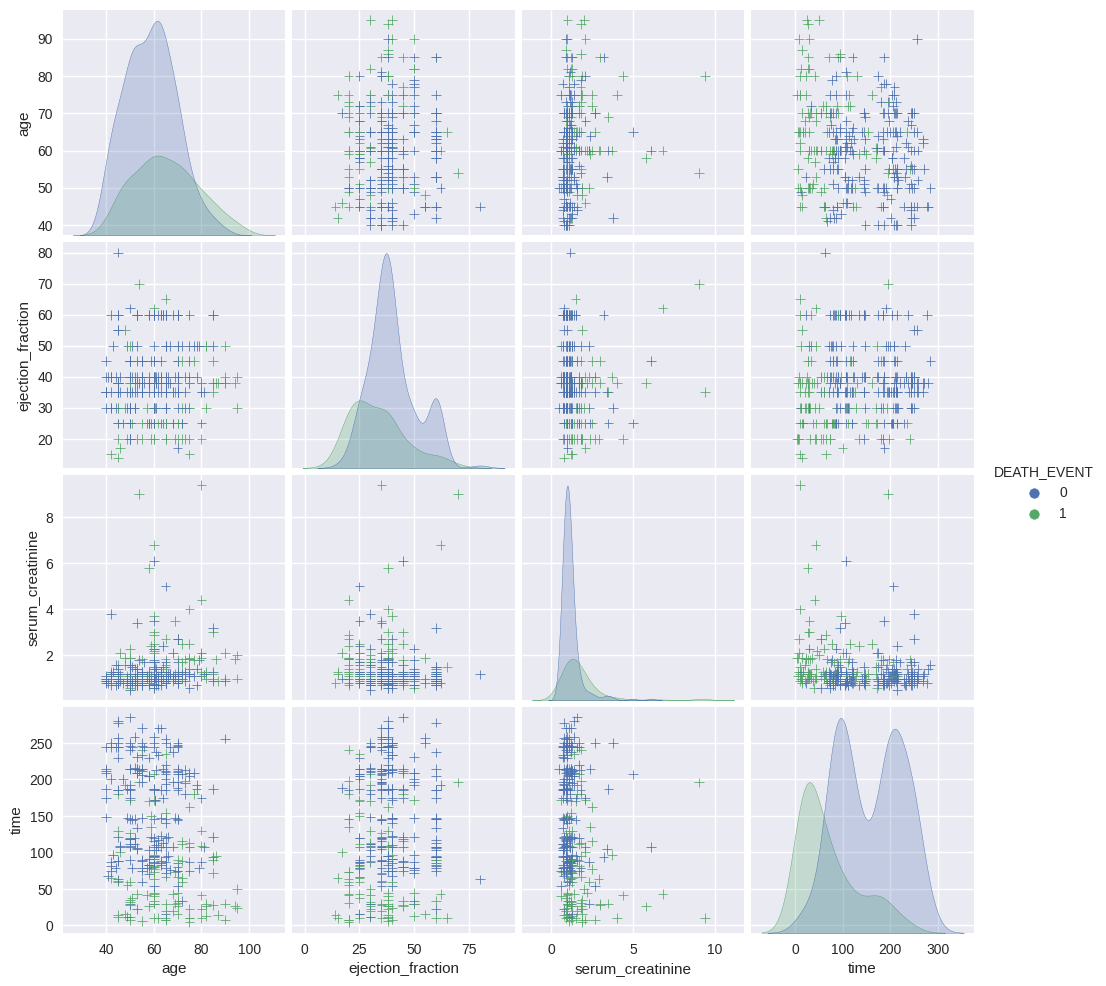

In [104]:
#pair plot
sns.pairplot(data[corr_features], diag_kind = "kde", markers = "+", hue = "DEATH_EVENT")
plt.show()

In [105]:
def detect_outliers(df,features):
    outlier_indices = []
    
    for c in features:
        # 1st quartile
        Q1 = np.percentile(df[c],25)
        # 3st quartile
        Q3 = np.percentile(df[c],75)
        # IQR
        IQR = Q3 - Q1
        # Outlier Step
        outlier_step = IQR * 1.5
        # detect outlier and their indeces
        outlier_list_col = df[(df[c] < Q1 - outlier_step) | (df[c] > Q3 + outlier_step)].index
        # store indeces 
        outlier_indices.extend(outlier_list_col)
        
    outlier_indices = Counter(outlier_indices)
    multiple_outliers = list(i for i, v in outlier_indices.items() if v > 1) 
    
    return multiple_outliers

In [106]:
data.loc[detect_outliers(data,["age","creatinine_phosphokinase","ejection_fraction","platelets","serum_creatinine","serum_sodium","time"])]

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
38,60.0,0,2656,1,30,0,305000.00,2.3,137,1,0,30,0
52,60.0,0,3964,1,62,0,263358.03,6.8,146,0,0,43,1
163,50.0,1,2334,1,35,0,75000.00,0.9,142,0,0,126,1
200,63.0,1,1767,0,45,0,73000.00,0.7,137,1,0,186,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0
217,54.0,1,427,0,70,1,151000.00,9.0,137,0,0,196,1
117,85.0,1,102,0,60,0,507000.00,3.2,138,0,0,94,0
167,59.0,0,66,1,20,0,70000.00,2.4,134,1,0,135,1
281,70.0,0,582,0,40,0,51000.00,2.7,136,1,1,250,0
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [107]:
!pip install pyswarms pennylane torch scikit-learn pandas numpy --quiet


In [108]:
import pandas as pd

# Load CSV (replace with your path if needed)
df = pd.read_csv("/kaggle/input/heart_failure_clinical_records_dataset.csv")  

# Display first 5 rows
df.head()


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [109]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop(columns=["DEATH_EVENT"])
y = df["DEATH_EVENT"].astype(int).values

feature_names = X.columns.tolist()

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [110]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
import pyswarms as ps

def fitness_function(particles):
    scores = []
    for particle in particles:
        mask = particle > 0.5
        if np.sum(mask) == 0:
            scores.append(0)  # Avoid empty feature set
            continue
        X_sel = X_scaled[:, mask]
        model = RandomForestClassifier(n_estimators=50, random_state=42)
        score = cross_val_score(model, X_sel, y, cv=3, scoring="accuracy").mean()
        scores.append(score)
    return -np.array(scores)  # PSO minimizes → negate accuracy


In [111]:
n_particles = 20
n_features = X.shape[1]

# Correct options for BinaryPSO
options = {
    'c1': 2,     # cognitive parameter
    'c2': 2,     # social parameter
    'w': 0.9,    # inertia
    'k': 5,      # number of neighbors
    'p': 2       # p-norm (Euclidean distance)
}

optimizer = ps.discrete.BinaryPSO(
    n_particles=n_particles,
    dimensions=n_features,
    options=options
)

# Optimize
best_cost, best_pos = optimizer.optimize(fitness_function, iters=30)

# Get selected features
selected_features = [f for f, m in zip(feature_names, best_pos) if m == 1]
print(f"Selected features ({len(selected_features)}): {selected_features}")


2025-08-16 18:24:58,549 - pyswarms.discrete.binary - INFO - Optimize for 30 iters with {'c1': 2, 'c2': 2, 'w': 0.9, 'k': 5, 'p': 2}
pyswarms.discrete.binary: 100%|██████████|30/30, best_cost=-0.766
2025-08-16 18:27:03,890 - pyswarms.discrete.binary - INFO - Optimization finished | best cost: -0.7658922558922558, best pos: [0 0 1 1 1 1 0 1 1 1 0 0]


Selected features (7): ['creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'serum_creatinine', 'serum_sodium', 'sex']


In [112]:
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader

# Filter selected features
X_sel = df[selected_features].values.astype(np.float32)

# Train/Val/Test split
X_train, X_tmp, y_train, y_tmp = train_test_split(X_sel, y, test_size=0.40, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.50, random_state=42, stratify=y_tmp)

# Dataset class
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = TabularDataset(X_train, y_train)
val_ds   = TabularDataset(X_val, y_val)
test_ds  = TabularDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False)


In [113]:
# --- CONFIG ---
PSO_TOP6 = ['serum_creatinine','ejection_fraction','creatinine_phosphokinase','serum_sodium','anaemia','diabetes']
TARGET_COL = "DEATH_EVENT"
CSV_PATH = "/kaggle/input/heart_failure_clinical_records_dataset.csv"  # change if needed
USE_IMPORTANCE = True           # set False to just take the first 4 from PSO_TOP6

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Load and prep
df = pd.read_csv(CSV_PATH)
df = df.fillna(df.median(numeric_only=True))
X_all = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL].astype(int).values

# Scale only the PSO candidates to rank them (keeps it simple & consistent)
scaler_rank = StandardScaler()
X_top6 = scaler_rank.fit_transform(df[PSO_TOP6].values)

if USE_IMPORTANCE:
    rf = RandomForestClassifier(n_estimators=200, random_state=42)
    rf.fit(X_top6, y)
    importances = rf.feature_importances_
    order = np.argsort(importances)[::-1]
    final_top4 = [PSO_TOP6[i] for i in order[:4]]
else:
    final_top4 = PSO_TOP6[:4]

print("Final Top-4 Features:", final_top4)


Final Top-4 Features: ['serum_creatinine', 'ejection_fraction', 'creatinine_phosphokinase', 'serum_sodium']


In [114]:
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader

# Build feature matrix with the chosen top-4
X = df[final_top4].values.astype(np.float32)

# Scale for model training
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X).astype(np.float32)

# Stratified 60/20/20
X_train, X_tmp, y_train, y_tmp = train_test_split(X_scaled, y, test_size=0.40, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.50, random_state=42, stratify=y_tmp)

class TabularDS(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_loader = DataLoader(TabularDS(X_train, y_train), batch_size=32, shuffle=True)
val_loader   = DataLoader(TabularDS(X_val,   y_val),   batch_size=32, shuffle=False)
test_loader  = DataLoader(TabularDS(X_test,  y_test),  batch_size=32, shuffle=False)

device = "cuda" if torch.cuda.is_available() else "cpu"


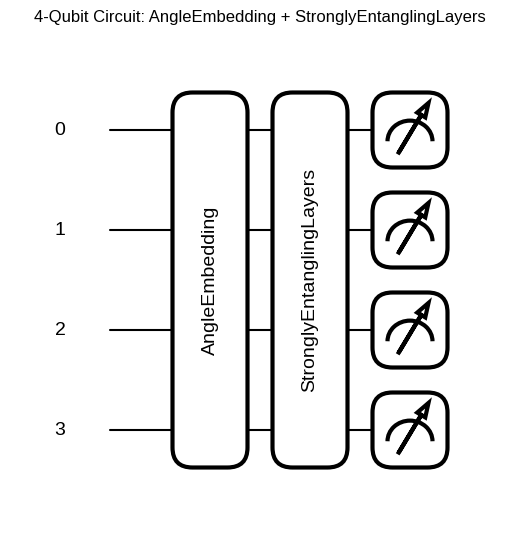

Saved circuit figure to qnn_top4_circuit.png


In [115]:
import pennylane as qml
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

def quantum_circuit(inputs, weights):
    # inputs: shape (..., 4)  (one angle per qubit)
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

n_layers = 2
weight_shapes = {"weights": (n_layers, n_qubits, 3)}
qnode = qml.QNode(quantum_circuit, dev, interface="torch")

# --- Draw colorful circuit figure ---
fig, ax = qml.draw_mpl(qnode, decimals=None)(torch.zeros(n_qubits), torch.zeros(weight_shapes["weights"]))
ax.set_title("4-Qubit Circuit: AngleEmbedding + StronglyEntanglingLayers", fontsize=12)
plt.tight_layout()
plt.show()

# Save if you want a file
fig.savefig("qnn_top4_circuit.png", dpi=200)
print("Saved circuit figure to qnn_top4_circuit.png")


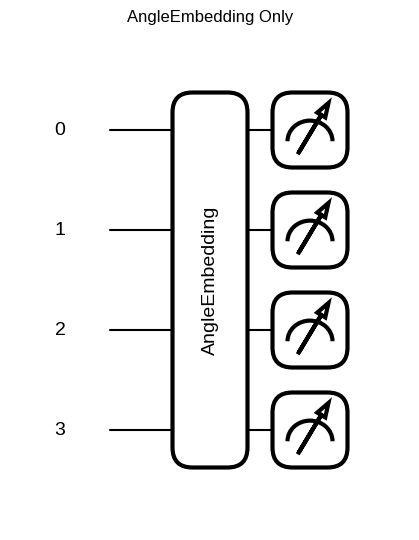

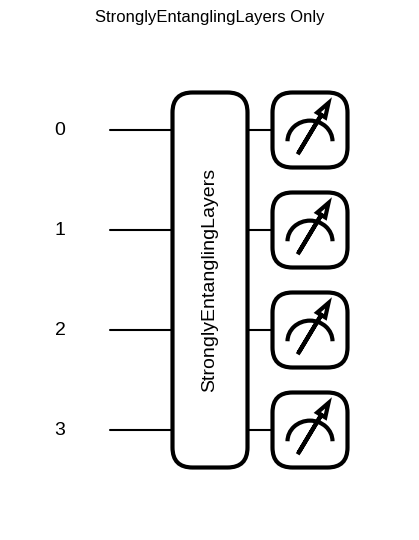

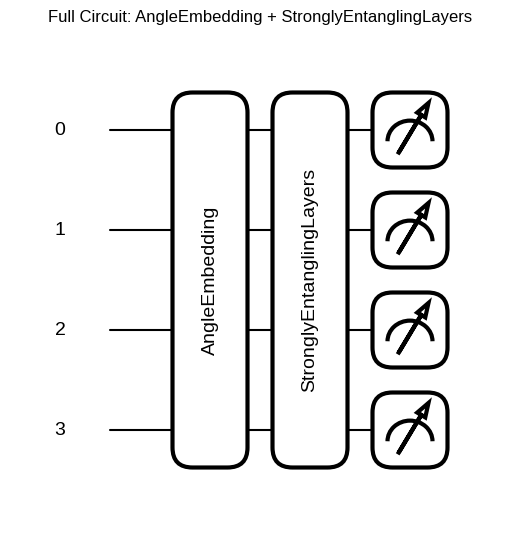

Saved: angle_embedding_only.png, entangling_layers_only.png, full_circuit.png


In [116]:
import pennylane as qml
import torch
import matplotlib.pyplot as plt

n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)
n_layers = 2
weight_shapes = {"weights": (n_layers, n_qubits, 3)}

# --- 1) AngleEmbedding only ---
def angle_embedding_only(inputs):
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

qnode_angle = qml.QNode(angle_embedding_only, dev, interface="torch")
fig1, ax1 = qml.draw_mpl(qnode_angle, decimals=None)(
    torch.zeros(n_qubits)  # zero angles for drawing
)
ax1.set_title("AngleEmbedding Only", fontsize=12)
plt.tight_layout()
fig1.savefig("angle_embedding_only.png", dpi=200)
plt.show()

# --- 2) StronglyEntanglingLayers only ---
def entangling_only(weights):
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

qnode_entangle = qml.QNode(entangling_only, dev, interface="torch")
fig2, ax2 = qml.draw_mpl(qnode_entangle, decimals=None)(
    torch.zeros(weight_shapes["weights"])
)
ax2.set_title("StronglyEntanglingLayers Only", fontsize=12)
plt.tight_layout()
fig2.savefig("entangling_layers_only.png", dpi=200)
plt.show()

# --- 3) Full circuit ---
def full_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

qnode_full = qml.QNode(full_circuit, dev, interface="torch")
fig3, ax3 = qml.draw_mpl(qnode_full, decimals=None)(
    torch.zeros(n_qubits), torch.zeros(weight_shapes["weights"])
)
ax3.set_title("Full Circuit: AngleEmbedding + StronglyEntanglingLayers", fontsize=12)
plt.tight_layout()
fig3.savefig("full_circuit.png", dpi=200)
plt.show()

print("Saved: angle_embedding_only.png, entangling_layers_only.png, full_circuit.png")


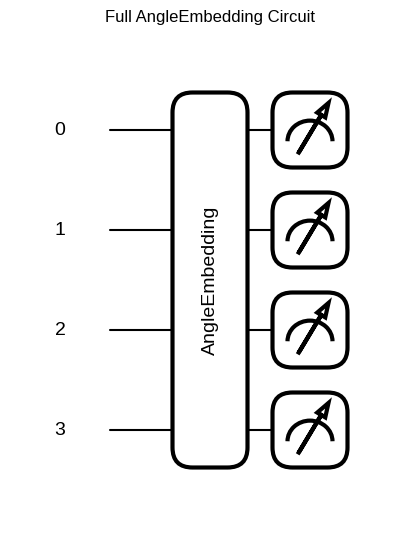

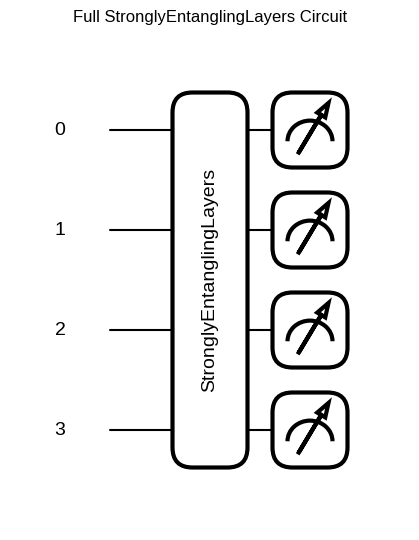

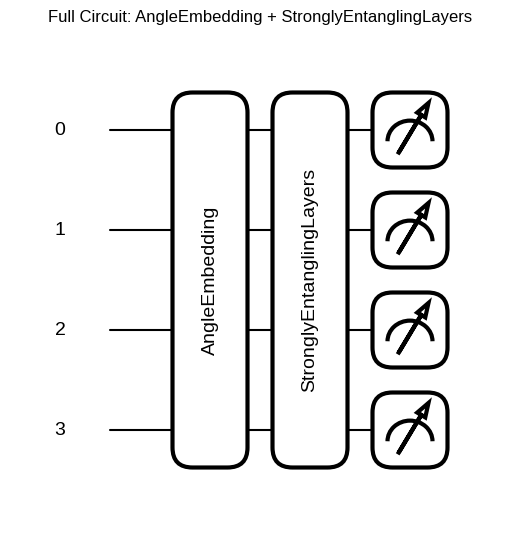

Saved: full_angle_embedding.png, full_entangling_layers.png, full_combined_circuit.png


In [117]:
import pennylane as qml
import torch
import matplotlib.pyplot as plt

n_qubits = 4
n_layers = 2
weight_shapes = {"weights": (n_layers, n_qubits, 3)}

dev = qml.device("default.qubit", wires=n_qubits)

# --- Full AngleEmbedding circuit ---
def angle_circuit(inputs):
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

qnode_angle = qml.QNode(angle_circuit, dev, interface="torch")
fig1, ax1 = qml.draw_mpl(qnode_angle, decimals=None)(
    torch.tensor([0.1, 0.2, 0.3, 0.4])  # example values so gates are visible
)
ax1.set_title("Full AngleEmbedding Circuit", fontsize=12)
plt.tight_layout()
fig1.savefig("full_angle_embedding.png", dpi=200)
plt.show()

# --- Full StronglyEntanglingLayers circuit ---
def entangle_circuit(weights):
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

qnode_entangle = qml.QNode(entangle_circuit, dev, interface="torch")
fig2, ax2 = qml.draw_mpl(qnode_entangle, decimals=None)(
    torch.ones(weight_shapes["weights"]) * 0.5  # example values
)
ax2.set_title("Full StronglyEntanglingLayers Circuit", fontsize=12)
plt.tight_layout()
fig2.savefig("full_entangling_layers.png", dpi=200)
plt.show()

# --- Full combined circuit ---
def combined_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

qnode_full = qml.QNode(combined_circuit, dev, interface="torch")
fig3, ax3 = qml.draw_mpl(qnode_full, decimals=None)(
    torch.tensor([0.1, 0.2, 0.3, 0.4]),
    torch.ones(weight_shapes["weights"]) * 0.5
)
ax3.set_title("Full Circuit: AngleEmbedding + StronglyEntanglingLayers", fontsize=12)
plt.tight_layout()
fig3.savefig("full_combined_circuit.png", dpi=200)
plt.show()

print("Saved: full_angle_embedding.png, full_entangling_layers.png, full_combined_circuit.png")


In [118]:
!pip install qiskit --quiet


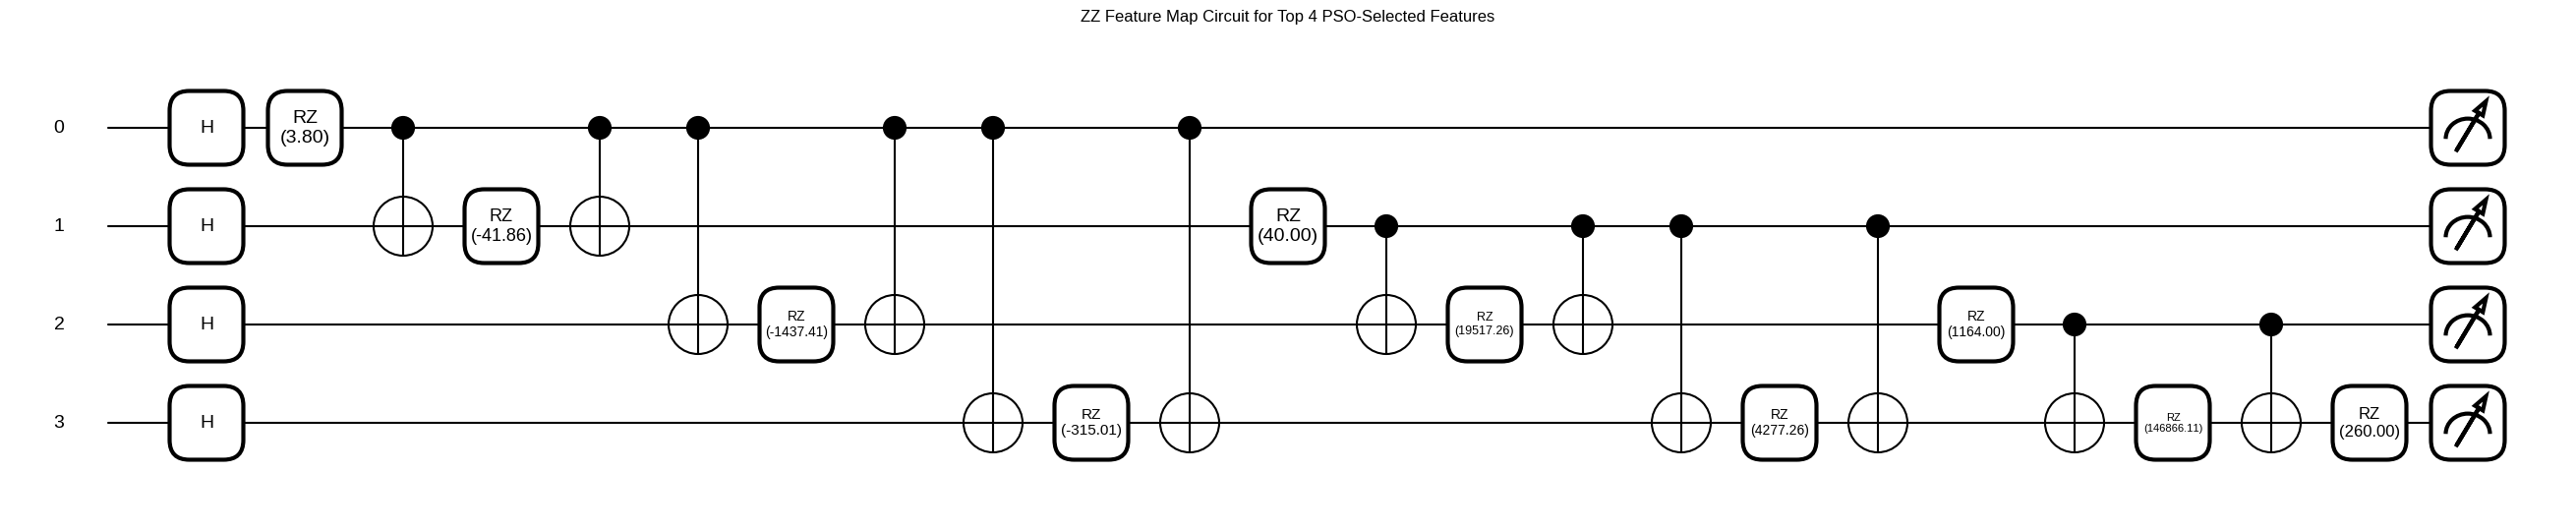

✅ Circuit diagram saved as zz_feature_map_qnn.png


In [119]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

# --- Your top 4 PSO-selected features ---
# Example: serum_creatinine, ejection_fraction, creatinine_phosphokinase, serum_sodium
selected_features = ['serum_creatinine', 'ejection_fraction', 
                     'creatinine_phosphokinase', 'serum_sodium']

# Number of qubits = number of selected features
num_qubits = len(selected_features)

# --- PennyLane device ---
dev = qml.device('default.qubit', wires=num_qubits)

# --- ZZ Feature Map Circuit ---
@qml.qnode(dev)
def zz_feature_map(inputs):
    """Custom ZZFeatureMap-style embedding for selected features."""
    # Step 1: Hadamard on all qubits
    for i in range(num_qubits):
        qml.Hadamard(wires=i)
    
    # Step 2: Apply RZ rotations and ZZ entanglement
    for i in range(num_qubits):
        qml.RZ(2 * inputs[i], wires=i)
        for j in range(i + 1, num_qubits):
            qml.CNOT(wires=[i, j])
            qml.RZ(2 * (np.pi - inputs[i]) * (np.pi - inputs[j]), wires=j)
            qml.CNOT(wires=[i, j])
    
    # Output expectation values
    return [qml.expval(qml.PauliZ(k)) for k in range(num_qubits)]

# --- Example: First row of dataset (replace with your real data) ---
# This should be a NumPy array of shape (4,)
sample_input = np.array([1.9, 20, 582, 130])  # Example values

# --- Draw the circuit ---
fig, ax = qml.draw_mpl(zz_feature_map, decimals=2)(sample_input)
ax.set_title("ZZ Feature Map Circuit for Top 4 PSO-Selected Features", fontsize=12)
plt.tight_layout()

# --- Save high-quality image ---
filename = "zz_feature_map_qnn.png"
fig.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Circuit diagram saved as {filename}")


In [120]:
!pip install pylatexenc --quiet


In [121]:
!pip install qiskit pylatexenc --quiet

In [122]:
import pylatexenc
print("pylatexenc version:", pylatexenc.__version__)


pylatexenc version: 2.10


In [123]:
!pip install pylatexenc

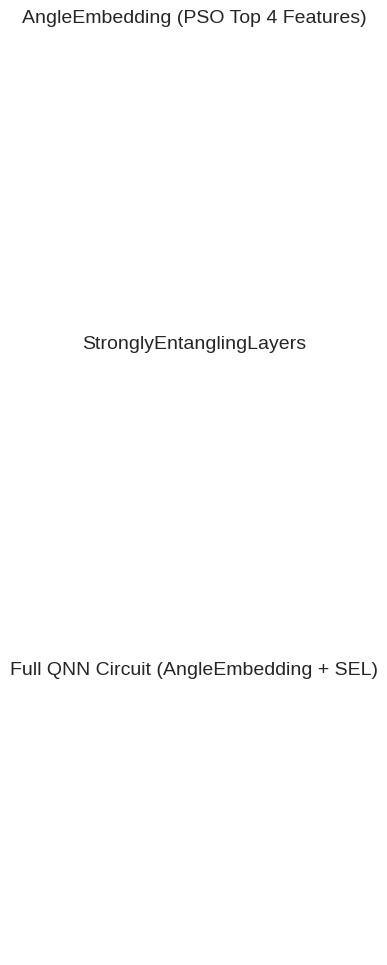

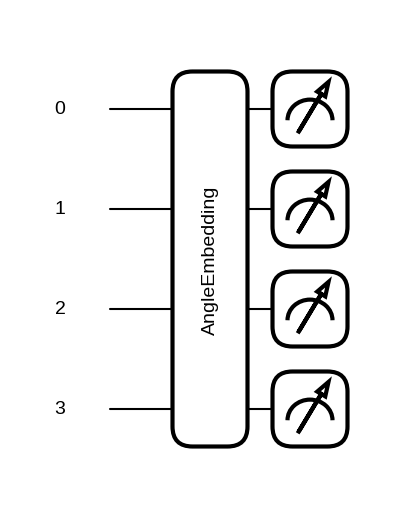

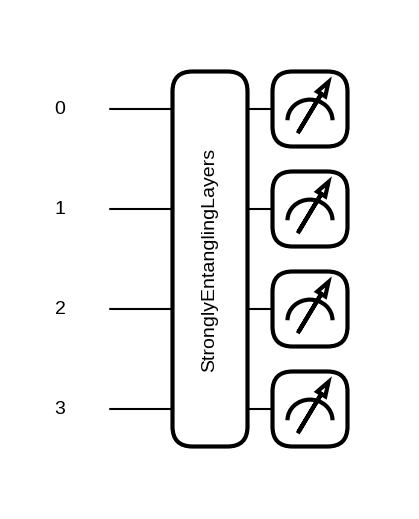

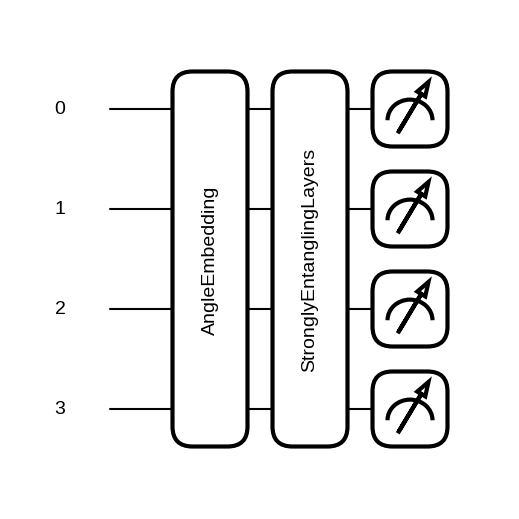

✅ Saved colorful quantum circuit diagrams as 'PSO_Top4_QNN_Circuits_PennyLane.png'


In [124]:
import pennylane as qml
from pennylane import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Load dataset from Kaggle path ===
df = pd.read_csv("/kaggle/input/heart_failure_clinical_records_dataset.csv")

# PSO-selected top 4 features
selected_features = ['serum_creatinine', 'ejection_fraction',
                     'creatinine_phosphokinase', 'serum_sodium']
data_selected = df[selected_features].values

# === 2. Normalize to [0, 2π] ===
min_vals = data_selected.min(axis=0)
max_vals = data_selected.max(axis=0)
normalized_data = 2 * np.pi * (data_selected - min_vals) / (max_vals - min_vals)

# Take first sample for visualization
angles = normalized_data[0]

# === 3. Quantum device ===
n_qubits = len(selected_features)
n_layers = 2
dev = qml.device("default.qubit", wires=n_qubits)

# === 4. Define circuits ===
@qml.qnode(dev)
def angle_embedding_circuit(inputs):
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

@qml.qnode(dev)
def sel_circuit():
    weights = np.random.rand(n_layers, n_qubits, 3) * 2 * np.pi
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

@qml.qnode(dev)
def full_qnn_circuit(inputs):
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    weights = np.random.rand(n_layers, n_qubits, 3) * 2 * np.pi
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# === 5. Draw circuits ===
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

# AngleEmbedding
fig_angle, _ = qml.draw_mpl(angle_embedding_circuit, decimals=2)(angles)
axes[0].imshow(fig_angle.canvas.buffer_rgba())
axes[0].axis('off')
axes[0].set_title("AngleEmbedding (PSO Top 4 Features)", fontsize=14)

# StronglyEntanglingLayers
fig_sel, _ = qml.draw_mpl(sel_circuit, decimals=2)()
axes[1].imshow(fig_sel.canvas.buffer_rgba())
axes[1].axis('off')
axes[1].set_title("StronglyEntanglingLayers", fontsize=14)

# Full QNN
fig_full, _ = qml.draw_mpl(full_qnn_circuit, decimals=2)(angles)
axes[2].imshow(fig_full.canvas.buffer_rgba())
axes[2].axis('off')
axes[2].set_title("Full QNN Circuit (AngleEmbedding + SEL)", fontsize=14)

plt.tight_layout()
plt.savefig("PSO_Top4_QNN_Circuits_PennyLane.png", dpi=300)
plt.show()

print("✅ Saved colorful quantum circuit diagrams as 'PSO_Top4_QNN_Circuits_PennyLane.png'")


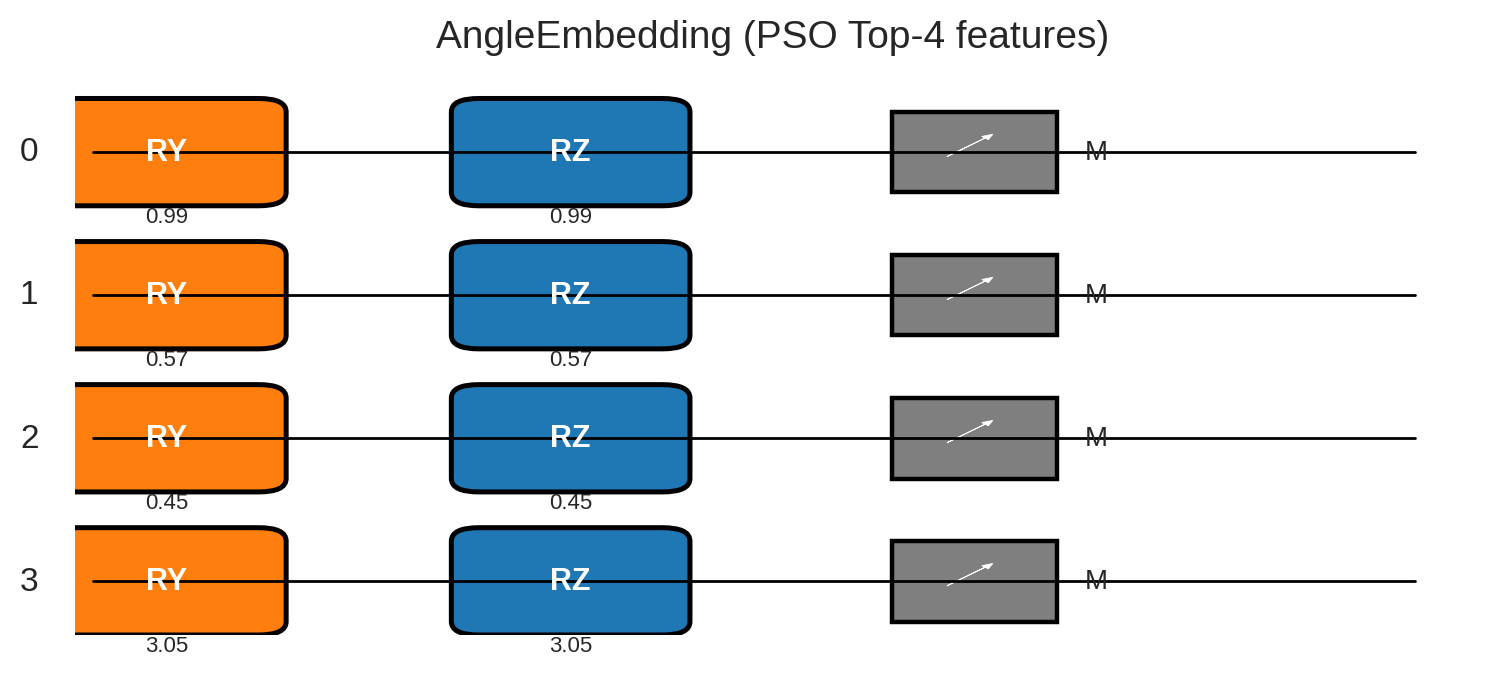

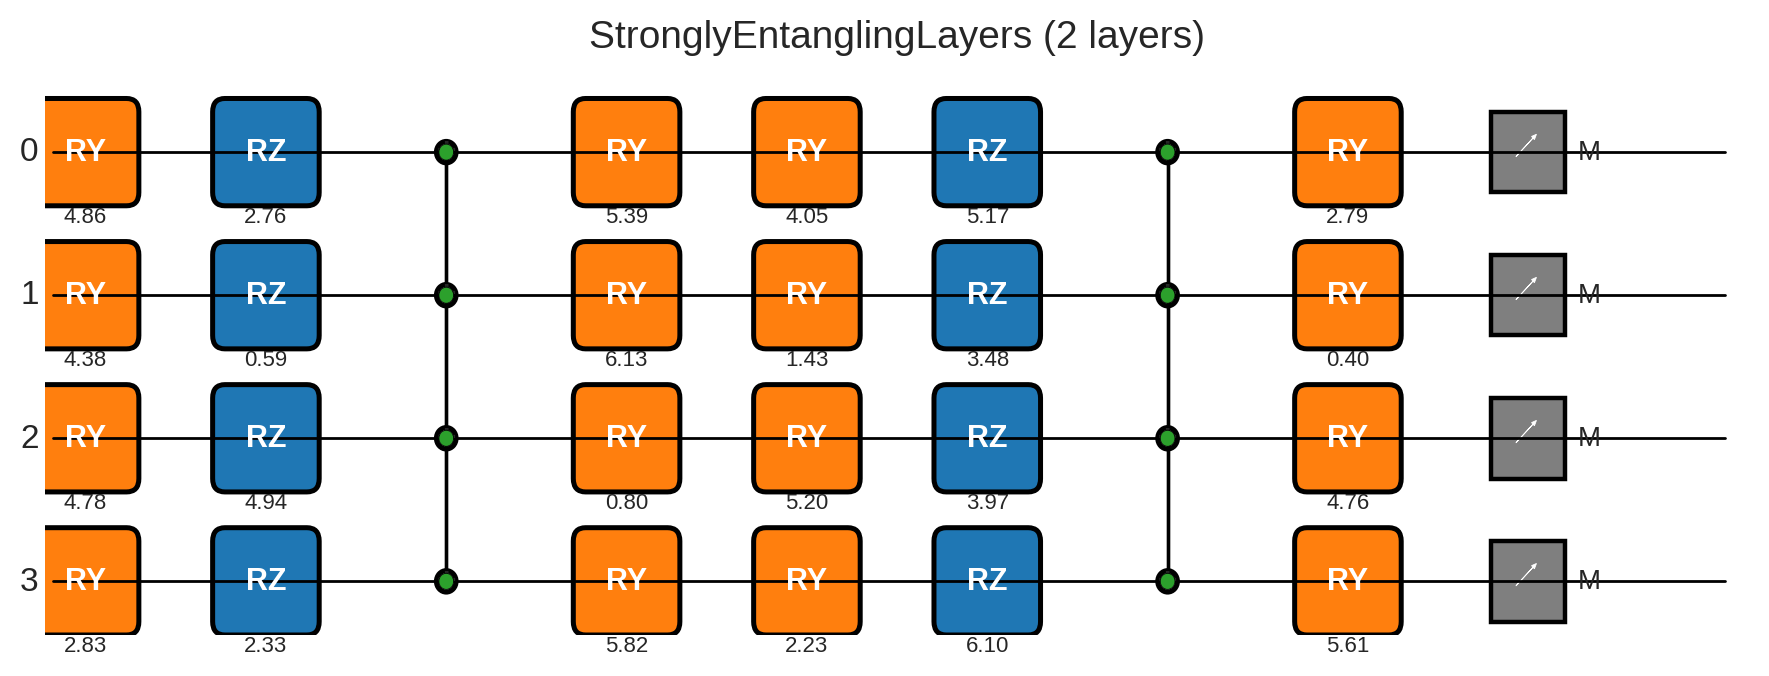

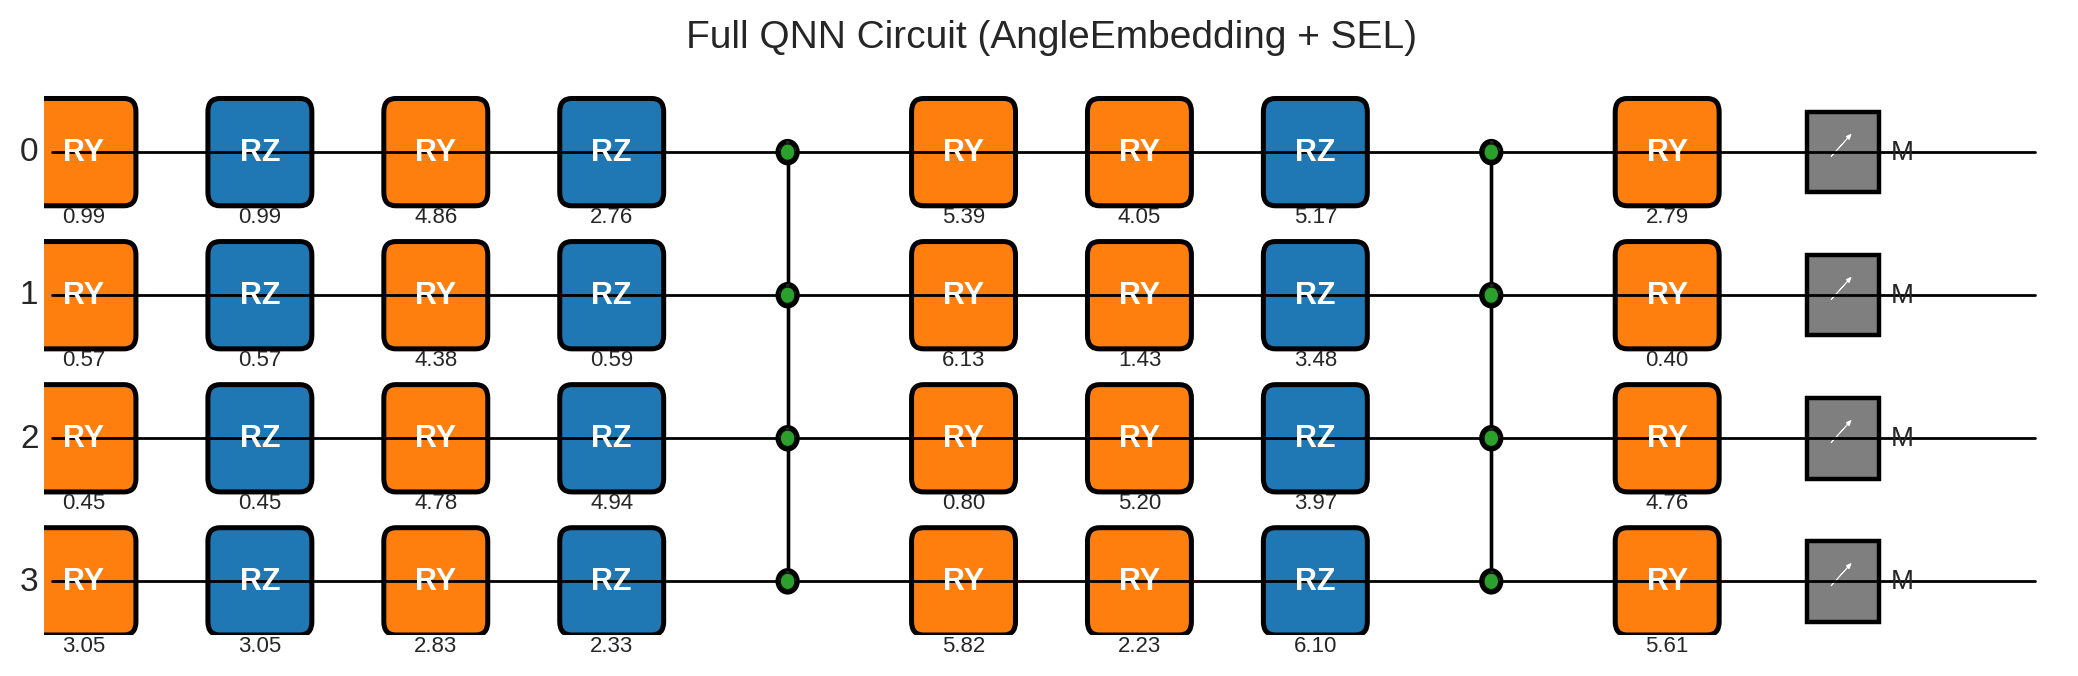

In [125]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Circle, Rectangle
from matplotlib.lines import Line2D

# =====================
# Load your dataset
# =====================
CSV_PATH = "/kaggle/input/heart_failure_clinical_records_dataset.csv"
selected_features = ['serum_creatinine', 'ejection_fraction', 'creatinine_phosphokinase', 'serum_sodium']
n_qubits = len(selected_features)
n_layers = 2
dpi = 200

df = pd.read_csv(CSV_PATH)
X = df[selected_features].values.astype(float)

# Normalize features to [0, 2π]
minv = X.min(axis=0)
maxv = X.max(axis=0)
ranges = np.where(maxv - minv == 0, 1.0, maxv - minv)
angles_all = 2 * np.pi * (X - minv) / ranges

# Take first sample for diagram
sample_idx = 0
angles = angles_all[sample_idx]

# Random weights for StronglyEntanglingLayers
rng = np.random.default_rng(42)
weights = rng.random((n_layers, n_qubits, 3)) * 2 * np.pi

# =====================
# Draw helper
# =====================
def draw_circuit(columns, title, fname, figsize=(9, 3.5), xgap=2.2, ygap=1.6):
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    ax.set_xlim(-0.5, len(columns) * xgap + 0.5)
    ax.set_ylim(- (n_qubits - 1) * ygap - 0.6, 0.8)
    ax.axis('off')

    y_positions = [-i * ygap for i in range(n_qubits)]
    for qi, y in enumerate(y_positions):
        ax.add_line(Line2D([-0.4, len(columns) * xgap + 0.2], [y, y], color="black", linewidth=1))
        ax.text(-0.8, y, str(qi), fontsize=12, va='center')

    color_RY = "#ff7f0e"  
    color_RZ = "#1f77b4"  
    color_CX = "#2ca02c"  
    color_MEAS = "#7f7f7f"  

    for col_idx, col in enumerate(columns):
        x = col_idx * xgap
        for gate in col:
            if gate[0] in ("RY", "RZ"):
                typ, q, angle = gate
                y = y_positions[q]
                bbox = FancyBboxPatch((x - 0.5, y - 0.45), 1.0, 0.9,
                                      boxstyle="round,pad=0.15",
                                      linewidth=1.8,
                                      edgecolor="black",
                                      facecolor=color_RY if typ == "RY" else color_RZ)
                ax.add_patch(bbox)
                ax.text(x, y, typ, fontsize=11, ha="center", va="center", color="white", fontweight='bold')
                ax.text(x, y - 0.6, f"{angle:.2f}", fontsize=8, ha="center", va="top")

            elif gate[0] == "CX":
                _, c, t = gate
                yc = y_positions[c]
                yt = y_positions[t]
                circ = Circle((x, yc), radius=0.09, color=color_CX, ec="black", zorder=10)
                ax.add_patch(circ)
                circ2 = Circle((x, yt), radius=0.12, fill=False, linewidth=1.8, ec="black")
                ax.add_patch(circ2)
                ax.text(x, yt, "+", fontsize=12, ha="center", va="center", fontweight='bold')
                ax.add_line(Line2D([x, x], [yc, yt], linewidth=1.2, color="black"))

            elif gate[0] == "MEAS":
                _, q = gate
                y = y_positions[q]
                rect = Rectangle((x - 0.45, y - 0.45), 0.9, 0.9, linewidth=1.6, edgecolor="black", facecolor=color_MEAS)
                ax.add_patch(rect)
                ax.arrow(x - 0.15, y - 0.05, 0.25, 0.25, head_width=0.05, head_length=0.06,
                         length_includes_head=True, color='white')
                ax.text(x + 0.6, y, "M", fontsize=10, va='center')

    ax.set_title(title, fontsize=14, pad=12)
    plt.savefig(fname, dpi=dpi, bbox_inches="tight")
    plt.show()

# =====================
# Build circuit column lists
# =====================
meas_col = [("MEAS", i) for i in range(n_qubits)]

# AngleEmbedding
col0 = [("RY", i, float(angles[i])) for i in range(n_qubits)]
col1 = [("RZ", i, float(angles[i])) for i in range(n_qubits)]
angle_cols = [col0, col1, meas_col]

# StronglyEntanglingLayers
sel_cols = []
for layer in range(n_layers):
    r1 = [("RY", i, float(weights[layer, i, 0])) for i in range(n_qubits)]
    r2 = [("RZ", i, float(weights[layer, i, 1])) for i in range(n_qubits)]
    cx = [("CX", i, (i+1) % n_qubits) for i in range(n_qubits)]
    r3 = [("RY", i, float(weights[layer, i, 2])) for i in range(n_qubits)]
    sel_cols.extend([r1, r2, cx, r3])
sel_cols.append(meas_col)

# Full QNN
full_cols = [col0, col1] + sel_cols[:-1] + [meas_col]

# =====================
# Draw and save
# =====================
draw_circuit(angle_cols, "AngleEmbedding (PSO Top-4 features)", "angle_embedding_psotop4.png", figsize=(9,3.6))
draw_circuit(sel_cols, "StronglyEntanglingLayers (2 layers)", "sel_layers_psotop4.png", figsize=(11,3.6))
draw_circuit(full_cols, "Full QNN Circuit (AngleEmbedding + SEL)", "full_qnn_psotop4.png", figsize=(13,3.6))


In [126]:
import pennylane as qml
from pennylane import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# Load dataset and select PSO top 4 features
# -------------------------
CSV_PATH = "/kaggle/input/heart_failure_clinical_records_dataset.csv"
top4_features = ['serum_creatinine', 'ejection_fraction', 'creatinine_phosphokinase', 'serum_sodium']
df = pd.read_csv(CSV_PATH)
features_dataset = df[top4_features].values.astype(float)

# Normalize to [0, π]
minv = features_dataset.min(axis=0)
maxv = features_dataset.max(axis=0)
ranges = np.where(maxv - minv == 0, 1.0, maxv - minv)
features_dataset = np.pi * (features_dataset - minv) / ranges

# -------------------------
# Common setup
# -------------------------
num_qubits = features_dataset.shape[1]
sample_input = features_dataset[0]  # First sample
dev = qml.device('default.qubit', wires=num_qubits)

def save_colored_circuit(qnode, inputs, filename, title):
    fig, ax = qml.draw_mpl(qnode)(inputs)
    fig.set_facecolor("#f9f9f9")
    ax.set_title(title, fontsize=14, fontweight="bold", color="#333333")
    for spine in ax.spines.values():
        spine.set_color("#888888")
    fig.savefig(filename, dpi=200, bbox_inches="tight")
    plt.close(fig)

# 1️⃣ ZZFeatureMap mimic
@qml.qnode(dev)
def zz_feature_map(inputs):
    for i in range(num_qubits):
        qml.Hadamard(wires=i)
    for i in range(num_qubits):
        qml.RZ(2 * inputs[i], wires=i)
        for j in range(i + 1, num_qubits):
            qml.CNOT(wires=[i, j])
            qml.RZ(2 * (np.pi - inputs[i]) * (np.pi - inputs[j]), wires=j)
            qml.CNOT(wires=[i, j])
    return [qml.expval(qml.PauliZ(i)) for i in range(num_qubits)]

save_colored_circuit(zz_feature_map, sample_input, "/kaggle/working/zz_feature_map_colored.png",
                     "ZZFeatureMap (PSO Top-4 Features)")

# 2️⃣ PauliFeatureMap mimic
@qml.qnode(dev)
def pauli_feature_map(inputs):
    for i in range(num_qubits):
        qml.Hadamard(wires=i)
    for i in range(num_qubits):
        qml.RX(inputs[i], wires=i)
        qml.RY(inputs[i], wires=i)
        qml.RZ(inputs[i], wires=i)
    for i in range(num_qubits - 1):
        qml.CNOT(wires=[i, i + 1])
    return [qml.expval(qml.PauliZ(i)) for i in range(num_qubits)]

save_colored_circuit(pauli_feature_map, sample_input, "/kaggle/working/pauli_feature_map_colored.png",
                     "PauliFeatureMap (PSO Top-4 Features)")

# 3️⃣ RealAmplitudes mimic
@qml.qnode(dev)
def real_amplitudes(inputs):
    for i in range(num_qubits):
        qml.RY(inputs[i], wires=i)
    for i in range(num_qubits - 1):
        qml.CNOT(wires=[i, i + 1])
    for i in range(num_qubits):
        qml.RY(inputs[i], wires=i)
    return [qml.expval(qml.PauliZ(i)) for i in range(num_qubits)]

save_colored_circuit(real_amplitudes, sample_input, "/kaggle/working/real_amplitudes_colored.png",
                     "RealAmplitudes (PSO Top-4 Features)")

# 4️⃣ EfficientSU2 mimic
@qml.qnode(dev)
def efficient_su2(inputs):
    for i in range(num_qubits):
        qml.RY(inputs[i], wires=i)
        qml.RZ(inputs[i], wires=i)
    for i in range(num_qubits):
        qml.CNOT(wires=[i, (i + 1) % num_qubits])
    for i in range(num_qubits):
        qml.RY(inputs[i], wires=i)
        qml.RZ(inputs[i], wires=i)
    return [qml.expval(qml.PauliZ(i)) for i in range(num_qubits)]

save_colored_circuit(efficient_su2, sample_input, "/kaggle/working/efficient_su2_colored.png",
                     "EfficientSU2 (PSO Top-4 Features)")

print("✅ All circuits saved with color in /kaggle/working/")


✅ All circuits saved with color in /kaggle/working/


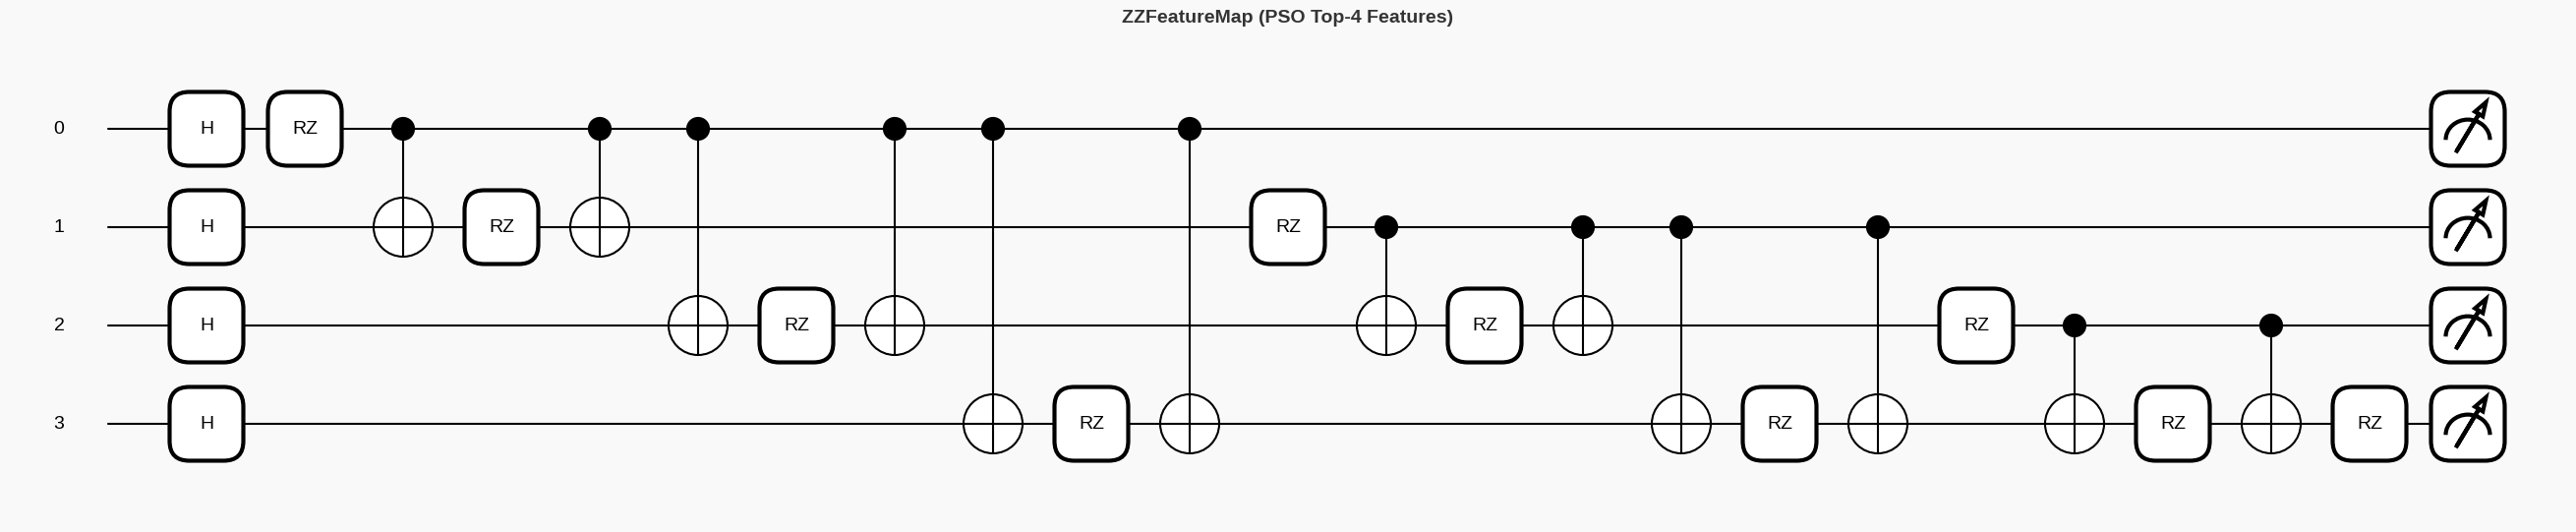

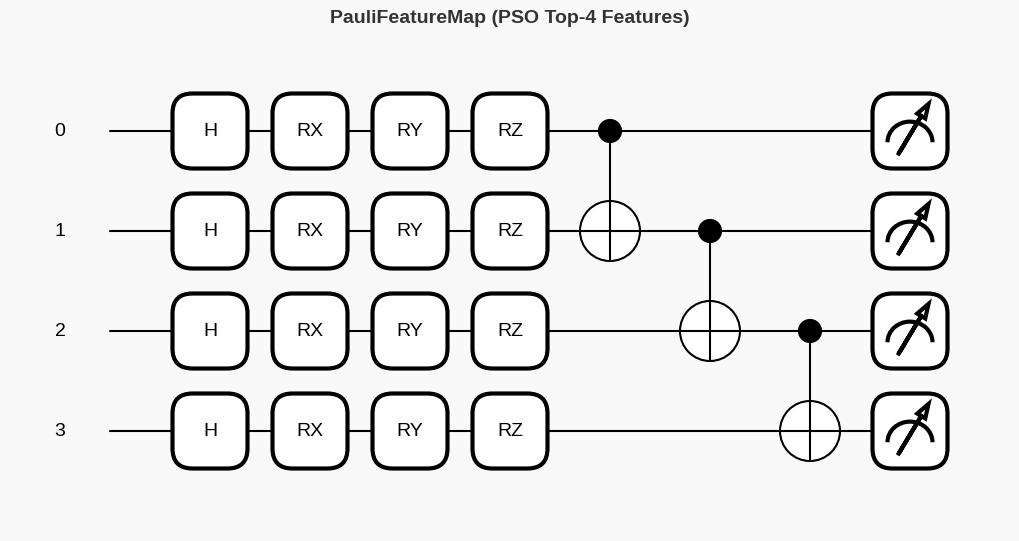

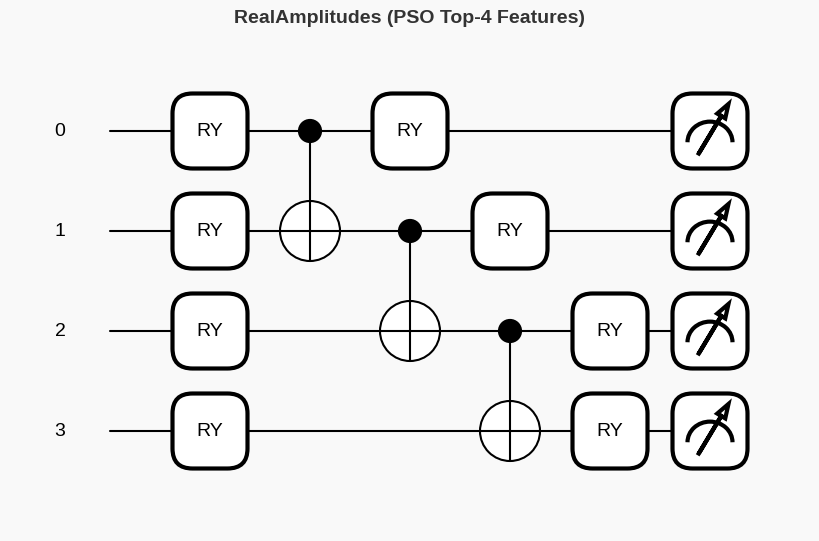

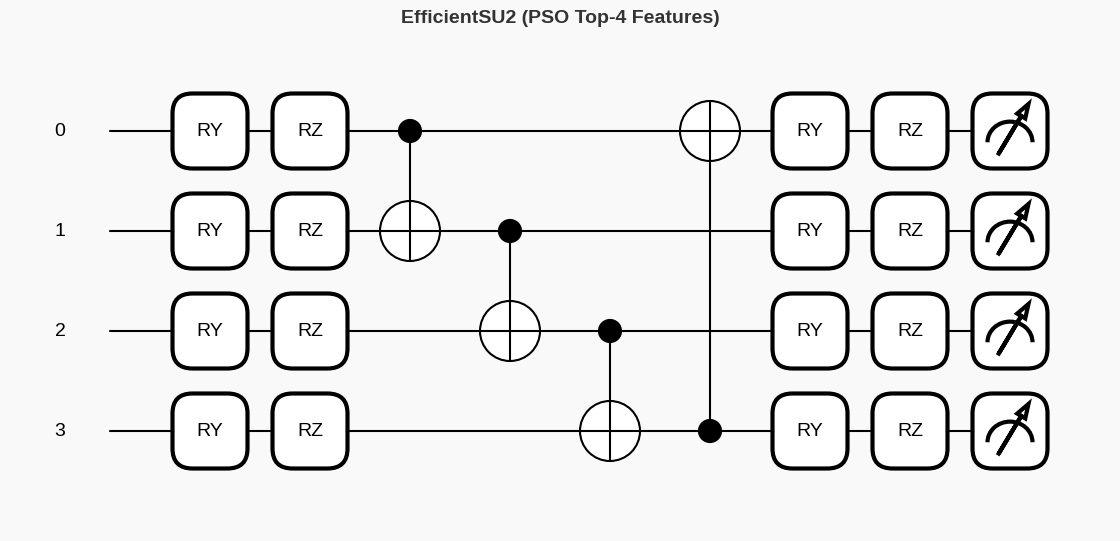

✅ All circuits displayed here and saved in /kaggle/working/


In [127]:
import pennylane as qml
from pennylane import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# Load dataset and select PSO top 4 features
# -------------------------
CSV_PATH = "/kaggle/input/heart_failure_clinical_records_dataset.csv"
top4_features = ['serum_creatinine', 'ejection_fraction', 'creatinine_phosphokinase', 'serum_sodium']
df = pd.read_csv(CSV_PATH)
features_dataset = df[top4_features].values.astype(float)

# Normalize to [0, π]
minv = features_dataset.min(axis=0)
maxv = features_dataset.max(axis=0)
ranges = np.where(maxv - minv == 0, 1.0, maxv - minv)
features_dataset = np.pi * (features_dataset - minv) / ranges

# -------------------------
# Common setup
# -------------------------
num_qubits = features_dataset.shape[1]
sample_input = features_dataset[0]  # First sample
dev = qml.device('default.qubit', wires=num_qubits)

def show_and_save_colored_circuit(qnode, inputs, filename, title):
    fig, ax = qml.draw_mpl(qnode)(inputs)
    fig.set_facecolor("#f9f9f9")
    ax.set_title(title, fontsize=14, fontweight="bold", color="#333333")
    for spine in ax.spines.values():
        spine.set_color("#888888")
    fig.savefig(filename, dpi=200, bbox_inches="tight")
    plt.show()  # display here
    plt.close(fig)

# 1️⃣ ZZFeatureMap mimic
@qml.qnode(dev)
def zz_feature_map(inputs):
    for i in range(num_qubits):
        qml.Hadamard(wires=i)
    for i in range(num_qubits):
        qml.RZ(2 * inputs[i], wires=i)
        for j in range(i + 1, num_qubits):
            qml.CNOT(wires=[i, j])
            qml.RZ(2 * (np.pi - inputs[i]) * (np.pi - inputs[j]), wires=j)
            qml.CNOT(wires=[i, j])
    return [qml.expval(qml.PauliZ(i)) for i in range(num_qubits)]

show_and_save_colored_circuit(zz_feature_map, sample_input,
                              "/kaggle/working/zz_feature_map_colored.png",
                              "ZZFeatureMap (PSO Top-4 Features)")

# 2️⃣ PauliFeatureMap mimic
@qml.qnode(dev)
def pauli_feature_map(inputs):
    for i in range(num_qubits):
        qml.Hadamard(wires=i)
    for i in range(num_qubits):
        qml.RX(inputs[i], wires=i)
        qml.RY(inputs[i], wires=i)
        qml.RZ(inputs[i], wires=i)
    for i in range(num_qubits - 1):
        qml.CNOT(wires=[i, i + 1])
    return [qml.expval(qml.PauliZ(i)) for i in range(num_qubits)]

show_and_save_colored_circuit(pauli_feature_map, sample_input,
                              "/kaggle/working/pauli_feature_map_colored.png",
                              "PauliFeatureMap (PSO Top-4 Features)")

# 3️⃣ RealAmplitudes mimic
@qml.qnode(dev)
def real_amplitudes(inputs):
    for i in range(num_qubits):
        qml.RY(inputs[i], wires=i)
    for i in range(num_qubits - 1):
        qml.CNOT(wires=[i, i + 1])
    for i in range(num_qubits):
        qml.RY(inputs[i], wires=i)
    return [qml.expval(qml.PauliZ(i)) for i in range(num_qubits)]

show_and_save_colored_circuit(real_amplitudes, sample_input,
                              "/kaggle/working/real_amplitudes_colored.png",
                              "RealAmplitudes (PSO Top-4 Features)")

# 4️⃣ EfficientSU2 mimic
@qml.qnode(dev)
def efficient_su2(inputs):
    for i in range(num_qubits):
        qml.RY(inputs[i], wires=i)
        qml.RZ(inputs[i], wires=i)
    for i in range(num_qubits):
        qml.CNOT(wires=[i, (i + 1) % num_qubits])
    for i in range(num_qubits):
        qml.RY(inputs[i], wires=i)
        qml.RZ(inputs[i], wires=i)
    return [qml.expval(qml.PauliZ(i)) for i in range(num_qubits)]

show_and_save_colored_circuit(efficient_su2, sample_input,
                              "/kaggle/working/efficient_su2_colored.png",
                              "EfficientSU2 (PSO Top-4 Features)")

print("✅ All circuits displayed here and saved in /kaggle/working/")


In [128]:
import pennylane as qml
import torch
import torch.nn as nn
import torch.optim as optim

# ----- Device setup -----
device = "cuda" if torch.cuda.is_available() else "cpu"

# ----- PSO Top-4 Features -----
n_qubits = 4  # Top-4 features → 4 qubits
n_layers = 2  # You can tune this
n_classes = 2  # Binary classification (Heart Failure dataset)

# PennyLane device
dev = qml.device("default.qubit", wires=n_qubits)

# ----- Quantum circuit -----
def quantum_circuit(inputs, weights):
    # Encode classical data
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    # Variational layers
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    # Measurement
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# Define weight shapes for TorchLayer
weight_shapes = {"weights": (n_layers, n_qubits, 3)}

# QNode wrapper
qnode = qml.QNode(quantum_circuit, dev, interface="torch")

# ----- Hybrid QNN Model -----
class HybridQNN(nn.Module):
    def __init__(self, n_features, n_qubits, n_classes):
        super(HybridQNN, self).__init__()
        self.fc1 = nn.Linear(n_features, n_qubits)   # Classical feature mapping
        self.q_layer = qml.qnn.TorchLayer(qnode, weight_shapes)  # Quantum layer
        self.fc2 = nn.Linear(n_qubits, n_classes)    # Output layer
        
    def forward(self, x):
        x = self.fc1(x)
        x = self.q_layer(x)
        x = self.fc2(x)
        return x

# ----- Instantiate model -----
model = HybridQNN(
    n_features=len(selected_features), 
    n_qubits=n_qubits, 
    n_classes=n_classes
).to(device)

# ----- Loss function -----
criterion = nn.CrossEntropyLoss()

# ----- Optimizer for fine-tuning -----
optimizer = optim.AdamW(  # AdamW is better for stability
    model.parameters(),
    lr=0.0008,     # Slightly smaller LR for fine-tuning
    weight_decay=1e-4
)

print(f"✅ Model ready for fine-tuning with {n_qubits} qubits on device: {device}")


✅ Model ready for fine-tuning with 4 qubits on device: cuda


In [129]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# ----- Load dataset -----
df = pd.read_csv("/kaggle/input/heart_failure_clinical_records_dataset.csv")

# ----- Select only PSO top-4 features -----
X = df[selected_features].values.astype(np.float32)  # Selected by PSO
y = df["DEATH_EVENT"].values.astype(np.int64)        # Target

# ----- Train-test split -----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ----- Standardize features -----
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ----- Convert to torch tensors -----
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.long).to(device)



In [130]:
train_losses = []
val_losses = []
train_accs = []
val_accs = []

epochs = 100  # Increase for better convergence
best_acc = 0.0

for epoch in range(epochs):
    # --- Training ---
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()

    # Training metrics
    _, preds_train = torch.max(outputs, 1)
    train_acc = (preds_train == y_train_t).float().mean().item()
    
    # --- Validation ---
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test_t)
        val_loss = criterion(val_outputs, y_test_t)
        _, preds_val = torch.max(val_outputs, 1)
        val_acc = (preds_val == y_test_t).float().mean().item()

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_qnn_model.pth")

    # Store history
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {loss.item():.4f} | Train Acc: {train_acc:.4f} "
          f"| Val Loss: {val_loss.item():.4f} | Val Acc: {val_acc:.4f}")

print(f"✅ Best Validation Accuracy: {best_acc:.4f}")


Epoch [1/100] Train Loss: 0.9177 | Train Acc: 0.3222 | Val Loss: 0.9135 | Val Acc: 0.3167
Epoch [2/100] Train Loss: 0.9163 | Train Acc: 0.3222 | Val Loss: 0.9123 | Val Acc: 0.3167
Epoch [3/100] Train Loss: 0.9150 | Train Acc: 0.3222 | Val Loss: 0.9111 | Val Acc: 0.3167
Epoch [4/100] Train Loss: 0.9136 | Train Acc: 0.3222 | Val Loss: 0.9099 | Val Acc: 0.3167
Epoch [5/100] Train Loss: 0.9123 | Train Acc: 0.3222 | Val Loss: 0.9087 | Val Acc: 0.3167
Epoch [6/100] Train Loss: 0.9110 | Train Acc: 0.3222 | Val Loss: 0.9075 | Val Acc: 0.3167
Epoch [7/100] Train Loss: 0.9096 | Train Acc: 0.3222 | Val Loss: 0.9063 | Val Acc: 0.3167
Epoch [8/100] Train Loss: 0.9083 | Train Acc: 0.3222 | Val Loss: 0.9052 | Val Acc: 0.3167
Epoch [9/100] Train Loss: 0.9070 | Train Acc: 0.3222 | Val Loss: 0.9040 | Val Acc: 0.3167
Epoch [10/100] Train Loss: 0.9057 | Train Acc: 0.3222 | Val Loss: 0.9028 | Val Acc: 0.3167
Epoch [11/100] Train Loss: 0.9044 | Train Acc: 0.3222 | Val Loss: 0.9017 | Val Acc: 0.3167
Epoch [1

In [131]:
# ----- Training loop -----
epochs = 50
best_acc = 0.0

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()

    # ----- Validation -----
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test_t)
        _, preds = torch.max(val_outputs, 1)
        acc = (preds == y_test_t).float().mean().item()

    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), "best_qnn_model.pth")

    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {loss.item():.4f} - Val Acc: {acc:.4f}")

print(f"✅ Training complete. Best validation accuracy: {best_acc:.4f}")


Epoch [1/50] - Loss: 0.8067 - Val Acc: 0.3167
Epoch [2/50] - Loss: 0.8056 - Val Acc: 0.3167
Epoch [3/50] - Loss: 0.8045 - Val Acc: 0.3167
Epoch [4/50] - Loss: 0.8034 - Val Acc: 0.3167
Epoch [5/50] - Loss: 0.8023 - Val Acc: 0.3167
Epoch [6/50] - Loss: 0.8012 - Val Acc: 0.3167
Epoch [7/50] - Loss: 0.8001 - Val Acc: 0.3167
Epoch [8/50] - Loss: 0.7990 - Val Acc: 0.3167
Epoch [9/50] - Loss: 0.7979 - Val Acc: 0.3167
Epoch [10/50] - Loss: 0.7968 - Val Acc: 0.3167
Epoch [11/50] - Loss: 0.7957 - Val Acc: 0.3167
Epoch [12/50] - Loss: 0.7946 - Val Acc: 0.3167
Epoch [13/50] - Loss: 0.7934 - Val Acc: 0.3167
Epoch [14/50] - Loss: 0.7923 - Val Acc: 0.3167
Epoch [15/50] - Loss: 0.7912 - Val Acc: 0.3167
Epoch [16/50] - Loss: 0.7901 - Val Acc: 0.3167
Epoch [17/50] - Loss: 0.7889 - Val Acc: 0.3167
Epoch [18/50] - Loss: 0.7878 - Val Acc: 0.3167
Epoch [19/50] - Loss: 0.7867 - Val Acc: 0.3167
Epoch [20/50] - Loss: 0.7855 - Val Acc: 0.3167
Epoch [21/50] - Loss: 0.7844 - Val Acc: 0.3167
Epoch [22/50] - Loss: 

In [132]:
# ----- Training loop -----
epochs = 50
best_acc = 0.0

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()

    # ----- Validation -----
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test_t)
        _, preds = torch.max(val_outputs, 1)
        acc = (preds == y_test_t).float().mean().item()

    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), "best_qnn_model.pth")

    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {loss.item():.4f} - Val Acc: {acc:.4f}")

print(f"✅ Training complete. Best validation accuracy: {best_acc:.4f}")


Epoch [1/50] - Loss: 0.7495 - Val Acc: 0.3167
Epoch [2/50] - Loss: 0.7483 - Val Acc: 0.3167
Epoch [3/50] - Loss: 0.7471 - Val Acc: 0.3167
Epoch [4/50] - Loss: 0.7459 - Val Acc: 0.3167
Epoch [5/50] - Loss: 0.7447 - Val Acc: 0.3167
Epoch [6/50] - Loss: 0.7436 - Val Acc: 0.3167
Epoch [7/50] - Loss: 0.7424 - Val Acc: 0.3167
Epoch [8/50] - Loss: 0.7412 - Val Acc: 0.3167
Epoch [9/50] - Loss: 0.7400 - Val Acc: 0.3167
Epoch [10/50] - Loss: 0.7389 - Val Acc: 0.3167
Epoch [11/50] - Loss: 0.7377 - Val Acc: 0.3167
Epoch [12/50] - Loss: 0.7365 - Val Acc: 0.3167
Epoch [13/50] - Loss: 0.7353 - Val Acc: 0.3167
Epoch [14/50] - Loss: 0.7342 - Val Acc: 0.3167
Epoch [15/50] - Loss: 0.7330 - Val Acc: 0.3167
Epoch [16/50] - Loss: 0.7318 - Val Acc: 0.3167
Epoch [17/50] - Loss: 0.7307 - Val Acc: 0.3167
Epoch [18/50] - Loss: 0.7295 - Val Acc: 0.3167
Epoch [19/50] - Loss: 0.7284 - Val Acc: 0.3167
Epoch [20/50] - Loss: 0.7272 - Val Acc: 0.3167
Epoch [21/50] - Loss: 0.7260 - Val Acc: 0.3167
Epoch [22/50] - Loss: 

Epoch 001/150 | Train Loss: 0.7168 Acc: 0.3855 | Val Loss: 0.7226 Acc: 0.3333 | lr: 5.00e-04
Epoch 002/150 | Train Loss: 0.7095 Acc: 0.3911 | Val Loss: 0.7131 Acc: 0.3333 | lr: 4.98e-04
Epoch 003/150 | Train Loss: 0.6973 Acc: 0.5196 | Val Loss: 0.7073 Acc: 0.3833 | lr: 4.96e-04
Epoch 004/150 | Train Loss: 0.6976 Acc: 0.4637 | Val Loss: 0.7009 Acc: 0.4667 | lr: 4.92e-04
Epoch 005/150 | Train Loss: 0.6926 Acc: 0.5251 | Val Loss: 0.6957 Acc: 0.5333 | lr: 4.88e-04
Epoch 006/150 | Train Loss: 0.6812 Acc: 0.6034 | Val Loss: 0.6910 Acc: 0.4833 | lr: 4.82e-04
Epoch 007/150 | Train Loss: 0.6839 Acc: 0.5698 | Val Loss: 0.6869 Acc: 0.5000 | lr: 4.76e-04
Epoch 008/150 | Train Loss: 0.6799 Acc: 0.5810 | Val Loss: 0.6839 Acc: 0.5667 | lr: 4.69e-04
Epoch 009/150 | Train Loss: 0.6657 Acc: 0.6536 | Val Loss: 0.6795 Acc: 0.5667 | lr: 4.61e-04
Epoch 010/150 | Train Loss: 0.6681 Acc: 0.6145 | Val Loss: 0.6767 Acc: 0.6000 | lr: 4.52e-04
Epoch 011/150 | Train Loss: 0.6605 Acc: 0.6536 | Val Loss: 0.6742 Acc:

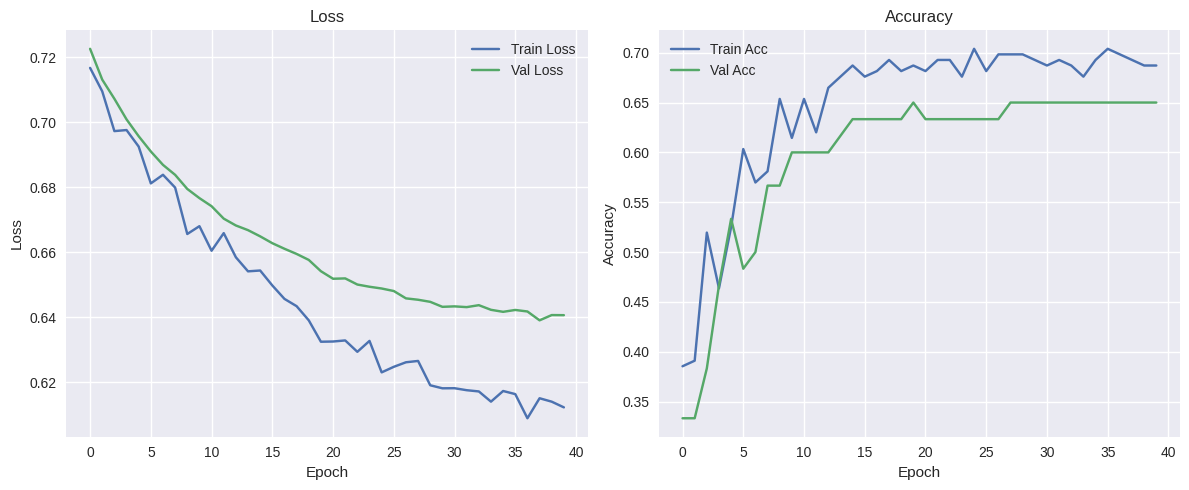

In [133]:
# Complete training pipeline for PSO top-4 -> 4-qubit QNN (run in one cell)
import os
import random
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             roc_auc_score, confusion_matrix, classification_report)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import pennylane as qml
# reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# -------------------------
# Config
# -------------------------
CSV_PATH = "/kaggle/input/heart_failure_clinical_records_dataset.csv"
PSO_TOP4 = ['serum_creatinine','ejection_fraction','creatinine_phosphokinase','serum_sodium']
TARGET_COL = "DEATH_EVENT"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

BATCH_SIZE = 16
NUM_EPOCHS = 150
PATIENCE = 20

n_qubits = 4
n_layers = 2
weight_shapes = {"weights": (n_layers, n_qubits, 3)}

# -------------------------
# Load & preprocess
# -------------------------
df = pd.read_csv(CSV_PATH)
# keep only the chosen columns + target
df = df[PSO_TOP4 + [TARGET_COL]].dropna().reset_index(drop=True)

X = df[PSO_TOP4].values.astype(np.float32)
y = df[TARGET_COL].astype(int).values

# scale per-feature to [0, pi] (good for AngleEmbedding)
scaler = MinMaxScaler(feature_range=(0.0, np.pi))
X_scaled = scaler.fit_transform(X).astype(np.float32)

# train / val / test (60/20/20) stratified
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X_scaled, y, test_size=0.4, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=SEED, stratify=y_tmp
)

class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = DataLoader(TabularDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TabularDataset(X_val,   y_val),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TabularDataset(X_test,  y_test),  batch_size=BATCH_SIZE, shuffle=False)

# -------------------------
# Quantum part (PennyLane)
# -------------------------
dev = qml.device("default.qubit", wires=n_qubits)

def quantum_circuit(inputs, weights):
    # inputs: tensor shape (batch?, n_qubits) — TorchLayer will feed per-sample
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

qnode = qml.QNode(quantum_circuit, dev, interface="torch")

# -------------------------
# Hybrid model (extra classical layer + QLayer + head)
# -------------------------
class HybridQNN(nn.Module):
    def __init__(self, n_features, n_qubits, n_classes, hidden_dim=16, dropout=0.1):
        super().__init__()
        # small MLP to map features to something useful for quantum layer
        self.head = nn.Sequential(
            nn.Linear(n_features, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, n_qubits)
        )
        # quantum layer
        self.q_layer = qml.qnn.TorchLayer(qnode, weight_shapes)
        # classical output
        self.out = nn.Sequential(
            nn.Linear(n_qubits, n_classes)
        )

    def forward(self, x):
        x = self.head(x)           # -> (batch, n_qubits)
        x = self.q_layer(x)        # -> (batch, n_qubits) (expectations)
        x = self.out(x)            # -> (batch, n_classes)
        return x

model = HybridQNN(n_features=len(PSO_TOP4), n_qubits=n_qubits, n_classes=2).to(DEVICE)

# Xavier init for classical layers
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)
model.apply(init_weights)

# -------------------------
# Loss, optimizer, scheduler
# -------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
# cosine scheduler (restarts not used here)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)

# -------------------------
# Training loop (mini-batch), early stopping by val acc
# -------------------------
best_val_acc = 0.0
no_improve = 0

train_history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, NUM_EPOCHS+1):
    # Training
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == yb).sum().item()
        running_total += xb.size(0)

    train_loss = running_loss / running_total
    train_acc = running_correct / running_total

    # Validation
    model.eval()
    val_running_loss = 0.0
    val_running_correct = 0
    val_running_total = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            val_running_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            val_running_correct += (preds == yb).sum().item()
            val_running_total += xb.size(0)

    val_loss = val_running_loss / val_running_total
    val_acc = val_running_correct / val_running_total

    train_history["train_loss"].append(train_loss)
    train_history["val_loss"].append(val_loss)
    train_history["train_acc"].append(train_acc)
    train_history["val_acc"].append(val_acc)

    # scheduler step per epoch
    scheduler.step()

    # Save best
    if val_acc > best_val_acc + 1e-6:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_qnn_model.pth")
        no_improve = 0
    else:
        no_improve += 1

    print(f"Epoch {epoch:03d}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | lr: {scheduler.get_last_lr()[0]:.2e}")

    if no_improve >= PATIENCE:
        print(f"Early stopping after {epoch} epochs (no improvement for {PATIENCE} epochs).")
        break

print(f"Best validation acc: {best_val_acc:.4f}")

# -------------------------
# Load best model and evaluate on test set
# -------------------------
model.load_state_dict(torch.load("best_qnn_model.pth", map_location=DEVICE))
model.eval()

y_true = []
y_pred = []
y_prob = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb)
        probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds = logits.argmax(dim=1).cpu().numpy()
        y_true.extend(yb.cpu().numpy())
        y_pred.extend(preds.tolist())
        y_prob.extend(probs.tolist())

acc = accuracy_score(y_true, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
try:
    auc = roc_auc_score(y_true, y_prob)
except:
    auc = float("nan")

print("\n=== TEST METRICS ===")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}  Recall: {rec:.4f}  F1: {f1:.4f}  AUC: {auc:.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
print("\nClassification Report:\n", classification_report(y_true, y_pred, zero_division=0))

# -------------------------
# Plot training curves
# -------------------------
import matplotlib.pyplot as plt
plt.style.use("seaborn")
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_history["train_loss"], label="Train Loss")
plt.plot(train_history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(train_history["train_acc"], label="Train Acc")
plt.plot(train_history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy")

plt.tight_layout()
plt.show()


In [134]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
import pennylane as qml
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# ===================== DATA PREP =====================
# Assuming df is your loaded heart_failure_clinical_records_dataset.csv
import pandas as pd
df = pd.read_csv("/kaggle/input/heart_failure_clinical_records_dataset.csv")

# Replace this with your actual top-4 PSO-selected features
selected_features = ["age", "ejection_fraction", "serum_creatinine", "time"]  
X = df[selected_features].values
y = df["DEATH_EVENT"].values

X_train, X_valtest, y_train, y_valtest = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_valtest, y_valtest, test_size=0.5, random_state=42, stratify=y_valtest)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Torch dataset
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TabularDataset(X_train, y_train)
val_dataset = TabularDataset(X_val, y_val)
test_dataset = TabularDataset(X_test, y_test)

# ===================== OVERSAMPLING =====================
class_sample_count = np.array([len(np.where(y_train == t)[0]) for t in np.unique(y_train)])
weight = 1. / class_sample_count
samples_weight = np.array([weight[t] for t in y_train])
samples_weight = torch.from_numpy(samples_weight).double()
sampler = WeightedRandomSampler(samples_weight, len(samples_weight))

# ===================== CLASS WEIGHTS =====================
class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

# ===================== QNN MODEL =====================
n_qubits = 4  # Top-4 features
n_layers = 4
dev = qml.device("default.qubit", wires=n_qubits)

def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

weight_shapes = {"weights": (n_layers, n_qubits, 3)}
qnode = qml.QNode(quantum_circuit, dev, interface="torch")

class HybridQNN(nn.Module):
    def __init__(self, n_features, n_qubits, n_classes, hidden_dim=64):
        super(HybridQNN, self).__init__()
        self.fc1 = nn.Linear(n_features, hidden_dim)
        self.fc_bn1 = nn.BatchNorm1d(hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, n_qubits)
        self.q_layer = qml.qnn.TorchLayer(qnode, weight_shapes)
        self.fc3 = nn.Linear(n_qubits, hidden_dim)
        self.fc_bn3 = nn.BatchNorm1d(hidden_dim)
        self.out = nn.Linear(hidden_dim, n_classes)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = torch.relu(self.fc_bn1(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.q_layer(x)
        x = torch.relu(self.fc_bn3(self.fc3(x)))
        x = self.dropout(x)
        x = self.out(x)
        return x

model = HybridQNN(n_features=len(selected_features), n_qubits=n_qubits, n_classes=2).to(DEVICE)

# ===================== TRAINING =====================
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=50, T_mult=1)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, drop_last=True)


NUM_EPOCHS = 300
patience = 50
best_val_acc = 0
epochs_no_improve = 0

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(Xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        scheduler.step(epoch + total/len(train_loader))

        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += yb.size(0)
        correct += (predicted == yb).sum().item()

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            outputs = model(Xb)
            loss = criterion(outputs, yb)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += yb.size(0)
            val_correct += (predicted == yb).sum().item()

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_qnn_model.pth")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Early stopping!")
            break

print(f"✅ Best Validation Accuracy: {best_val_acc:.4f}")

# ===================== TEST EVAL =====================
model.load_state_dict(torch.load("best_qnn_model.pth"))
model.eval()
y_true, y_pred, y_prob = [], [], []
with torch.no_grad():
    for Xb, yb in test_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        outputs = model(Xb)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        _, predicted = torch.max(outputs.data, 1)
        y_true.extend(yb.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob)
cm = confusion_matrix(y_true, y_pred)

print("\n=== TEST METRICS ===")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}  Recall: {rec:.4f}  F1: {f1:.4f}  AUC: {auc:.4f}")
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_true, y_pred))


Epoch [1/300] Train Loss: 0.7525 | Train Acc: 0.5521 | Val Loss: 0.7221 | Val Acc: 0.5938
Epoch [2/300] Train Loss: 0.7329 | Train Acc: 0.5104 | Val Loss: 0.7127 | Val Acc: 0.5938
Epoch [3/300] Train Loss: 0.6946 | Train Acc: 0.5521 | Val Loss: 0.7097 | Val Acc: 0.5938
Epoch [4/300] Train Loss: 0.7497 | Train Acc: 0.4688 | Val Loss: 0.7063 | Val Acc: 0.5938
Epoch [5/300] Train Loss: 0.7170 | Train Acc: 0.5312 | Val Loss: 0.7041 | Val Acc: 0.5938
Epoch [6/300] Train Loss: 0.7090 | Train Acc: 0.5469 | Val Loss: 0.7023 | Val Acc: 0.5938
Epoch [7/300] Train Loss: 0.7284 | Train Acc: 0.4740 | Val Loss: 0.6978 | Val Acc: 0.5938
Epoch [8/300] Train Loss: 0.6815 | Train Acc: 0.5677 | Val Loss: 0.6941 | Val Acc: 0.5938
Epoch [9/300] Train Loss: 0.7120 | Train Acc: 0.5260 | Val Loss: 0.6903 | Val Acc: 0.5000
Epoch [10/300] Train Loss: 0.6879 | Train Acc: 0.5260 | Val Loss: 0.6841 | Val Acc: 0.5938
Epoch [11/300] Train Loss: 0.6962 | Train Acc: 0.5260 | Val Loss: 0.6771 | Val Acc: 0.6250
Epoch [1

In [135]:
# 6-qubit QNN training with Stratified K-Fold, augmentation, deeper QNN, tuned classical head
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, classification_report)
import pennylane as qml

# ------------------ Config ------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
TOP_FEATURES = ['serum_creatinine', 'ejection_fraction',
                'creatinine_phosphokinase', 'serum_sodium',
                'anaemia', 'diabetes']   # final PSO top-6
CSV_PATH = "/kaggle/input/heart_failure_clinical_records_dataset.csv"

N_QUBITS = 6           # <- you requested 6 qubits
N_LAYERS = 4           # strongly-entangling layers depth
HIDDEN_DIM = 256
EPOCHS = 300
BATCH_SIZE = 16
LR = 1e-4
KFOLDS = 5
NOISE_STD = 0.01       # gaussian noise for augmentation
PATIENCE = 30
SEED = 42
# --------------------------------------------

# reproducibility
np.random.seed(SEED)
torch.manual_seed(SEED)

# ------------------ Load & preprocess ------------------
df = pd.read_csv(CSV_PATH)
df = df.dropna().reset_index(drop=True)

X_raw = df[TOP_FEATURES].values.astype(np.float32)
y_raw = df["DEATH_EVENT"].values.astype(int)

# Scale each feature to [0, pi] for AngleEmbedding (per-feature MinMax)
scaler = MinMaxScaler(feature_range=(0.0, np.pi))
X_scaled_all = scaler.fit_transform(X_raw).astype(np.float32)

# Function: augment (adds small gaussian noise to continuous features)
def augment_features(X, noise_std=NOISE_STD):
    X_aug = X.copy().astype(np.float32)
    # treat 'anaemia', 'diabetes' as discrete (0/1) — do not add noise there
    # we'll determine indices of binary columns
    binary_cols = []
    for idx, col in enumerate(TOP_FEATURES):
        if set(df[col].unique()).issubset({0,1}):
            binary_cols.append(idx)
    cont_idx = [i for i in range(X.shape[1]) if i not in binary_cols]
    noise = np.random.normal(0.0, noise_std, size=(X.shape[0], len(cont_idx))).astype(np.float32)
    X_aug[:, cont_idx] += noise
    # clip back to [0, pi]
    X_aug[:, cont_idx] = np.clip(X_aug[:, cont_idx], 0.0, np.pi)
    # round binary columns (in case noise affected them)
    for b in binary_cols:
        X_aug[:, b] = np.round(X_aug[:, b]).astype(np.float32)
    return X_aug

# Use X_scaled_all and y_raw for stratified folds
X_all = X_scaled_all
y_all = y_raw

# ------------------ Quantum setup ------------------
dev = qml.device("default.qubit", wires=N_QUBITS)

def quantum_circuit(inputs, weights):
    # inputs shape must match N_QUBITS
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation='Y')  # AngleEmbedding along Y
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

weight_shapes = {"weights": (N_LAYERS, N_QUBITS, 3)}
qnode = qml.QNode(quantum_circuit, dev, interface="torch")

# ------------------ Hybrid PyTorch model ------------------
class HybridQNN(nn.Module):
    def __init__(self, n_features, n_qubits, n_classes, hidden_dim=HIDDEN_DIM, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(n_features, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.act1 = nn.LeakyReLU(0.1)
        self.fc2 = nn.Linear(hidden_dim, n_qubits)
        self.q_layer = qml.qnn.TorchLayer(qnode, weight_shapes)
        self.fc3 = nn.Linear(n_qubits, hidden_dim)
        self.bn3 = nn.BatchNorm1d(hidden_dim)
        self.act3 = nn.LeakyReLU(0.1)
        self.dropout = nn.Dropout(dropout)
        self.out = nn.Linear(hidden_dim, n_classes)

    def forward(self, x):
        x = self.act1(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc2(x)                 # shape (batch, n_qubits)
        x = self.q_layer(x)            # quantum output shape (batch, n_qubits)
        x = self.act3(self.bn3(self.fc3(x)))
        x = self.dropout(x)
        x = self.out(x)
        return x

# ------------------ K-Fold training ------------------
skf = StratifiedKFold(n_splits=KFOLDS, shuffle=True, random_state=SEED)
fold_metrics = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_all, y_all), 1):
    print(f"\n===== Fold {fold}/{KFOLDS} =====")
    X_train_raw, X_test = X_all[train_idx], X_all[test_idx]
    y_train, y_test = y_all[train_idx], y_all[test_idx]

    # Augment training data (create augmented version + original)
    X_train_aug = augment_features(X_train_raw, noise_std=NOISE_STD)
    # Option: combine original + augmented to enlarge training set
    X_train_comb = np.vstack([X_train_raw, X_train_aug])
    y_train_comb = np.concatenate([y_train, y_train])

    # Create DataLoaders
    train_ds = TensorDataset(torch.tensor(X_train_comb, dtype=torch.float32),
                             torch.tensor(y_train_comb, dtype=torch.long))
    test_ds = TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                            torch.tensor(y_test, dtype=torch.long))

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    # Model + optimizer + criterion
    model = HybridQNN(n_features=len(TOP_FEATURES), n_qubits=N_QUBITS, n_classes=2,
                      hidden_dim=HIDDEN_DIM, dropout=0.1).to(DEVICE)
    # init classical layers
    def init_weights(m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
    model.apply(init_weights)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

    best_val_acc = 0.0
    patience_counter = 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss = 0.0
        running_correct = 0
        running_total = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            running_correct += (preds == yb).sum().item()
            running_total += xb.size(0)

        train_loss = running_loss / running_total
        train_acc = running_correct / running_total

        # Validation (on test set for this fold)
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                loss = criterion(logits, yb)
                val_loss += loss.item() * xb.size(0)
                preds = logits.argmax(dim=1)
                val_correct += (preds == yb).sum().item()
                val_total += xb.size(0)

        val_loss = val_loss / val_total
        val_acc = val_correct / val_total

        if val_acc > best_val_acc + 1e-6:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), f"best_qnn_fold{fold}.pth")
        else:
            patience_counter += 1

        print(f"Epoch {epoch:03d}/{EPOCHS} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch} (no improvement {PATIENCE} epochs).")
            break

    # Load best model for this fold and evaluate
    model.load_state_dict(torch.load(f"best_qnn_fold{fold}.pth", map_location=DEVICE))
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            preds = logits.argmax(dim=1).cpu().numpy()
            y_true.extend(yb.numpy())
            y_pred.extend(preds.tolist())
            y_prob.extend(probs.tolist())

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_prob)
    except:
        auc = float("nan")
    cm = confusion_matrix(y_true, y_pred)

    print("\n=== TEST METRICS (fold {}) ===".format(fold))
    print(f"Accuracy: {acc:.4f}  Precision: {prec:.4f}  Recall: {rec:.4f}  F1: {f1:.4f}  AUC: {auc:.4f}")
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", classification_report(y_true, y_pred, zero_division=0))

    fold_metrics.append([acc, prec, rec, f1, auc])

# ------------------ Average across folds ------------------
fold_metrics = np.array(fold_metrics)
print("\n===== Average across folds =====")
print(f"Accuracy: {fold_metrics[:,0].mean():.4f} ± {fold_metrics[:,0].std():.4f}")
print(f"Precision: {fold_metrics[:,1].mean():.4f}")
print(f"Recall: {fold_metrics[:,2].mean():.4f}")
print(f"F1: {fold_metrics[:,3].mean():.4f}")
print(f"AUC: {np.nanmean(fold_metrics[:,4]):.4f}")



===== Fold 1/5 =====
Epoch 001/300 | Train Loss: 0.7080 Acc: 0.6250 | Val Loss: 0.6601 Acc: 0.6667
Epoch 002/300 | Train Loss: 0.6589 Acc: 0.6293 | Val Loss: 0.6302 Acc: 0.6833
Epoch 003/300 | Train Loss: 0.6412 Acc: 0.6466 | Val Loss: 0.6129 Acc: 0.6667
Epoch 004/300 | Train Loss: 0.6566 Acc: 0.6487 | Val Loss: 0.6163 Acc: 0.6667
Epoch 005/300 | Train Loss: 0.6436 Acc: 0.6509 | Val Loss: 0.6055 Acc: 0.6833
Epoch 006/300 | Train Loss: 0.6174 Acc: 0.6703 | Val Loss: 0.5945 Acc: 0.7000
Epoch 007/300 | Train Loss: 0.6303 Acc: 0.6573 | Val Loss: 0.5978 Acc: 0.6833
Epoch 008/300 | Train Loss: 0.6174 Acc: 0.6638 | Val Loss: 0.5991 Acc: 0.7000
Epoch 009/300 | Train Loss: 0.6231 Acc: 0.6681 | Val Loss: 0.5985 Acc: 0.7167
Epoch 010/300 | Train Loss: 0.6043 Acc: 0.6746 | Val Loss: 0.5931 Acc: 0.6833
Epoch 011/300 | Train Loss: 0.6026 Acc: 0.6897 | Val Loss: 0.5882 Acc: 0.6667
Epoch 012/300 | Train Loss: 0.6029 Acc: 0.6940 | Val Loss: 0.5940 Acc: 0.6833
Epoch 013/300 | Train Loss: 0.6196 Acc: 0.

In [136]:
# ----------------------------
# 0️⃣ Imports
# ----------------------------
import pennylane as qml
from pennylane import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# ----------------------------
# 1️⃣ Config
# ----------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CSV_PATH = "/kaggle/input/heart_failure_clinical_records_dataset.csv"
TOP_FEATURES = ['anaemia', 'creatinine_phosphokinase', 'diabetes',
                'ejection_fraction', 'high_blood_pressure',
                'serum_creatinine', 'serum_sodium', 'smoking']

N_QUBITS = 6
N_LAYERS = 6
HIDDEN_DIM = 64
EPOCHS = 50
LR = 1e-4
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

# ----------------------------
# 2️⃣ Load & preprocess
# ----------------------------
df = pd.read_csv(CSV_PATH).dropna().reset_index(drop=True)
X_raw = df[TOP_FEATURES].values.astype(np.float32)
y_raw = df["DEATH_EVENT"].values.astype(int)

# Scale features to [0, pi] for AngleEmbedding
scaler = MinMaxScaler(feature_range=(0.0, np.pi))
X_scaled = scaler.fit_transform(X_raw).astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_raw, test_size=0.2, random_state=SEED, stratify=y_raw
)

X_train = torch.tensor(X_train, dtype=torch.float32).to(DEVICE)
y_train = torch.tensor(y_train, dtype=torch.long).to(DEVICE)
X_test = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
y_test = torch.tensor(y_test, dtype=torch.long).to(DEVICE)

# ----------------------------
# 3️⃣ Quantum Device & QNode
# ----------------------------
dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation='Y')
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

weight_shapes = {"weights": (N_LAYERS, N_QUBITS, 3)}
qlayer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

# ----------------------------
# 4️⃣ Hybrid Classical + Quantum Model
# ----------------------------
class HybridQNN(nn.Module):
    def __init__(self, input_dim=X_train.shape[1], hidden_dim=HIDDEN_DIM, output_dim=2):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.act1 = nn.LeakyReLU(0.2)
        self.dropout1 = nn.Dropout(0.1)
        
        self.fc2 = nn.Linear(hidden_dim, N_QUBITS)
        self.qnn = qlayer
        
        self.fc3 = nn.Linear(N_QUBITS, hidden_dim)
        self.act3 = nn.LeakyReLU(0.2)
        self.dropout3 = nn.Dropout(0.1)
        self.out = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.act1(self.fc1(x))
        x = self.dropout1(x)
        x = self.fc2(x)
        x = self.qnn(x)
        x = self.act3(self.fc3(x))
        x = self.dropout3(x)
        return self.out(x)

model = HybridQNN().to(DEVICE)

# ----------------------------
# 5️⃣ Stage 1: AdamW Training
# ----------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR)

for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    if (epoch+1) % 10 == 0:
        model.eval()
        with torch.no_grad():
            pred = torch.argmax(model(X_test), dim=1)
            acc = (pred == y_test).float().mean()
        print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {loss.item():.4f}, Test Acc: {acc:.4f}")




# ----------------------------
# 7️⃣ Evaluation
# ----------------------------
model.eval()
with torch.no_grad():
    pred = torch.argmax(model(X_test), dim=1)
    acc = (pred == y_test).float().mean()
    print(f"Final Test Accuracy after COBYLA: {acc:.4f}")


Epoch [10/50], Loss: 0.6919, Test Acc: 0.7167
Epoch [20/50], Loss: 0.6867, Test Acc: 0.6833
Epoch [30/50], Loss: 0.6818, Test Acc: 0.6833
Epoch [40/50], Loss: 0.6786, Test Acc: 0.6833
Epoch [50/50], Loss: 0.6749, Test Acc: 0.6833
Final Test Accuracy after COBYLA: 0.6833


In [137]:
# 8-qubit QNN training with Stratified K-Fold, augmentation, deeper QNN, tuned classical head
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, classification_report)
import pennylane as qml

# ------------------ Config ------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
TOP_FEATURES = ['anaemia', 'creatinine_phosphokinase', 'diabetes',
                'ejection_fraction', 'high_blood_pressure', 'serum_creatinine',
                'serum_sodium', 'smoking']   # final PSO top-8
CSV_PATH = "/kaggle/input/heart_failure_clinical_records_dataset.csv"

N_QUBITS = 8           # upgraded to 8 qubits
N_LAYERS = 4           # strongly-entangling layers depth
HIDDEN_DIM = 256
EPOCHS = 300
BATCH_SIZE = 16
LR = 1e-4
KFOLDS = 5
NOISE_STD = 0.01       # gaussian noise for augmentation
PATIENCE = 30
SEED = 42
# --------------------------------------------

# reproducibility
np.random.seed(SEED)
torch.manual_seed(SEED)

# ------------------ Load & preprocess ------------------
df = pd.read_csv(CSV_PATH)
df = df.dropna().reset_index(drop=True)

X_raw = df[TOP_FEATURES].values.astype(np.float32)
y_raw = df["DEATH_EVENT"].values.astype(int)

# Scale each feature to [0, pi] for AngleEmbedding (per-feature MinMax)
scaler = MinMaxScaler(feature_range=(0.0, np.pi))
X_scaled_all = scaler.fit_transform(X_raw).astype(np.float32)

# Function: augment (adds small gaussian noise to continuous features)
def augment_features(X, noise_std=NOISE_STD):
    X_aug = X.copy().astype(np.float32)
    # treat binary columns (0/1) — do not add noise
    binary_cols = [idx for idx, col in enumerate(TOP_FEATURES)
                   if set(df[col].unique()).issubset({0,1})]
    cont_idx = [i for i in range(X.shape[1]) if i not in binary_cols]
    noise = np.random.normal(0.0, noise_std, size=(X.shape[0], len(cont_idx))).astype(np.float32)
    X_aug[:, cont_idx] += noise
    X_aug[:, cont_idx] = np.clip(X_aug[:, cont_idx], 0.0, np.pi)
    for b in binary_cols:
        X_aug[:, b] = np.round(X_aug[:, b]).astype(np.float32)
    return X_aug

X_all = X_scaled_all
y_all = y_raw

# ------------------ Quantum setup ------------------
dev = qml.device("default.qubit", wires=N_QUBITS)

def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation='Y')
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

weight_shapes = {"weights": (N_LAYERS, N_QUBITS, 3)}
qnode = qml.QNode(quantum_circuit, dev, interface="torch")

# ------------------ Hybrid PyTorch model ------------------
class HybridQNN(nn.Module):
    def __init__(self, n_features, n_qubits, n_classes, hidden_dim=HIDDEN_DIM, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(n_features, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.act1 = nn.LeakyReLU(0.1)
        self.fc2 = nn.Linear(hidden_dim, n_qubits)
        self.q_layer = qml.qnn.TorchLayer(qnode, weight_shapes)
        self.fc3 = nn.Linear(n_qubits, hidden_dim)
        self.bn3 = nn.BatchNorm1d(hidden_dim)
        self.act3 = nn.LeakyReLU(0.1)
        self.dropout = nn.Dropout(dropout)
        self.out = nn.Linear(hidden_dim, n_classes)

    def forward(self, x):
        x = self.act1(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.q_layer(x)
        x = self.act3(self.bn3(self.fc3(x)))
        x = self.dropout(x)
        x = self.out(x)
        return x

# ------------------ K-Fold training ------------------
skf = StratifiedKFold(n_splits=KFOLDS, shuffle=True, random_state=SEED)
fold_metrics = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_all, y_all), 1):
    print(f"\n===== Fold {fold}/{KFOLDS} =====")
    X_train_raw, X_test = X_all[train_idx], X_all[test_idx]
    y_train, y_test = y_all[train_idx], y_all[test_idx]

    # Augment training data
    X_train_aug = augment_features(X_train_raw, noise_std=NOISE_STD)
    X_train_comb = np.vstack([X_train_raw, X_train_aug])
    y_train_comb = np.concatenate([y_train, y_train])

    train_ds = TensorDataset(torch.tensor(X_train_comb, dtype=torch.float32),
                             torch.tensor(y_train_comb, dtype=torch.long))
    test_ds = TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                            torch.tensor(y_test, dtype=torch.long))

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    model = HybridQNN(n_features=len(TOP_FEATURES), n_qubits=N_QUBITS, n_classes=2,
                      hidden_dim=HIDDEN_DIM, dropout=0.1).to(DEVICE)

    def init_weights(m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
    model.apply(init_weights)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

    best_val_acc = 0.0
    patience_counter = 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss = 0.0
        running_correct = 0
        running_total = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            running_correct += (preds == yb).sum().item()
            running_total += xb.size(0)

        train_loss = running_loss / running_total
        train_acc = running_correct / running_total

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                loss = criterion(logits, yb)
                val_loss += loss.item() * xb.size(0)
                preds = logits.argmax(dim=1)
                val_correct += (preds == yb).sum().item()
                val_total += xb.size(0)
        val_loss /= val_total
        val_acc = val_correct / val_total

        if val_acc > best_val_acc + 1e-6:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), f"best_qnn_fold{fold}.pth")
        else:
            patience_counter += 1

        print(f"Epoch {epoch:03d}/{EPOCHS} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}.")
            break

    # Load best model and evaluate
    model.load_state_dict(torch.load(f"best_qnn_fold{fold}.pth", map_location=DEVICE))
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            preds = logits.argmax(dim=1).cpu().numpy()
            y_true.extend(yb.numpy())
            y_pred.extend(preds.tolist())
            y_prob.extend(probs.tolist())

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_prob)
    except:
        auc = float("nan")
    cm = confusion_matrix(y_true, y_pred)

    print("\n=== TEST METRICS (fold {}) ===".format(fold))
    print(f"Accuracy: {acc:.4f}  Precision: {prec:.4f}  Recall: {rec:.4f}  F1: {f1:.4f}  AUC: {auc:.4f}")
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", classification_report(y_true, y_pred, zero_division=0))

    fold_metrics.append([acc, prec, rec, f1, auc])

# ------------------ Average across folds ------------------
fold_metrics = np.array(fold_metrics)
print("\n===== Average across folds =====")
print(f"Accuracy: {fold_metrics[:,0].mean():.4f} ± {fold_metrics[:,0].std():.4f}")
print(f"Precision: {fold_metrics[:,1].mean():.4f}")
print(f"Recall: {fold_metrics[:,2].mean():.4f}")
print(f"F1: {fold_metrics[:,3].mean():.4f}")
print(f"AUC: {np.nanmean(fold_metrics[:,4]):.4f}")



===== Fold 1/5 =====
Epoch 001/300 | Train Loss: 0.7300 Acc: 0.6013 | Val Loss: 0.6841 Acc: 0.7167
Epoch 002/300 | Train Loss: 0.6757 Acc: 0.6379 | Val Loss: 0.6414 Acc: 0.7167
Epoch 003/300 | Train Loss: 0.6453 Acc: 0.6444 | Val Loss: 0.6182 Acc: 0.6833
Epoch 004/300 | Train Loss: 0.6445 Acc: 0.6595 | Val Loss: 0.6175 Acc: 0.6833
Epoch 005/300 | Train Loss: 0.6504 Acc: 0.6207 | Val Loss: 0.6114 Acc: 0.6833
Epoch 006/300 | Train Loss: 0.6155 Acc: 0.6659 | Val Loss: 0.6235 Acc: 0.6500
Epoch 007/300 | Train Loss: 0.6426 Acc: 0.6659 | Val Loss: 0.6213 Acc: 0.6667
Epoch 008/300 | Train Loss: 0.6426 Acc: 0.6724 | Val Loss: 0.6326 Acc: 0.6500
Epoch 009/300 | Train Loss: 0.6001 Acc: 0.6832 | Val Loss: 0.6345 Acc: 0.6500
Epoch 010/300 | Train Loss: 0.6446 Acc: 0.6789 | Val Loss: 0.6212 Acc: 0.6167
Epoch 011/300 | Train Loss: 0.6132 Acc: 0.6789 | Val Loss: 0.6175 Acc: 0.6333
Epoch 012/300 | Train Loss: 0.5975 Acc: 0.6832 | Val Loss: 0.6141 Acc: 0.6500
Epoch 013/300 | Train Loss: 0.6145 Acc: 0.

In [138]:
!pip install -q --upgrade scikit-learn imbalanced-learn


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.7.1 which is incompatible.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.7.1 which is incompatible.
bigframes 1.36.0 requires rich<14,>=12.4.4, but you have rich 14.0.0 which is incompatible.


In [139]:
# ----------------------------
# 0️⃣ Imports
# ----------------------------
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, classification_report)
import pennylane as qml

# ----------------------------
# 1️⃣ Config
# ----------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CSV_PATH = "/kaggle/input/heart_failure_clinical_records_dataset.csv"
TOP_FEATURES = ['anaemia', 'creatinine_phosphokinase', 'diabetes',
                'ejection_fraction', 'high_blood_pressure', 'serum_creatinine',
                'serum_sodium', 'smoking']

N_QUBITS = 8
N_LAYERS = 4
HIDDEN_DIM = 256
EPOCHS = 300
BATCH_SIZE = 16
LR = 1e-4
KFOLDS = 5
NOISE_STD = 0.01
PATIENCE = 30
SEED = 42

# reproducibility
np.random.seed(SEED)
torch.manual_seed(SEED)

# ----------------------------
# 2️⃣ Load & preprocess
# ----------------------------
df = pd.read_csv(CSV_PATH).dropna().reset_index(drop=True)

# Count original classes
num_0 = (df["DEATH_EVENT"] == 0).sum()
num_1 = (df["DEATH_EVENT"] == 1).sum()
print(f"Original Class 0: {num_0}, Class 1: {num_1}")

X_raw = df[TOP_FEATURES].values.astype(np.float32)
y_raw = df["DEATH_EVENT"].values.astype(int)

# Scale features to [0, pi] for AngleEmbedding
scaler = MinMaxScaler(feature_range=(0.0, np.pi))
X_scaled_all = scaler.fit_transform(X_raw).astype(np.float32)
X_all = X_scaled_all
y_all = y_raw

# ----------------------------
# 3️⃣ Augmentation function
# ----------------------------
def augment_features(X, noise_std=NOISE_STD):
    X_aug = X.copy()
    # Identify binary columns
    binary_cols = [idx for idx, col in enumerate(TOP_FEATURES) if set(df[col].unique()).issubset({0,1})]
    cont_idx = [i for i in range(X.shape[1]) if i not in binary_cols]
    # Add Gaussian noise only to continuous features
    noise = np.random.normal(0.0, noise_std, size=(X.shape[0], len(cont_idx))).astype(np.float32)
    X_aug[:, cont_idx] += noise
    X_aug[:, cont_idx] = np.clip(X_aug[:, cont_idx], 0.0, np.pi)
    # Keep binary columns exact
    for b in binary_cols:
        X_aug[:, b] = np.round(X_aug[:, b]).astype(np.float32)
    return X_aug

# ----------------------------
# 4️⃣ Quantum setup
# ----------------------------
dev = qml.device("default.qubit", wires=N_QUBITS)

def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation='Y')
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

weight_shapes = {"weights": (N_LAYERS, N_QUBITS, 3)}
qnode = qml.QNode(quantum_circuit, dev, interface="torch")

# ----------------------------
# 5️⃣ Hybrid QNN model
# ----------------------------
class HybridQNN(nn.Module):
    def __init__(self, n_features, n_qubits, n_classes, hidden_dim=HIDDEN_DIM, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(n_features, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.act1 = nn.LeakyReLU(0.1)
        self.fc2 = nn.Linear(hidden_dim, n_qubits)
        self.q_layer = qml.qnn.TorchLayer(qnode, weight_shapes)
        self.fc3 = nn.Linear(n_qubits, hidden_dim)
        self.bn3 = nn.BatchNorm1d(hidden_dim)
        self.act3 = nn.LeakyReLU(0.1)
        self.dropout = nn.Dropout(dropout)
        self.out = nn.Linear(hidden_dim, n_classes)

    def forward(self, x):
        x = self.act1(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.q_layer(x)
        x = self.act3(self.bn3(self.fc3(x)))
        x = self.dropout(x)
        x = self.out(x)
        return x

# ----------------------------
# 6️⃣ K-Fold training with augmentation
# ----------------------------
skf = StratifiedKFold(n_splits=KFOLDS, shuffle=True, random_state=SEED)
fold_metrics = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_all, y_all), 1):
    print(f"\n===== Fold {fold}/{KFOLDS} =====")
    X_train_raw, X_test = X_all[train_idx], X_all[test_idx]
    y_train, y_test = y_all[train_idx], y_all[test_idx]

    # Augment training data
    X_train_aug = augment_features(X_train_raw)
    X_train_comb = np.vstack([X_train_raw, X_train_aug])
    y_train_comb = np.concatenate([y_train, y_train])

    train_ds = TensorDataset(torch.tensor(X_train_comb, dtype=torch.float32),
                             torch.tensor(y_train_comb, dtype=torch.long))
    test_ds = TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                            torch.tensor(y_test, dtype=torch.long))

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    model = HybridQNN(n_features=len(TOP_FEATURES), n_qubits=N_QUBITS, n_classes=2,
                      hidden_dim=HIDDEN_DIM, dropout=0.1).to(DEVICE)

    # Initialize weights
    def init_weights(m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
    model.apply(init_weights)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

    best_val_acc = 0.0
    patience_counter = 0

    for epoch in range(1, EPOCHS + 1):
        # Training
        model.train()
        running_loss, running_correct, running_total = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
            running_correct += (logits.argmax(dim=1) == yb).sum().item()
            running_total += xb.size(0)
        train_loss = running_loss / running_total
        train_acc = running_correct / running_total

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                loss = criterion(logits, yb)
                val_loss += loss.item() * xb.size(0)
                val_correct += (logits.argmax(dim=1) == yb).sum().item()
                val_total += xb.size(0)
        val_loss /= val_total
        val_acc = val_correct / val_total

        if val_acc > best_val_acc + 1e-6:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), f"best_qnn_fold{fold}.pth")
        else:
            patience_counter += 1

        print(f"Epoch {epoch:03d}/{EPOCHS} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}.")
            break

    # Load best model and evaluate
    model.load_state_dict(torch.load(f"best_qnn_fold{fold}.pth", map_location=DEVICE))
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            preds = logits.argmax(dim=1).cpu().numpy()
            y_true.extend(yb.numpy())
            y_pred.extend(preds.tolist())
            y_prob.extend(probs.tolist())

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_prob)
    except:
        auc = float("nan")
    cm = confusion_matrix(y_true, y_pred)

    print("\n=== TEST METRICS (fold {}) ===".format(fold))
    print(f"Accuracy: {acc:.4f}  Precision: {prec:.4f}  Recall: {rec:.4f}  F1: {f1:.4f}  AUC: {auc:.4f}")
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", classification_report(y_true, y_pred, zero_division=0))

    fold_metrics.append([acc, prec, rec, f1, auc])

# ----------------------------
# 7️⃣ Average metrics
# ----------------------------
fold_metrics = np.array(fold_metrics)
print("\n===== Average across folds =====")
print(f"Accuracy: {fold_metrics[:,0].mean():.4f} ± {fold_metrics[:,0].std():.4f}")
print(f"Precision: {fold_metrics[:,1].mean():.4f}")
print(f"Recall: {fold_metrics[:,2].mean():.4f}")
print(f"F1: {fold_metrics[:,3].mean():.4f}")
print(f"AUC: {np.nanmean(fold_metrics[:,4]):.4f}")


Original Class 0: 203, Class 1: 96

===== Fold 1/5 =====
Epoch 001/300 | Train Loss: 0.7300 Acc: 0.6013 | Val Loss: 0.6841 Acc: 0.7167
Epoch 002/300 | Train Loss: 0.6757 Acc: 0.6379 | Val Loss: 0.6414 Acc: 0.7167
Epoch 003/300 | Train Loss: 0.6453 Acc: 0.6444 | Val Loss: 0.6182 Acc: 0.6833
Epoch 004/300 | Train Loss: 0.6445 Acc: 0.6595 | Val Loss: 0.6175 Acc: 0.6833
Epoch 005/300 | Train Loss: 0.6504 Acc: 0.6207 | Val Loss: 0.6114 Acc: 0.6833
Epoch 006/300 | Train Loss: 0.6155 Acc: 0.6659 | Val Loss: 0.6235 Acc: 0.6500
Epoch 007/300 | Train Loss: 0.6426 Acc: 0.6659 | Val Loss: 0.6213 Acc: 0.6667
Epoch 008/300 | Train Loss: 0.6426 Acc: 0.6724 | Val Loss: 0.6326 Acc: 0.6500
Epoch 009/300 | Train Loss: 0.6001 Acc: 0.6832 | Val Loss: 0.6345 Acc: 0.6500
Epoch 010/300 | Train Loss: 0.6446 Acc: 0.6789 | Val Loss: 0.6212 Acc: 0.6167
Epoch 011/300 | Train Loss: 0.6132 Acc: 0.6789 | Val Loss: 0.6175 Acc: 0.6333
Epoch 012/300 | Train Loss: 0.5975 Acc: 0.6832 | Val Loss: 0.6141 Acc: 0.6500
Epoch 0

In [140]:
!pip install -U scikit-learn imbalanced-learn


In [141]:
!pip install scikit-learn==1.2.2 imbalanced-learn==0.10.1


  Using cached scikit_learn-1.2.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
  Using cached imbalanced_learn-0.10.1-py3-none-any.whl.metadata (8.2 kB)
Using cached scikit_learn-1.2.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (9.6 MB)
Using cached imbalanced_learn-0.10.1-py3-none-any.whl (226 kB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.7.1
    Uninstalling scikit-learn-1.7.1:
      Successfully uninstalled scikit-learn-1.7.1
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.14.0
    Uninstalling imbalanced-learn-0.14.0:
      Successfully uninstalled imbalanced-learn-0.14.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
nilearn 0.11.1 requires scikit-learn>=1.4.0, but you have scikit-learn 1.2.2 which is incompatible.
bigfram

In [142]:
# ----------------------------
# 0️⃣ Imports
# ----------------------------
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, classification_report)
from imblearn.over_sampling import SMOTE
import pennylane as qml

# ----------------------------
# 1️⃣ Config
# ----------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CSV_PATH = "/kaggle/input/heart_failure_clinical_records_dataset.csv"
TOP_FEATURES = ['anaemia', 'creatinine_phosphokinase', 'diabetes',
                'ejection_fraction', 'high_blood_pressure', 'serum_creatinine',
                'serum_sodium', 'smoking']  # PSO selected top-8 features

N_QUBITS = 8
N_LAYERS = 4
HIDDEN_DIM = 256
EPOCHS = 300
BATCH_SIZE = 16
LR = 1e-4
KFOLDS = 5
NOISE_STD = 0.01
PATIENCE = 30
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

# ----------------------------
# 2️⃣ Load & preprocess
# ----------------------------
df = pd.read_csv(CSV_PATH).dropna().reset_index(drop=True)
X_raw = df[TOP_FEATURES].values.astype(np.float32)
y_raw = df["DEATH_EVENT"].values.astype(int)

# ----------------------------
# 3️⃣ Balance classes using SMOTE
# ----------------------------
smote = SMOTE(random_state=SEED)
X_resampled, y_resampled = smote.fit_resample(X_raw, y_raw)

# Scale features to [0, pi] for quantum embedding
scaler = MinMaxScaler(feature_range=(0.0, np.pi))
X_scaled = scaler.fit_transform(X_resampled).astype(np.float32)

# ----------------------------
# 4️⃣ Augmentation (Gaussian noise for continuous features)
# ----------------------------
def augment_features(X, df_cols, noise_std=NOISE_STD):
    X_aug = X.copy()
    binary_cols = [idx for idx, col in enumerate(TOP_FEATURES) if set(df[col].unique()).issubset({0,1})]
    cont_idx = [i for i in range(X.shape[1]) if i not in binary_cols]
    noise = np.random.normal(0.0, noise_std, size=(X.shape[0], len(cont_idx))).astype(np.float32)
    X_aug[:, cont_idx] += noise
    X_aug[:, cont_idx] = np.clip(X_aug[:, cont_idx], 0.0, np.pi)
    for b in binary_cols:
        X_aug[:, b] = np.round(X_aug[:, b]).astype(np.float32)
    return X_aug

X_aug = augment_features(X_scaled, df)

# Combine original + augmented data
X_final = np.vstack([X_scaled, X_aug])
y_final = np.hstack([y_resampled, y_resampled])

print(f"Balanced & Augmented Dataset: Class 0: {(y_final==0).sum()}, Class 1: {(y_final==1).sum()}")

# ----------------------------
# 5️⃣ Quantum Setup
# ----------------------------
dev = qml.device("default.qubit", wires=N_QUBITS)

def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation='Y')
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

weight_shapes = {"weights": (N_LAYERS, N_QUBITS, 3)}
qnode = qml.QNode(quantum_circuit, dev, interface="torch")

# ----------------------------
# 6️⃣ Hybrid QNN Model
# ----------------------------
class HybridQNN(nn.Module):
    def __init__(self, n_features=len(TOP_FEATURES), n_qubits=N_QUBITS, n_classes=2,
                 hidden_dim=HIDDEN_DIM, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(n_features, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.act1 = nn.LeakyReLU(0.1)
        self.fc2 = nn.Linear(hidden_dim, n_qubits)
        self.q_layer = qml.qnn.TorchLayer(qnode, weight_shapes)
        self.fc3 = nn.Linear(n_qubits, hidden_dim)
        self.bn3 = nn.BatchNorm1d(hidden_dim)
        self.act3 = nn.LeakyReLU(0.1)
        self.dropout = nn.Dropout(dropout)
        self.out = nn.Linear(hidden_dim, n_classes)

    def forward(self, x):
        x = self.act1(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.q_layer(x)
        x = self.act3(self.bn3(self.fc3(x)))
        x = self.dropout(x)
        x = self.out(x)
        return x

# ----------------------------
# 7️⃣ Stratified K-Fold Training
# ----------------------------
skf = StratifiedKFold(n_splits=KFOLDS, shuffle=True, random_state=SEED)
fold_metrics = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_final, y_final), 1):
    print(f"\n===== Fold {fold}/{KFOLDS} =====")
    X_train, X_test = X_final[train_idx], X_final[test_idx]
    y_train, y_test = y_final[train_idx], y_final[test_idx]

    train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                             torch.tensor(y_train, dtype=torch.long))
    test_ds = TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                            torch.tensor(y_test, dtype=torch.long))

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    model = HybridQNN().to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

    best_val_acc = 0
    patience_counter = 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss, running_correct, running_total = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
            running_correct += (logits.argmax(dim=1) == yb).sum().item()
            running_total += xb.size(0)

        train_loss = running_loss / running_total
        train_acc = running_correct / running_total

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                loss = criterion(logits, yb)
                val_loss += loss.item() * xb.size(0)
                val_correct += (logits.argmax(dim=1) == yb).sum().item()
                val_total += xb.size(0)
        val_loss /= val_total
        val_acc = val_correct / val_total

        if val_acc > best_val_acc + 1e-6:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), f"best_qnn_fold{fold}.pth")
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}.")
            break

        if epoch % 20 == 0 or epoch == 1:
            print(f"Epoch {epoch} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    # Load best model and evaluate
    model.load_state_dict(torch.load(f"best_qnn_fold{fold}.pth", map_location=DEVICE))
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            y_true.extend(yb.numpy())
            y_pred.extend(logits.argmax(dim=1).cpu().numpy())
            y_prob.extend(torch.softmax(logits, dim=1)[:,1].cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_prob)
    except:
        auc = float("nan")
    cm = confusion_matrix(y_true, y_pred)

    print(f"\nFold {fold} Metrics: Acc={acc:.4f}, Prec={prec:.4f}, Rec={rec:.4f}, F1={f1:.4f}, AUC={auc:.4f}")
    print("Confusion Matrix:\n", cm)
    fold_metrics.append([acc, prec, rec, f1, auc])

# ----------------------------
# 8️⃣ Average metrics across folds
# ----------------------------
fold_metrics = np.array(fold_metrics)
print("\n===== Average across folds =====")
print(f"Accuracy: {fold_metrics[:,0].mean():.4f} ± {fold_metrics[:,0].std():.4f}")
print(f"Precision: {fold_metrics[:,1].mean():.4f}")
print(f"Recall: {fold_metrics[:,2].mean():.4f}")
print(f"F1: {fold_metrics[:,3].mean():.4f}")
print(f"AUC: {np.nanmean(fold_metrics[:,4]):.4f}")


Balanced & Augmented Dataset: Class 0: 406, Class 1: 406

===== Fold 1/5 =====
Epoch 1 | Train Acc: 0.5078 | Val Acc: 0.5890
Epoch 20 | Train Acc: 0.7531 | Val Acc: 0.7853
Epoch 40 | Train Acc: 0.7844 | Val Acc: 0.7853
Early stopping at epoch 44.

Fold 1 Metrics: Acc=0.8037, Prec=0.8205, Rec=0.7805, F1=0.8000, AUC=0.8808
Confusion Matrix:
 [[67 14]
 [18 64]]

===== Fold 2/5 =====
Epoch 1 | Train Acc: 0.5422 | Val Acc: 0.5767
Epoch 20 | Train Acc: 0.7406 | Val Acc: 0.7669
Epoch 40 | Train Acc: 0.7781 | Val Acc: 0.7669
Early stopping at epoch 46.

Fold 2 Metrics: Acc=0.7975, Prec=0.8077, Rec=0.7778, F1=0.7925, AUC=0.8374
Confusion Matrix:
 [[67 15]
 [18 63]]

===== Fold 3/5 =====
Epoch 1 | Train Acc: 0.5312 | Val Acc: 0.5247
Epoch 20 | Train Acc: 0.7531 | Val Acc: 0.7840
Epoch 40 | Train Acc: 0.7578 | Val Acc: 0.7716
Epoch 60 | Train Acc: 0.7531 | Val Acc: 0.7901
Epoch 80 | Train Acc: 0.7609 | Val Acc: 0.8148
Early stopping at epoch 100.

Fold 3 Metrics: Acc=0.8333, Prec=0.8553, Rec=0.80

In [143]:
!pip install -U scikit-learn imbalanced-learn


  Using cached scikit_learn-1.7.1-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached imbalanced_learn-0.14.0-py3-none-any.whl.metadata (8.8 kB)
Using cached scikit_learn-1.7.1-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (9.7 MB)
Using cached imbalanced_learn-0.14.0-py3-none-any.whl (239 kB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.10.1
    Uninstalling imbalanced-learn-0.10.1:
      Successfully uninstalled imbalanced-learn-0.10.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.7.1 which is incom

In [144]:
!pip install scikit-learn==1.2.2 imbalanced-learn==0.10.1


  Using cached scikit_learn-1.2.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
  Using cached imbalanced_learn-0.10.1-py3-none-any.whl.metadata (8.2 kB)
Using cached scikit_learn-1.2.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (9.6 MB)
Using cached imbalanced_learn-0.10.1-py3-none-any.whl (226 kB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.7.1
    Uninstalling scikit-learn-1.7.1:
      Successfully uninstalled scikit-learn-1.7.1
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.14.0
    Uninstalling imbalanced-learn-0.14.0:
      Successfully uninstalled imbalanced-learn-0.14.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
nilearn 0.11.1 requires scikit-learn>=1.4.0, but you have scikit-learn 1.2.2 which is incompatible.
bigfram

In [145]:
#random

In [146]:
# ----------------------------
# 0️⃣ Imports
# ----------------------------
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import pennylane as qml

# ----------------------------
# 1️⃣ Config
# ----------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

CSV_PATH = "/kaggle/input/heart_failure_clinical_records_dataset.csv"
TOP_FEATURES = ['anaemia', 'creatinine_phosphokinase', 'diabetes',
                'ejection_fraction', 'high_blood_pressure', 'serum_creatinine',
                'serum_sodium', 'smoking']

N_QUBITS = 8
N_LAYERS = 4
HIDDEN_DIM = 128
EPOCHS = 200
BATCH_SIZE = 16
LR = 1e-4
KFOLDS = 5
NOISE_STD = 0.01
PATIENCE = 20

# ----------------------------
# 2️⃣ Load & preprocess
# ----------------------------
df = pd.read_csv(CSV_PATH).dropna().reset_index(drop=True)

# Original class distribution
num_0 = (df["DEATH_EVENT"] == 0).sum()
num_1 = (df["DEATH_EVENT"] == 1).sum()
print("Original Class 0:", num_0, "Class 1:", num_1)

X = df[TOP_FEATURES].values.astype(np.float32)
y = df["DEATH_EVENT"].values.astype(int)

# ----------------------------
# 3️⃣ SMOTE balancing
# ----------------------------
smote = SMOTE(random_state=SEED)
X_resampled, y_resampled = smote.fit_resample(X, y)
print("After SMOTE: Class 0:", (y_resampled==0).sum(), "Class 1:", (y_resampled==1).sum())

# ----------------------------
# 4️⃣ Feature augmentation (Gaussian noise)
# ----------------------------
def augment_features(X, noise_std=NOISE_STD):
    X_aug = X.copy()
    # Binary columns (0/1)
    binary_cols = [idx for idx, col in enumerate(TOP_FEATURES) if set(df[col].unique()).issubset({0,1})]
    cont_idx = [i for i in range(X.shape[1]) if i not in binary_cols]
    noise = np.random.normal(0.0, noise_std, size=(X.shape[0], len(cont_idx))).astype(np.float32)
    X_aug[:, cont_idx] += noise
    X_aug[:, cont_idx] = np.clip(X_aug[:, cont_idx], 0.0, np.pi)
    for b in binary_cols:
        X_aug[:, b] = np.round(X_aug[:, b]).astype(np.float32)
    return X_aug

X_res_aug = augment_features(X_resampled)

# ----------------------------
# 5️⃣ Scale features for QNN
# ----------------------------
scaler = MinMaxScaler(feature_range=(0.0, np.pi))
X_scaled = scaler.fit_transform(X_res_aug).astype(np.float32)

# ----------------------------
# 6️⃣ Random Forest features
# ----------------------------
rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=SEED)
rf.fit(X_resampled, y_resampled)

# Leaf indices
leaf_indices = rf.apply(X_resampled)
ohe = OneHotEncoder(sparse=False)
rf_features = ohe.fit_transform(leaf_indices).astype(np.float32)

# Concatenate scaled features + RF features
X_final = np.hstack([X_scaled, rf_features])
y_final = y_resampled

print("Final input shape to QNN:", X_final.shape)

# ----------------------------
# 7️⃣ Quantum setup
# ----------------------------
dev = qml.device("default.qubit", wires=N_QUBITS)

def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation='Y')
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

weight_shapes = {"weights": (N_LAYERS, N_QUBITS, 3)}
qnode = qml.QNode(quantum_circuit, dev, interface="torch")

# ----------------------------
# 8️⃣ Hybrid QNN Model
# ----------------------------
class HybridQNN(nn.Module):
    def __init__(self, input_dim, hidden_dim=HIDDEN_DIM, n_qubits=N_QUBITS, n_classes=2, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.act1 = nn.LeakyReLU(0.1)
        self.fc2 = nn.Linear(hidden_dim, n_qubits)
        self.q_layer = qml.qnn.TorchLayer(qnode, weight_shapes)
        self.fc3 = nn.Linear(n_qubits, hidden_dim)
        self.bn3 = nn.BatchNorm1d(hidden_dim)
        self.act3 = nn.LeakyReLU(0.1)
        self.dropout = nn.Dropout(dropout)
        self.out = nn.Linear(hidden_dim, n_classes)

    def forward(self, x):
        x = self.act1(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.q_layer(x)
        x = self.act3(self.bn3(self.fc3(x)))
        x = self.dropout(x)
        x = self.out(x)
        return x

# ----------------------------
# 9️⃣ Stratified K-Fold Training
# ----------------------------
skf = StratifiedKFold(n_splits=KFOLDS, shuffle=True, random_state=SEED)
fold_metrics = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_final, y_final), 1):
    print(f"\n===== Fold {fold}/{KFOLDS} =====")
    
    X_train, X_test = X_final[train_idx], X_final[test_idx]
    y_train, y_test = y_final[train_idx], y_final[test_idx]
    
    train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                             torch.tensor(y_train, dtype=torch.long))
    test_ds = TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                            torch.tensor(y_test, dtype=torch.long))
    
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
    
    model = HybridQNN(input_dim=X_final.shape[1]).to(DEVICE)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LR)
    
    best_val_acc = 0.0
    patience_counter = 0
    
    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss, running_correct, running_total = 0.0, 0, 0
        
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            running_correct += (preds == yb).sum().item()
            running_total += xb.size(0)
        
        train_loss = running_loss / running_total
        train_acc = running_correct / running_total
        
        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                loss = criterion(logits, yb)
                val_loss += loss.item() * xb.size(0)
                preds = logits.argmax(dim=1)
                val_correct += (preds == yb).sum().item()
                val_total += xb.size(0)
        val_loss /= val_total
        val_acc = val_correct / val_total
        
        if val_acc > best_val_acc + 1e-6:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), f"best_fold{fold}.pth")
        else:
            patience_counter += 1
        
        if epoch % 20 == 0 or epoch == 1:
            print(f"Epoch {epoch}/{EPOCHS} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
        
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}.")
            break
    
    # Load best model for evaluation
    model.load_state_dict(torch.load(f"best_fold{fold}.pth", map_location=DEVICE))
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            probs = torch.softmax(logits, dim=1)[:,1].cpu().numpy()
            preds = logits.argmax(dim=1).cpu().numpy()
            y_true.extend(yb.numpy())
            y_pred.extend(preds.tolist())
            y_prob.extend(probs.tolist())
    
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_prob)
    except:
        auc = float("nan")
    
    print(f"\nFold {fold} Metrics | Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")
    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", classification_report(y_true, y_pred, zero_division=0))
    
    fold_metrics.append([acc, prec, rec, f1, auc])

# ----------------------------
# 10️⃣ Average metrics across folds
# ----------------------------
fold_metrics = np.array(fold_metrics)
print("\n===== Average across folds =====")
print(f"Accuracy: {fold_metrics[:,0].mean():.4f} ± {fold_metrics[:,0].std():.4f}")
print(f"Precision: {fold_metrics[:,1].mean():.4f}")
print(f"Recall: {fold_metrics[:,2].mean():.4f}")
print(f"F1-score: {fold_metrics[:,3].mean():.4f}")
print(f"AUC: {np.nanmean(fold_metrics[:,4]):.4f}")



Original Class 0: 203 Class 1: 96
After SMOTE: Class 0: 203 Class 1: 203
Final input shape to QNN: (406, 7022)

===== Fold 1/5 =====
Epoch 1/200 | Train Acc: 0.7063 | Val Acc: 0.5000
Epoch 20/200 | Train Acc: 0.9812 | Val Acc: 0.8780
Epoch 40/200 | Train Acc: 1.0000 | Val Acc: 0.9268
Early stopping at epoch 45.

Fold 1 Metrics | Acc: 0.9390 | Prec: 0.9286 | Rec: 0.9512 | F1: 0.9398 | AUC: 0.9661
Confusion Matrix:
 [[38  3]
 [ 2 39]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94        41
           1       0.93      0.95      0.94        41

    accuracy                           0.94        82
   macro avg       0.94      0.94      0.94        82
weighted avg       0.94      0.94      0.94        82


===== Fold 2/5 =====
Epoch 1/200 | Train Acc: 0.7188 | Val Acc: 0.7531
Epoch 20/200 | Train Acc: 1.0000 | Val Acc: 0.8642
Early stopping at epoch 28.

Fold 2 Metrics | Acc: 0.8765 | Prec: 0.8605 | Rec: 0.9024 | 

In [147]:
!pip install -U scikit-learn imbalanced-learn


  Using cached scikit_learn-1.7.1-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached imbalanced_learn-0.14.0-py3-none-any.whl.metadata (8.8 kB)
Using cached scikit_learn-1.7.1-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (9.7 MB)
Using cached imbalanced_learn-0.14.0-py3-none-any.whl (239 kB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.10.1
    Uninstalling imbalanced-learn-0.10.1:
      Successfully uninstalled imbalanced-learn-0.10.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.7.1 which is incom

In [148]:
!pip install scikit-learn==1.2.2 imbalanced-learn==0.10.1


  Using cached scikit_learn-1.2.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
  Using cached imbalanced_learn-0.10.1-py3-none-any.whl.metadata (8.2 kB)
Using cached scikit_learn-1.2.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (9.6 MB)
Using cached imbalanced_learn-0.10.1-py3-none-any.whl (226 kB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.7.1
    Uninstalling scikit-learn-1.7.1:
      Successfully uninstalled scikit-learn-1.7.1
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.14.0
    Uninstalling imbalanced-learn-0.14.0:
      Successfully uninstalled imbalanced-learn-0.14.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
nilearn 0.11.1 requires scikit-learn>=1.4.0, but you have scikit-learn 1.2.2 which is incompatible.
bigfram

Original Class 0: 203 Class 1: 96
After SMOTE: Class 0: 203 Class 1: 203
Final input shape to QNN: (406, 7022)

===== Fold 1/5 =====
Epoch 1/200 | Train Acc: 0.7063 | Val Acc: 0.5000
Epoch 20/200 | Train Acc: 0.9812 | Val Acc: 0.8780
Epoch 40/200 | Train Acc: 1.0000 | Val Acc: 0.9268
Early stopping at epoch 45.

Fold 1 Metrics | Acc: 0.9390 | Prec: 0.9286 | Rec: 0.9512 | F1: 0.9398 | AUC: 0.9661
Confusion Matrix:
 [[38  3]
 [ 2 39]]

===== Fold 2/5 =====
Epoch 1/200 | Train Acc: 0.7188 | Val Acc: 0.7531
Epoch 20/200 | Train Acc: 1.0000 | Val Acc: 0.8642
Early stopping at epoch 28.

Fold 2 Metrics | Acc: 0.8765 | Prec: 0.8605 | Rec: 0.9024 | F1: 0.8810 | AUC: 0.9427
Confusion Matrix:
 [[34  6]
 [ 4 37]]

===== Fold 3/5 =====
Epoch 1/200 | Train Acc: 0.5531 | Val Acc: 0.5062
Epoch 20/200 | Train Acc: 1.0000 | Val Acc: 0.9012
Early stopping at epoch 36.

Fold 3 Metrics | Acc: 0.9630 | Prec: 0.9750 | Rec: 0.9512 | F1: 0.9630 | AUC: 0.9872
Confusion Matrix:
 [[39  1]
 [ 2 39]]

===== Fold 4

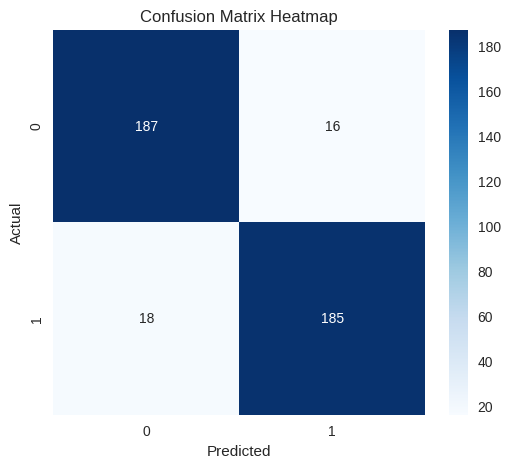

<Figure size 600x500 with 0 Axes>

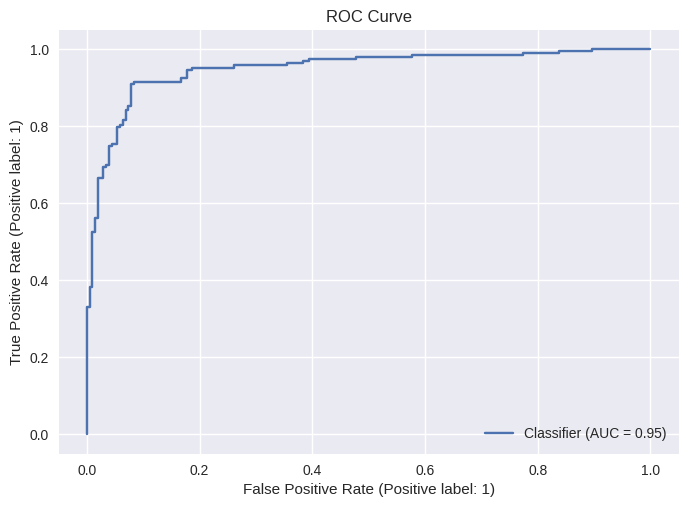

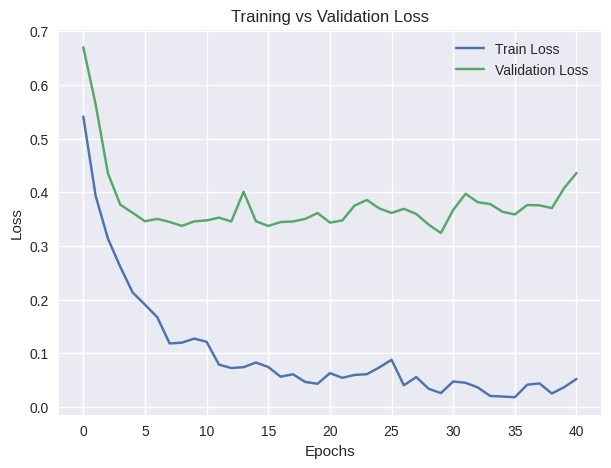

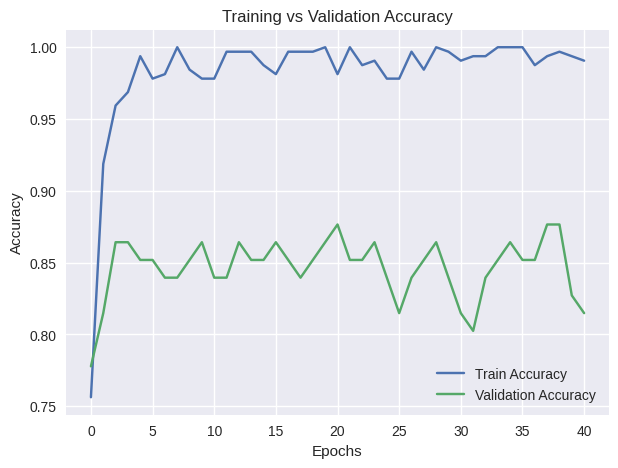

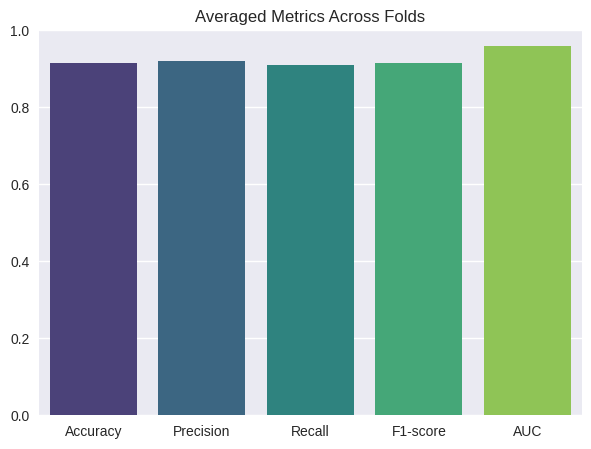

In [149]:
# ----------------------------
# 0️⃣ Imports
# ----------------------------
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay)
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import pennylane as qml
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# 1️⃣ Config
# ----------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

CSV_PATH = "/kaggle/input/heart_failure_clinical_records_dataset.csv"
TOP_FEATURES = ['anaemia', 'creatinine_phosphokinase', 'diabetes',
                'ejection_fraction', 'high_blood_pressure', 'serum_creatinine',
                'serum_sodium', 'smoking']

N_QUBITS = 8
N_LAYERS = 4
HIDDEN_DIM = 128
EPOCHS = 200
BATCH_SIZE = 16
LR = 1e-4
KFOLDS = 5
NOISE_STD = 0.01
PATIENCE = 20

# ----------------------------
# 2️⃣ Load & preprocess
# ----------------------------
df = pd.read_csv(CSV_PATH).dropna().reset_index(drop=True)

# Original class distribution
num_0 = (df["DEATH_EVENT"] == 0).sum()
num_1 = (df["DEATH_EVENT"] == 1).sum()
print("Original Class 0:", num_0, "Class 1:", num_1)

X = df[TOP_FEATURES].values.astype(np.float32)
y = df["DEATH_EVENT"].values.astype(int)

# ----------------------------
# 3️⃣ SMOTE balancing
# ----------------------------
smote = SMOTE(random_state=SEED)
X_resampled, y_resampled = smote.fit_resample(X, y)
print("After SMOTE: Class 0:", (y_resampled==0).sum(), "Class 1:", (y_resampled==1).sum())

# ----------------------------
# 4️⃣ Feature augmentation (Gaussian noise)
# ----------------------------
def augment_features(X, noise_std=NOISE_STD):
    X_aug = X.copy()
    binary_cols = [idx for idx, col in enumerate(TOP_FEATURES) if set(df[col].unique()).issubset({0,1})]
    cont_idx = [i for i in range(X.shape[1]) if i not in binary_cols]
    noise = np.random.normal(0.0, noise_std, size=(X.shape[0], len(cont_idx))).astype(np.float32)
    X_aug[:, cont_idx] += noise
    X_aug[:, cont_idx] = np.clip(X_aug[:, cont_idx], 0.0, np.pi)
    for b in binary_cols:
        X_aug[:, b] = np.round(X_aug[:, b]).astype(np.float32)
    return X_aug

X_res_aug = augment_features(X_resampled)

# ----------------------------
# 5️⃣ Scale features for QNN
# ----------------------------
scaler = MinMaxScaler(feature_range=(0.0, np.pi))
X_scaled = scaler.fit_transform(X_res_aug).astype(np.float32)

# ----------------------------
# 6️⃣ Random Forest features
# ----------------------------
rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=SEED)
rf.fit(X_resampled, y_resampled)
leaf_indices = rf.apply(X_resampled)
ohe = OneHotEncoder(sparse=False)
rf_features = ohe.fit_transform(leaf_indices).astype(np.float32)

# Concatenate scaled features + RF features
X_final = np.hstack([X_scaled, rf_features])
y_final = y_resampled
print("Final input shape to QNN:", X_final.shape)

# ----------------------------
# 7️⃣ Quantum setup
# ----------------------------
dev = qml.device("default.qubit", wires=N_QUBITS)

def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation='Y')
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

weight_shapes = {"weights": (N_LAYERS, N_QUBITS, 3)}
qnode = qml.QNode(quantum_circuit, dev, interface="torch")

# ----------------------------
# 8️⃣ Hybrid QNN Model
# ----------------------------
class HybridQNN(nn.Module):
    def __init__(self, input_dim, hidden_dim=HIDDEN_DIM, n_qubits=N_QUBITS, n_classes=2, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.act1 = nn.LeakyReLU(0.1)
        self.fc2 = nn.Linear(hidden_dim, n_qubits)
        self.q_layer = qml.qnn.TorchLayer(qnode, weight_shapes)
        self.fc3 = nn.Linear(n_qubits, hidden_dim)
        self.bn3 = nn.BatchNorm1d(hidden_dim)
        self.act3 = nn.LeakyReLU(0.1)
        self.dropout = nn.Dropout(dropout)
        self.out = nn.Linear(hidden_dim, n_classes)

    def forward(self, x):
        x = self.act1(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.q_layer(x)
        x = self.act3(self.bn3(self.fc3(x)))
        x = self.dropout(x)
        x = self.out(x)
        return x

# ----------------------------
# 9️⃣ Stratified K-Fold Training with history tracking
# ----------------------------
skf = StratifiedKFold(n_splits=KFOLDS, shuffle=True, random_state=SEED)
fold_metrics = []

# To store epoch-wise history for last fold
train_loss_hist, val_loss_hist = [], []
train_acc_hist, val_acc_hist = [], []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_final, y_final), 1):
    print(f"\n===== Fold {fold}/{KFOLDS} =====")
    
    X_train, X_test = X_final[train_idx], X_final[test_idx]
    y_train, y_test = y_final[train_idx], y_final[test_idx]
    
    train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                             torch.tensor(y_train, dtype=torch.long))
    test_ds = TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                            torch.tensor(y_test, dtype=torch.long))
    
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
    
    model = HybridQNN(input_dim=X_final.shape[1]).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LR)
    
    best_val_acc = 0.0
    patience_counter = 0
    
    # Per-epoch history lists
    train_loss_list, val_loss_list = [], []
    train_acc_list, val_acc_list = [], []
    
    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss, running_correct, running_total = 0.0, 0, 0
        
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            running_correct += (preds == yb).sum().item()
            running_total += xb.size(0)
        
        train_loss = running_loss / running_total
        train_acc = running_correct / running_total
        train_loss_list.append(train_loss)
        train_acc_list.append(train_acc)
        
        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                loss = criterion(logits, yb)
                val_loss += loss.item() * xb.size(0)
                preds = logits.argmax(dim=1)
                val_correct += (preds == yb).sum().item()
                val_total += xb.size(0)
        val_loss /= val_total
        val_acc = val_correct / val_total
        val_loss_list.append(val_loss)
        val_acc_list.append(val_acc)
        
        if val_acc > best_val_acc + 1e-6:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), f"best_fold{fold}.pth")
        else:
            patience_counter += 1
        
        if epoch % 20 == 0 or epoch == 1:
            print(f"Epoch {epoch}/{EPOCHS} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
        
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}.")
            break
    
    # Save last fold history for plotting
    if fold == KFOLDS:
        train_loss_hist, val_loss_hist = train_loss_list, val_loss_list
        train_acc_hist, val_acc_hist = train_acc_list, val_acc_list
    
    # Evaluation on test set
    model.load_state_dict(torch.load(f"best_fold{fold}.pth", map_location=DEVICE))
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            probs = torch.softmax(logits, dim=1)[:,1].cpu().numpy()
            preds = logits.argmax(dim=1).cpu().numpy()
            y_true.extend(yb.numpy())
            y_pred.extend(preds.tolist())
            y_prob.extend(probs.tolist())
    
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_prob)
    except:
        auc = float("nan")
    
    print(f"\nFold {fold} Metrics | Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")
    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:\n", cm)
    fold_metrics.append([acc, prec, rec, f1, auc])

# ----------------------------
# 10️⃣ Average metrics across folds
# ----------------------------
fold_metrics = np.array(fold_metrics)
avg_acc = fold_metrics[:,0].mean()
avg_prec = fold_metrics[:,1].mean()
avg_rec = fold_metrics[:,2].mean()
avg_f1 = fold_metrics[:,3].mean()
avg_auc = np.nanmean(fold_metrics[:,4])

print("\n===== Average across folds =====")
print(f"Accuracy: {avg_acc:.4f} ± {fold_metrics[:,0].std():.4f}")
print(f"Precision: {avg_prec:.4f}")
print(f"Recall: {avg_rec:.4f}")
print(f"F1-score: {avg_f1:.4f}")
print(f"AUC: {avg_auc:.4f}")

# ----------------------------
# 11️⃣ Visualization
# ----------------------------
# Confusion Matrix Heatmap (overall)
all_y_true, all_y_pred, all_y_prob = [], [], []
for fold, (train_idx, test_idx) in enumerate(skf.split(X_final, y_final), 1):
    model.load_state_dict(torch.load(f"best_fold{fold}.pth", map_location=DEVICE))
    model.eval()
    with torch.no_grad():
        X_test_fold = torch.tensor(X_final[test_idx], dtype=torch.float32).to(DEVICE)
        logits = model(X_test_fold)
        preds = logits.argmax(dim=1).cpu().numpy()
        probs = torch.softmax(logits, dim=1)[:,1].cpu().numpy()
    all_y_true.extend(y_final[test_idx])
    all_y_pred.extend(preds)
    all_y_prob.extend(probs)

cm = confusion_matrix(all_y_true, all_y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.show()

# ROC Curve
plt.figure(figsize=(6,5))
RocCurveDisplay.from_predictions(all_y_true, all_y_prob)
plt.title("ROC Curve")
plt.show()

# Train vs Validation Loss
plt.figure(figsize=(7,5))
plt.plot(train_loss_hist, label='Train Loss')
plt.plot(val_loss_hist, label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

# Train vs Validation Accuracy
plt.figure(figsize=(7,5))
plt.plot(train_acc_hist, label='Train Accuracy')
plt.plot(val_acc_hist, label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

# Bar plot of averaged metrics
metrics_dict = {
    "Accuracy": avg_acc,
    "Precision": avg_prec,
    "Recall": avg_rec,
    "F1-score": avg_f1,
    "AUC": avg_auc
}

plt.figure(figsize=(7,5))
sns.barplot(x=list(metrics_dict.keys()), y=list(metrics_dict.values()), palette="viridis")
plt.ylim(0,1)
plt.title("Averaged Metrics Across Folds")
plt.show()



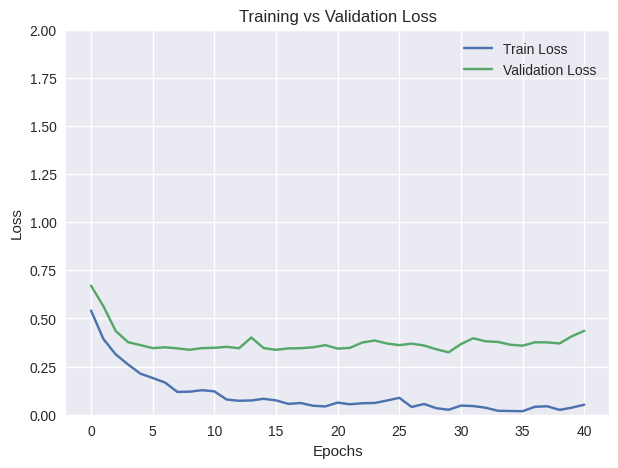

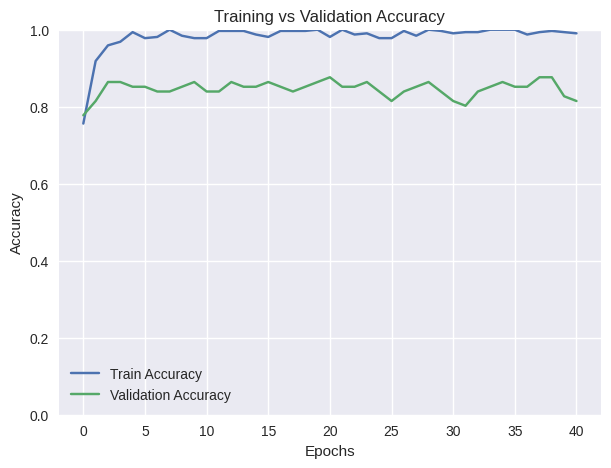

In [150]:
# Train vs Validation Loss
plt.figure(figsize=(7,5))
plt.plot(train_loss_hist, label='Train Loss')
plt.plot(val_loss_hist, label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.ylim(0,2)
plt.show()

# Train vs Validation Accuracy
plt.figure(figsize=(7,5))
plt.plot(train_acc_hist, label='Train Accuracy')
plt.plot(val_acc_hist, label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.ylim(0,1)
plt.show()


In [151]:
#k-fold with 6 qubits

In [152]:
!pip install -U scikit-learn imbalanced-learn


  Using cached scikit_learn-1.7.1-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached imbalanced_learn-0.14.0-py3-none-any.whl.metadata (8.8 kB)
Using cached scikit_learn-1.7.1-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (9.7 MB)
Using cached imbalanced_learn-0.14.0-py3-none-any.whl (239 kB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.10.1
    Uninstalling imbalanced-learn-0.10.1:
      Successfully uninstalled imbalanced-learn-0.10.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.7.1 which is incom

In [153]:
!pip install scikit-learn==1.2.2 imbalanced-learn==0.10.1


  Using cached scikit_learn-1.2.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
  Using cached imbalanced_learn-0.10.1-py3-none-any.whl.metadata (8.2 kB)
Using cached scikit_learn-1.2.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (9.6 MB)
Using cached imbalanced_learn-0.10.1-py3-none-any.whl (226 kB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.7.1
    Uninstalling scikit-learn-1.7.1:
      Successfully uninstalled scikit-learn-1.7.1
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.14.0
    Uninstalling imbalanced-learn-0.14.0:
      Successfully uninstalled imbalanced-learn-0.14.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
nilearn 0.11.1 requires scikit-learn>=1.4.0, but you have scikit-learn 1.2.2 which is incompatible.
bigfram

In [154]:
# ----------------------------
# 0️⃣ Imports
# ----------------------------
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay)
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import pennylane as qml
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# 1️⃣ Config
# ----------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

CSV_PATH = "/kaggle/input/heart_failure_clinical_records_dataset.csv"
TOP_FEATURES = ['anaemia', 'creatinine_phosphokinase', 'diabetes',
                'ejection_fraction', 'high_blood_pressure', 'serum_creatinine',
                'serum_sodium', 'smoking']

# PSO-selected top 6 features
PSO_SELECTED_FEATURES = ['serum_creatinine', 'ejection_fraction', 
                         'creatinine_phosphokinase', 'serum_sodium', 
                         'anaemia', 'high_blood_pressure']

N_QUBITS = 6  # Updated for PSO
N_LAYERS = 4
HIDDEN_DIM = 128
EPOCHS = 200
BATCH_SIZE = 16
LR = 1e-4
KFOLDS = 5
NOISE_STD = 0.01
PATIENCE = 20

# ----------------------------
# 2️⃣ Load & preprocess
# ----------------------------
df = pd.read_csv(CSV_PATH).dropna().reset_index(drop=True)

X = df[TOP_FEATURES].values.astype(np.float32)
y = df["DEATH_EVENT"].values.astype(int)

# ----------------------------
# 3️⃣ SMOTE balancing
# ----------------------------
smote = SMOTE(random_state=SEED)
X_resampled, y_resampled = smote.fit_resample(X, y)

# ----------------------------
# 4️⃣ Feature augmentation
# ----------------------------
def augment_features(X, noise_std=NOISE_STD):
    X_aug = X.copy()
    binary_cols = [idx for idx, col in enumerate(TOP_FEATURES) if set(df[col].unique()).issubset({0,1})]
    cont_idx = [i for i in range(X.shape[1]) if i not in binary_cols]
    noise = np.random.normal(0.0, noise_std, size=(X.shape[0], len(cont_idx))).astype(np.float32)
    X_aug[:, cont_idx] += noise
    X_aug[:, cont_idx] = np.clip(X_aug[:, cont_idx], 0.0, np.pi)
    for b in binary_cols:
        X_aug[:, b] = np.round(X_aug[:, b]).astype(np.float32)
    return X_aug

X_res_aug = augment_features(X_resampled)

# ----------------------------
# 5️⃣ Scale features
# ----------------------------
scaler = MinMaxScaler(feature_range=(0.0, np.pi))
X_scaled = scaler.fit_transform(X_res_aug).astype(np.float32)

# ----------------------------
# 6️⃣ Random Forest features
# ----------------------------
rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=SEED)
rf.fit(X_resampled, y_resampled)
leaf_indices = rf.apply(X_resampled)
ohe = OneHotEncoder(sparse=False)
rf_features = ohe.fit_transform(leaf_indices).astype(np.float32)

# Concatenate scaled features + RF features
X_full = np.hstack([X_scaled, rf_features])
y_final = y_resampled

# ----------------------------
# 7️⃣ Select only PSO features (6 features)
# ----------------------------
feature_idx = [TOP_FEATURES.index(f) for f in PSO_SELECTED_FEATURES]
X_final = X_full[:, feature_idx]  # only top 6 features
print("Final input shape with PSO-selected 6 features:", X_final.shape)

# ----------------------------
# 8️⃣ Quantum setup
# ----------------------------
dev = qml.device("default.qubit", wires=N_QUBITS)

def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation='Y')
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

weight_shapes = {"weights": (N_LAYERS, N_QUBITS, 3)}
qnode = qml.QNode(quantum_circuit, dev, interface="torch")

# ----------------------------
# 9️⃣ Hybrid QNN Model
# ----------------------------
class HybridQNN(nn.Module):
    def __init__(self, input_dim, hidden_dim=HIDDEN_DIM, n_qubits=N_QUBITS, n_classes=2, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.act1 = nn.LeakyReLU(0.1)
        self.fc2 = nn.Linear(hidden_dim, n_qubits)
        self.q_layer = qml.qnn.TorchLayer(qnode, weight_shapes)
        self.fc3 = nn.Linear(n_qubits, hidden_dim)
        self.bn3 = nn.BatchNorm1d(hidden_dim)
        self.act3 = nn.LeakyReLU(0.1)
        self.dropout = nn.Dropout(dropout)
        self.out = nn.Linear(hidden_dim, n_classes)

    def forward(self, x):
        x = self.act1(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.q_layer(x)
        x = self.act3(self.bn3(self.fc3(x)))
        x = self.dropout(x)
        x = self.out(x)
        return x

# ----------------------------
# 10️⃣ Stratified K-Fold Training (6 qubits)
# ----------------------------
skf = StratifiedKFold(n_splits=KFOLDS, shuffle=True, random_state=SEED)
fold_metrics = []

train_loss_hist, val_loss_hist = [], []
train_acc_hist, val_acc_hist = [], []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_final, y_final), 1):
    print(f"\n===== Fold {fold}/{KFOLDS} =====")
    
    X_train, X_test = X_final[train_idx], X_final[test_idx]
    y_train, y_test = y_final[train_idx], y_final[test_idx]
    
    train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                             torch.tensor(y_train, dtype=torch.long))
    test_ds = TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                            torch.tensor(y_test, dtype=torch.long))
    
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
    
    model = HybridQNN(input_dim=X_final.shape[1]).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LR)
    
    best_val_acc = 0.0
    patience_counter = 0
    
    train_loss_list, val_loss_list = [], []
    train_acc_list, val_acc_list = [], []
    
    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss, running_correct, running_total = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            running_correct += (preds == yb).sum().item()
            running_total += xb.size(0)
        
        train_loss = running_loss / running_total
        train_acc = running_correct / running_total
        train_loss_list.append(train_loss)
        train_acc_list.append(train_acc)
        
        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                loss = criterion(logits, yb)
                val_loss += loss.item() * xb.size(0)
                preds = logits.argmax(dim=1)
                val_correct += (preds == yb).sum().item()
                val_total += xb.size(0)
        val_loss /= val_total
        val_acc = val_correct / val_total
        val_loss_list.append(val_loss)
        val_acc_list.append(val_acc)
        
        if val_acc > best_val_acc + 1e-6:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), f"best_fold{fold}_6qubits.pth")
        else:
            patience_counter += 1
        
        if epoch % 20 == 0 or epoch == 1:
            print(f"Epoch {epoch}/{EPOCHS} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
        
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}.")
            break
    
    # Save last fold history for plotting
    if fold == KFOLDS:
        train_loss_hist, val_loss_hist = train_loss_list, val_loss_list
        train_acc_hist, val_acc_hist = train_acc_list, val_acc_list
    
    # Evaluation on test set
    model.load_state_dict(torch.load(f"best_fold{fold}_6qubits.pth", map_location=DEVICE))
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            probs = torch.softmax(logits, dim=1)[:,1].cpu().numpy()
            preds = logits.argmax(dim=1).cpu().numpy()
            y_true.extend(yb.numpy())
            y_pred.extend(preds.tolist())
            y_prob.extend(probs.tolist())
    
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_prob)
    except:
        auc = float("nan")
    
    print(f"\nFold {fold} Metrics | Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")
    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:\n", cm)
    fold_metrics.append([acc, prec, rec, f1, auc])

# ----------------------------
# 11️⃣ Average metrics
# ----------------------------
fold_metrics = np.array(fold_metrics)
avg_acc = fold_metrics[:,0].mean()
avg_prec = fold_metrics[:,1].mean()
avg_rec = fold_metrics[:,2].mean()
avg_f1 = fold_metrics[:,3].mean()
avg_auc = np.nanmean(fold_metrics[:,4])

print("\n===== Average across folds (6 Qubits) =====")
print(f"Accuracy: {avg_acc:.4f} ± {fold_metrics[:,0].std():.4f}")
print(f"Precision: {avg_prec:.4f}")
print(f"Recall: {avg_rec:.4f}")
print(f"F1-score: {avg_f1:.4f}")
print(f"AUC: {avg_auc:.4f}")


Final input shape with PSO-selected 6 features: (406, 6)

===== Fold 1/5 =====
Epoch 1/200 | Train Acc: 0.5437 | Val Acc: 0.5000
Epoch 20/200 | Train Acc: 0.6625 | Val Acc: 0.6585
Epoch 40/200 | Train Acc: 0.6781 | Val Acc: 0.6951
Early stopping at epoch 50.

Fold 1 Metrics | Acc: 0.7073 | Prec: 0.7576 | Rec: 0.6098 | F1: 0.6757 | AUC: 0.7540
Confusion Matrix:
 [[33  8]
 [16 25]]

===== Fold 2/5 =====
Epoch 1/200 | Train Acc: 0.5000 | Val Acc: 0.4691
Epoch 20/200 | Train Acc: 0.6875 | Val Acc: 0.6790
Early stopping at epoch 24.

Fold 2 Metrics | Acc: 0.6790 | Prec: 0.7586 | Rec: 0.5366 | F1: 0.6286 | AUC: 0.7177
Confusion Matrix:
 [[33  7]
 [19 22]]

===== Fold 3/5 =====
Epoch 1/200 | Train Acc: 0.5656 | Val Acc: 0.5679
Epoch 20/200 | Train Acc: 0.6719 | Val Acc: 0.7407
Early stopping at epoch 32.

Fold 3 Metrics | Acc: 0.7407 | Prec: 0.8125 | Rec: 0.6341 | F1: 0.7123 | AUC: 0.7436
Confusion Matrix:
 [[34  6]
 [15 26]]

===== Fold 4/5 =====
Epoch 1/200 | Train Acc: 0.5344 | Val Acc: 0.

In [155]:
#without k-fold 8-qubits for 100 epochs

Epoch 1/100 | Train Acc: 0.6906 | Val Acc: 0.5926
Epoch 2/100 | Train Acc: 0.8562 | Val Acc: 0.8272
Epoch 3/100 | Train Acc: 0.9281 | Val Acc: 0.8395
Epoch 4/100 | Train Acc: 0.9688 | Val Acc: 0.8272
Epoch 5/100 | Train Acc: 0.9750 | Val Acc: 0.8395
Epoch 6/100 | Train Acc: 0.9781 | Val Acc: 0.8519
Epoch 7/100 | Train Acc: 0.9719 | Val Acc: 0.8395
Epoch 8/100 | Train Acc: 0.9844 | Val Acc: 0.8395
Epoch 9/100 | Train Acc: 0.9969 | Val Acc: 0.8395
Epoch 10/100 | Train Acc: 0.9969 | Val Acc: 0.8272
Epoch 11/100 | Train Acc: 0.9844 | Val Acc: 0.8395
Epoch 12/100 | Train Acc: 0.9938 | Val Acc: 0.8395
Epoch 13/100 | Train Acc: 1.0000 | Val Acc: 0.8395
Epoch 14/100 | Train Acc: 0.9812 | Val Acc: 0.8889
Epoch 15/100 | Train Acc: 0.9844 | Val Acc: 0.8642
Epoch 16/100 | Train Acc: 0.9938 | Val Acc: 0.8395
Epoch 17/100 | Train Acc: 0.9750 | Val Acc: 0.8765
Epoch 18/100 | Train Acc: 0.9812 | Val Acc: 0.8642
Epoch 19/100 | Train Acc: 0.9875 | Val Acc: 0.8272
Epoch 20/100 | Train Acc: 1.0000 | Val A

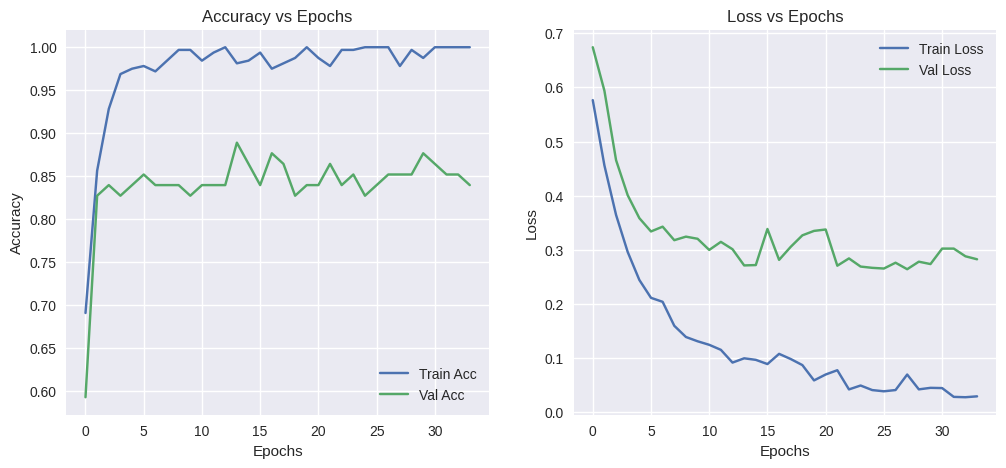

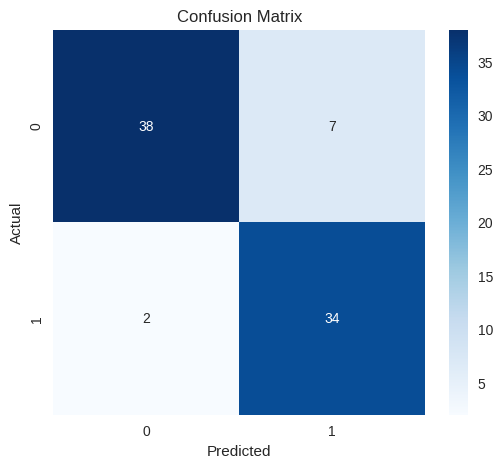

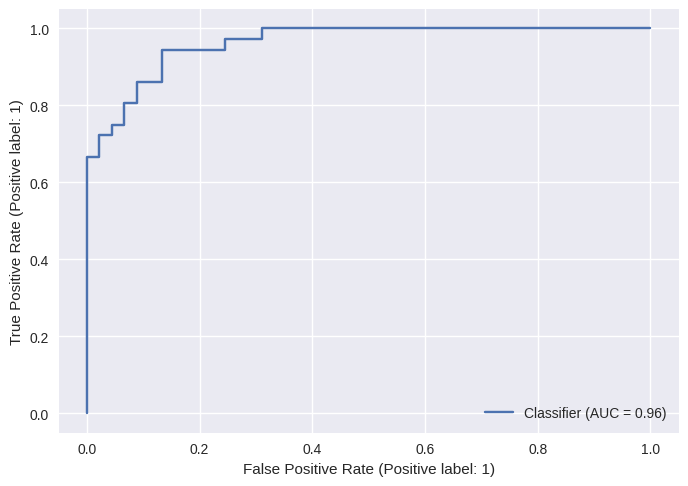

In [156]:
# ----------------------------
# 0️⃣ Imports
# ----------------------------
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay)
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import pennylane as qml
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# 1️⃣ Config
# ----------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

CSV_PATH = "/kaggle/input/heart_failure_clinical_records_dataset.csv"
TOP_FEATURES = ['anaemia', 'creatinine_phosphokinase', 'diabetes',
                'ejection_fraction', 'high_blood_pressure', 'serum_creatinine',
                'serum_sodium', 'smoking']

N_QUBITS = 8
N_LAYERS = 4
HIDDEN_DIM = 128
EPOCHS = 100
BATCH_SIZE = 16
LR = 1e-4
NOISE_STD = 0.01
PATIENCE = 20
TEST_RATIO = 0.2  # 20% test split

# ----------------------------
# 2️⃣ Load & preprocess
# ----------------------------
df = pd.read_csv(CSV_PATH).dropna().reset_index(drop=True)

X = df[TOP_FEATURES].values.astype(np.float32)
y = df["DEATH_EVENT"].values.astype(int)

# ----------------------------
# 3️⃣ SMOTE balancing
# ----------------------------
smote = SMOTE(random_state=SEED)
X_resampled, y_resampled = smote.fit_resample(X, y)

# ----------------------------
# 4️⃣ Feature augmentation
# ----------------------------
def augment_features(X, noise_std=NOISE_STD):
    X_aug = X.copy()
    binary_cols = [idx for idx, col in enumerate(TOP_FEATURES) if set(df[col].unique()).issubset({0,1})]
    cont_idx = [i for i in range(X.shape[1]) if i not in binary_cols]
    noise = np.random.normal(0.0, noise_std, size=(X.shape[0], len(cont_idx))).astype(np.float32)
    X_aug[:, cont_idx] += noise
    X_aug[:, cont_idx] = np.clip(X_aug[:, cont_idx], 0.0, np.pi)
    for b in binary_cols:
        X_aug[:, b] = np.round(X_aug[:, b]).astype(np.float32)
    return X_aug

X_res_aug = augment_features(X_resampled)

# ----------------------------
# 5️⃣ Scale features
# ----------------------------
scaler = MinMaxScaler(feature_range=(0.0, np.pi))
X_scaled = scaler.fit_transform(X_res_aug).astype(np.float32)

# ----------------------------
# 6️⃣ Random Forest features
# ----------------------------
rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=SEED)
rf.fit(X_resampled, y_resampled)
leaf_indices = rf.apply(X_resampled)
ohe = OneHotEncoder(sparse=False)
rf_features = ohe.fit_transform(leaf_indices).astype(np.float32)

X_final = np.hstack([X_scaled, rf_features])
y_final = y_resampled

# ----------------------------
# 7️⃣ Train/Test split
# ----------------------------
num_samples = X_final.shape[0]
num_test = int(TEST_RATIO * num_samples)
num_train = num_samples - num_test

indices = np.arange(num_samples)
np.random.shuffle(indices)

train_idx = indices[:num_train]
test_idx = indices[num_train:]

X_train, X_test = X_final[train_idx], X_final[test_idx]
y_train, y_test = y_final[train_idx], y_final[test_idx]

train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                         torch.tensor(y_train, dtype=torch.long))
test_ds = TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                        torch.tensor(y_test, dtype=torch.long))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# ----------------------------
# 8️⃣ Quantum setup
# ----------------------------
dev = qml.device("default.qubit", wires=N_QUBITS)
def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation='Y')
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

weight_shapes = {"weights": (N_LAYERS, N_QUBITS, 3)}
qnode = qml.QNode(quantum_circuit, dev, interface="torch")

# ----------------------------
# 9️⃣ Hybrid QNN Model
# ----------------------------
class HybridQNN(nn.Module):
    def __init__(self, input_dim, hidden_dim=HIDDEN_DIM, n_qubits=N_QUBITS, n_classes=2, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.act1 = nn.LeakyReLU(0.1)
        self.fc2 = nn.Linear(hidden_dim, n_qubits)
        self.q_layer = qml.qnn.TorchLayer(qnode, weight_shapes)
        self.fc3 = nn.Linear(n_qubits, hidden_dim)
        self.bn3 = nn.BatchNorm1d(hidden_dim)
        self.act3 = nn.LeakyReLU(0.1)
        self.dropout = nn.Dropout(dropout)
        self.out = nn.Linear(hidden_dim, n_classes)

    def forward(self, x):
        x = self.act1(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.q_layer(x)
        x = self.act3(self.bn3(self.fc3(x)))
        x = self.dropout(x)
        x = self.out(x)
        return x

model = HybridQNN(input_dim=X_final.shape[1]).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR)

# ----------------------------
# 10️⃣ Training loop
# ----------------------------
train_acc_list, val_acc_list, train_loss_list, val_loss_list = [], [], [], []
best_val_acc = 0.0
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss, running_correct, running_total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == yb).sum().item()
        running_total += xb.size(0)
    train_loss = running_loss / running_total
    train_acc = running_correct / running_total
    train_acc_list.append(train_acc)
    train_loss_list.append(train_loss)

    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            val_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            val_correct += (preds == yb).sum().item()
            val_total += xb.size(0)
            y_true.extend(yb.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(torch.softmax(logits, dim=1)[:,1].cpu().numpy())
    val_loss /= val_total
    val_acc = val_correct / val_total
    val_acc_list.append(val_acc)
    val_loss_list.append(val_loss)

    if val_acc > best_val_acc + 1e-6:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        patience_counter += 1

    print(f"Epoch {epoch}/{EPOCHS} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    if patience_counter >= PATIENCE:
        print(f"Early stopping at epoch {epoch}.")
        break

# ----------------------------
# 11️⃣ Load best model & metrics
# ----------------------------
model.load_state_dict(torch.load("best_model.pth", map_location=DEVICE))
model.eval()
y_true, y_pred, y_prob = [], [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        logits = model(xb)
        probs = torch.softmax(logits, dim=1)[:,1].cpu().numpy()
        preds = logits.argmax(dim=1).cpu().numpy()
        y_true.extend(yb.numpy())
        y_pred.extend(preds)
        y_prob.extend(probs)

# Metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob)
cm = confusion_matrix(y_true, y_pred)

print("\nFinal Metrics:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"AUC: {auc:.4f}")
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", classification_report(y_true, y_pred))

# ----------------------------
# 12️⃣ Plots
# ----------------------------
# Accuracy & Loss
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_acc_list, label='Train Acc')
plt.plot(val_acc_list, label='Val Acc')
plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.title('Accuracy vs Epochs'); plt.legend()

plt.subplot(1,2,2)
plt.plot(train_loss_list, label='Train Loss')
plt.plot(val_loss_list, label='Val Loss')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.title('Loss vs Epochs'); plt.legend()
plt.show()

# Confusion Matrix Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix")
plt.show()

# ROC Curve
RocCurveDisplay.from_predictions(y_true, y_prob)
plt.show()


In [157]:
# without k-fold for 6 qubits for 100 epochs

Final input shape with PSO-selected 6 features: (406, 6)
Epoch 1/100 | Train Acc: 0.5500 | Val Acc: 0.5556
Epoch 2/100 | Train Acc: 0.6000 | Val Acc: 0.6173
Epoch 3/100 | Train Acc: 0.5687 | Val Acc: 0.6296
Epoch 4/100 | Train Acc: 0.5875 | Val Acc: 0.6543
Epoch 5/100 | Train Acc: 0.5781 | Val Acc: 0.6543
Epoch 6/100 | Train Acc: 0.6094 | Val Acc: 0.6543
Epoch 7/100 | Train Acc: 0.6250 | Val Acc: 0.6543
Epoch 8/100 | Train Acc: 0.6344 | Val Acc: 0.6543
Epoch 9/100 | Train Acc: 0.6562 | Val Acc: 0.6667
Epoch 10/100 | Train Acc: 0.6219 | Val Acc: 0.6543
Epoch 11/100 | Train Acc: 0.6687 | Val Acc: 0.6543
Epoch 12/100 | Train Acc: 0.6625 | Val Acc: 0.6543
Epoch 13/100 | Train Acc: 0.6438 | Val Acc: 0.6543
Epoch 14/100 | Train Acc: 0.6625 | Val Acc: 0.6543
Epoch 15/100 | Train Acc: 0.6875 | Val Acc: 0.6543
Epoch 16/100 | Train Acc: 0.6312 | Val Acc: 0.6543
Epoch 17/100 | Train Acc: 0.6625 | Val Acc: 0.6543
Epoch 18/100 | Train Acc: 0.6687 | Val Acc: 0.6543
Epoch 19/100 | Train Acc: 0.7125 |

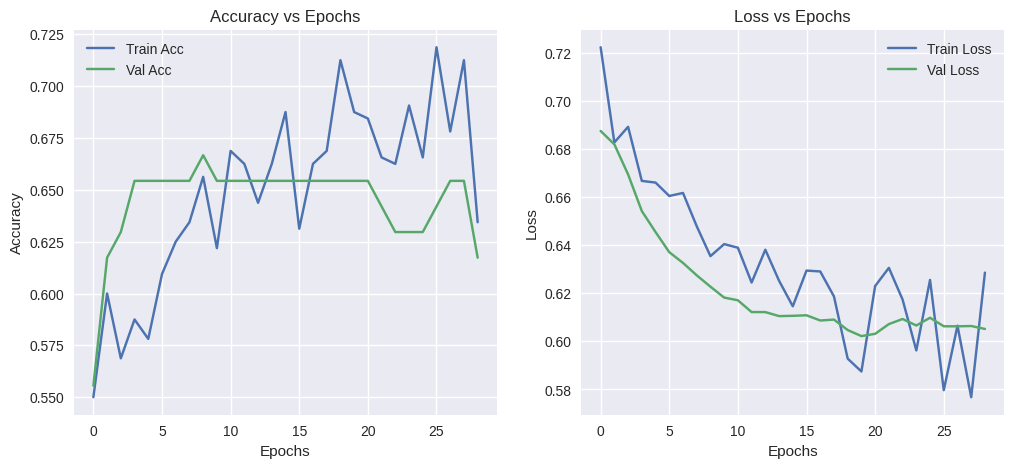

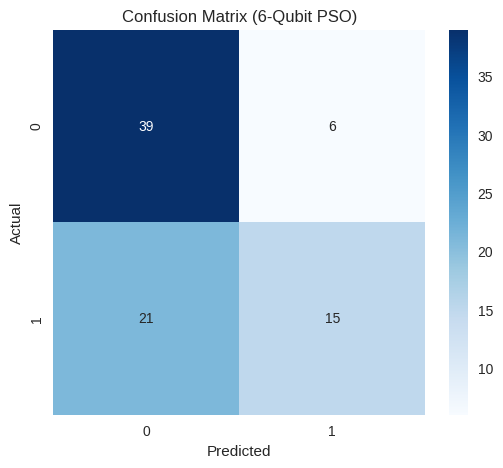

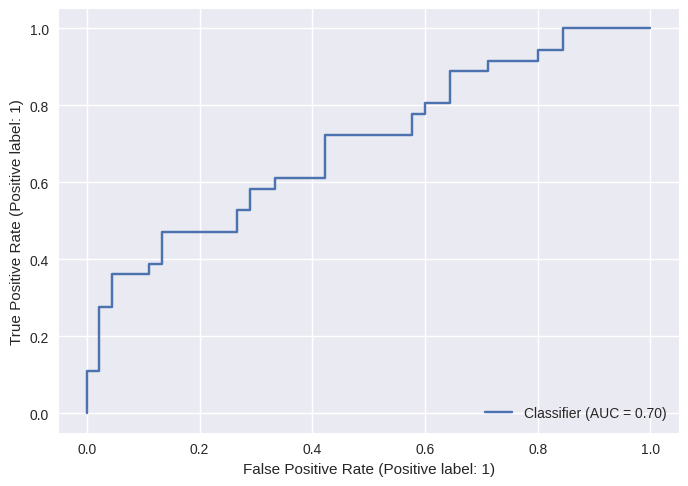

In [158]:
# ----------------------------
# 0️⃣ Imports
# ----------------------------
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay)
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import pennylane as qml
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# 1️⃣ Config
# ----------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

CSV_PATH = "/kaggle/input/heart_failure_clinical_records_dataset.csv"
TOP_FEATURES = ['anaemia', 'creatinine_phosphokinase', 'diabetes',
                'ejection_fraction', 'high_blood_pressure', 'serum_creatinine',
                'serum_sodium', 'smoking']

# Suppose PSO selected these 6 top features (example)
PSO_SELECTED_FEATURES = ['serum_creatinine', 'ejection_fraction', 'creatinine_phosphokinase',
                         'serum_sodium', 'anaemia', 'high_blood_pressure']

N_QUBITS = 6  # Use only 6 qubits now
N_LAYERS = 4
HIDDEN_DIM = 128
EPOCHS = 100
BATCH_SIZE = 16
LR = 1e-4
NOISE_STD = 0.01
PATIENCE = 20
TEST_RATIO = 0.2

# ----------------------------
# 2️⃣ Load & preprocess
# ----------------------------
df = pd.read_csv(CSV_PATH).dropna().reset_index(drop=True)

X = df[TOP_FEATURES].values.astype(np.float32)
y = df["DEATH_EVENT"].values.astype(int)

# ----------------------------
# 3️⃣ SMOTE balancing
# ----------------------------
smote = SMOTE(random_state=SEED)
X_resampled, y_resampled = smote.fit_resample(X, y)

# ----------------------------
# 4️⃣ Feature augmentation
# ----------------------------
def augment_features(X, noise_std=NOISE_STD):
    X_aug = X.copy()
    binary_cols = [idx for idx, col in enumerate(TOP_FEATURES) if set(df[col].unique()).issubset({0,1})]
    cont_idx = [i for i in range(X.shape[1]) if i not in binary_cols]
    noise = np.random.normal(0.0, noise_std, size=(X.shape[0], len(cont_idx))).astype(np.float32)
    X_aug[:, cont_idx] += noise
    X_aug[:, cont_idx] = np.clip(X_aug[:, cont_idx], 0.0, np.pi)
    for b in binary_cols:
        X_aug[:, b] = np.round(X_aug[:, b]).astype(np.float32)
    return X_aug

X_res_aug = augment_features(X_resampled)

# ----------------------------
# 5️⃣ Scale features
# ----------------------------
scaler = MinMaxScaler(feature_range=(0.0, np.pi))
X_scaled = scaler.fit_transform(X_res_aug).astype(np.float32)

# ----------------------------
# 6️⃣ Random Forest features
# ----------------------------
rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=SEED)
rf.fit(X_resampled, y_resampled)
leaf_indices = rf.apply(X_resampled)
ohe = OneHotEncoder(sparse=False)
rf_features = ohe.fit_transform(leaf_indices).astype(np.float32)

X_final = np.hstack([X_scaled, rf_features])
y_final = y_resampled

# ----------------------------
# 7️⃣ Select only PSO features
# ----------------------------
feature_idx = [TOP_FEATURES.index(f) for f in PSO_SELECTED_FEATURES]
X_final_pso = X_final[:, feature_idx]  # select only 6 features
print("Final input shape with PSO-selected 6 features:", X_final_pso.shape)

# ----------------------------
# 8️⃣ Train/Test split
# ----------------------------
num_samples = X_final_pso.shape[0]
num_test = int(TEST_RATIO * num_samples)
num_train = num_samples - num_test

indices = np.arange(num_samples)
np.random.shuffle(indices)
train_idx = indices[:num_train]
test_idx = indices[num_train:]

X_train, X_test = X_final_pso[train_idx], X_final_pso[test_idx]
y_train, y_test = y_final[train_idx], y_final[test_idx]

train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                         torch.tensor(y_train, dtype=torch.long))
test_ds = TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                        torch.tensor(y_test, dtype=torch.long))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# ----------------------------
# 9️⃣ Quantum setup
# ----------------------------
dev = qml.device("default.qubit", wires=N_QUBITS)
def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation='Y')
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

weight_shapes = {"weights": (N_LAYERS, N_QUBITS, 3)}
qnode = qml.QNode(quantum_circuit, dev, interface="torch")

# ----------------------------
# 10️⃣ Hybrid QNN Model
# ----------------------------
class HybridQNN(nn.Module):
    def __init__(self, input_dim, hidden_dim=HIDDEN_DIM, n_qubits=N_QUBITS, n_classes=2, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.act1 = nn.LeakyReLU(0.1)
        self.fc2 = nn.Linear(hidden_dim, n_qubits)
        self.q_layer = qml.qnn.TorchLayer(qnode, weight_shapes)
        self.fc3 = nn.Linear(n_qubits, hidden_dim)
        self.bn3 = nn.BatchNorm1d(hidden_dim)
        self.act3 = nn.LeakyReLU(0.1)
        self.dropout = nn.Dropout(dropout)
        self.out = nn.Linear(hidden_dim, n_classes)

    def forward(self, x):
        x = self.act1(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.q_layer(x)
        x = self.act3(self.bn3(self.fc3(x)))
        x = self.dropout(x)
        x = self.out(x)
        return x

model = HybridQNN(input_dim=X_final_pso.shape[1]).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR)

# ----------------------------
# 11️⃣ Training loop (same as before)
# ----------------------------
train_acc_list, val_acc_list, train_loss_list, val_loss_list = [], [], [], []
best_val_acc = 0.0
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss, running_correct, running_total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == yb).sum().item()
        running_total += xb.size(0)
    train_loss = running_loss / running_total
    train_acc = running_correct / running_total
    train_acc_list.append(train_acc)
    train_loss_list.append(train_loss)

    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            val_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            val_correct += (preds == yb).sum().item()
            val_total += xb.size(0)
            y_true.extend(yb.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(torch.softmax(logits, dim=1)[:,1].cpu().numpy())
    val_loss /= val_total
    val_acc = val_correct / val_total
    val_acc_list.append(val_acc)
    val_loss_list.append(val_loss)

    if val_acc > best_val_acc + 1e-6:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), "best_model_pso6.pth")
    else:
        patience_counter += 1

    print(f"Epoch {epoch}/{EPOCHS} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    if patience_counter >= PATIENCE:
        print(f"Early stopping at epoch {epoch}.")
        break

# ----------------------------
# 12️⃣ Evaluate & plot (same as before)
# ----------------------------
model.load_state_dict(torch.load("best_model_pso6.pth", map_location=DEVICE))
model.eval()
y_true, y_pred, y_prob = [], [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        logits = model(xb)
        probs = torch.softmax(logits, dim=1)[:,1].cpu().numpy()
        preds = logits.argmax(dim=1).cpu().numpy()
        y_true.extend(yb.numpy())
        y_pred.extend(preds)
        y_prob.extend(probs)

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob)
cm = confusion_matrix(y_true, y_pred)

print("\nFinal Metrics (6-Qubit PSO):")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"AUC: {auc:.4f}")
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", classification_report(y_true, y_pred))

# Plots
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_acc_list, label='Train Acc')
plt.plot(val_acc_list, label='Val Acc')
plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.title('Accuracy vs Epochs'); plt.legend()

plt.subplot(1,2,2)
plt.plot(train_loss_list, label='Train Loss')
plt.plot(val_loss_list, label='Val Loss')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.title('Loss vs Epochs'); plt.legend()
plt.show()

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix (6-Qubit PSO)")
plt.show()

RocCurveDisplay.from_predictions(y_true, y_prob)
plt.show()


In [159]:
#k-fold with 8-qubit with deepQNN

In [160]:
pip install --upgrade imbalanced-learn


  Using cached imbalanced_learn-0.14.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached scikit_learn-1.7.1-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
Using cached imbalanced_learn-0.14.0-py3-none-any.whl (239 kB)
Using cached scikit_learn-1.7.1-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (9.7 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.10.1
    Uninstalling imbalanced-learn-0.10.1:
      Successfully uninstalled imbalanced-learn-0.10.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.7.1 which is incom

In [161]:
pip install imbalanced-learn==0.14.0


Note: you may need to restart the kernel to use updated packages.


In [162]:
!pip install scikit-learn==1.2.2


  Using cached scikit_learn-1.2.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
Using cached scikit_learn-1.2.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (9.6 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.7.1
    Uninstalling scikit-learn-1.7.1:
      Successfully uninstalled scikit-learn-1.7.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
imbalanced-learn 0.14.0 requires scikit-learn<2,>=1.4.2, but you have scikit-learn 1.2.2 which is incompatible.
nilearn 0.11.1 requires scikit-learn>=1.4.0, but you have scikit-learn 1.2.2 which is incompatible.
bigframes 1.36.0 requires rich<14,>=12.4.4, but you have rich 14.0.0 which is incompatible.
mlxtend 0.23.4 requires scikit-learn>=1.3.1, but you have scikit-learn 1.2.2 which is incompatible.


In [163]:
!pip install imbalanced-learn==0.10.1


  Using cached imbalanced_learn-0.10.1-py3-none-any.whl.metadata (8.2 kB)
Using cached imbalanced_learn-0.10.1-py3-none-any.whl (226 kB)
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.14.0
    Uninstalling imbalanced-learn-0.14.0:
      Successfully uninstalled imbalanced-learn-0.14.0


In [164]:
# ----------------------------
# 0️⃣ Imports
# ----------------------------
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
import pennylane as qml

# ----------------------------
# 1️⃣ Config
# ----------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

CSV_PATH = "/kaggle/input/heart_failure_clinical_records_dataset.csv"
TOP_FEATURES = ['anaemia', 'creatinine_phosphokinase', 'diabetes',
                'ejection_fraction', 'high_blood_pressure', 'serum_creatinine',
                'serum_sodium', 'smoking']  # PSO-selected
N_QUBITS = 8
N_LAYERS = 6        # deep QNN
HIDDEN_DIM = 128
BATCH_SIZE = 16
EPOCHS = 200
LR = 1e-4
KFOLDS = 5
NOISE_STD = 0.01
PATIENCE = 25

# ----------------------------
# 2️⃣ Load & preprocess
# ----------------------------
df = pd.read_csv(CSV_PATH).dropna().reset_index(drop=True)
X_raw = df[TOP_FEATURES].values.astype(np.float32)
y_raw = df["DEATH_EVENT"].values.astype(int)

# ----------------------------
# 2a. SMOTE balancing
# ----------------------------
smote = SMOTE(random_state=SEED)
X_res, y_res = smote.fit_resample(X_raw, y_raw)

# ----------------------------
# 2b. Scale features to [0, pi] for AngleEmbedding
# ----------------------------
scaler = MinMaxScaler(feature_range=(0.0, np.pi))
X_scaled = scaler.fit_transform(X_res).astype(np.float32)

# ----------------------------
# 2c. Data augmentation (Gaussian noise on continuous features)
# ----------------------------
def augment_features(X, noise_std=NOISE_STD):
    X_aug = X.copy()
    binary_cols = [i for i, col in enumerate(TOP_FEATURES) if set(df[col].unique()).issubset({0,1})]
    cont_idx = [i for i in range(X.shape[1]) if i not in binary_cols]
    noise = np.random.normal(0.0, noise_std, size=(X.shape[0], len(cont_idx))).astype(np.float32)
    X_aug[:, cont_idx] += noise
    X_aug[:, cont_idx] = np.clip(X_aug[:, cont_idx], 0.0, np.pi)
    for b in binary_cols:
        X_aug[:, b] = np.round(X_aug[:, b]).astype(np.float32)
    return X_aug

X_aug = augment_features(X_scaled, NOISE_STD)
X_all = np.vstack([X_scaled, X_aug])
y_all = np.hstack([y_res, y_res])

# ----------------------------
# 3️⃣ Quantum Device & QNode
# ----------------------------
dev = qml.device("default.qubit", wires=N_QUBITS)

def quantum_circuit(inputs, weights):
    # Data re-uploading
    for _ in range(2):  # repeat embedding for expressivity
        qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation='Y')
        qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

weight_shapes = {"weights": (N_LAYERS, N_QUBITS, 3)}
qnode = qml.QNode(quantum_circuit, dev, interface="torch")

# TorchLayer wraps QNode
q_layer = qml.qnn.TorchLayer(qnode, weight_shapes)

# ----------------------------
# 4️⃣ Hybrid QNN Model
# ----------------------------
class HybridQNN(nn.Module):
    def __init__(self, n_features=len(TOP_FEATURES), n_qubits=N_QUBITS, hidden_dim=HIDDEN_DIM, n_classes=2, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(n_features, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.act1 = nn.LeakyReLU(0.1)
        self.fc2 = nn.Linear(hidden_dim, n_qubits)
        self.q_layer = q_layer
        self.fc3 = nn.Linear(n_qubits, hidden_dim)
        self.bn3 = nn.BatchNorm1d(hidden_dim)
        self.act3 = nn.LeakyReLU(0.1)
        self.dropout = nn.Dropout(dropout)
        self.out = nn.Linear(hidden_dim, n_classes)
        
    def forward(self, x):
        x = self.act1(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.q_layer(x)
        x = self.act3(self.bn3(self.fc3(x)))
        x = self.dropout(x)
        x = self.out(x)
        return x

# ----------------------------
# 5️⃣ Stratified K-Fold Training
# ----------------------------
skf = StratifiedKFold(n_splits=KFOLDS, shuffle=True, random_state=SEED)
fold_metrics = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_all, y_all), 1):
    print(f"\n===== Fold {fold}/{KFOLDS} =====")
    X_train, X_test = X_all[train_idx], X_all[test_idx]
    y_train, y_test = y_all[train_idx], y_all[test_idx]

    train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                             torch.tensor(y_train, dtype=torch.long))
    test_ds = TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                            torch.tensor(y_test, dtype=torch.long))

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    model = HybridQNN().to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

    best_val_acc = 0.0
    patience_counter = 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss, running_correct, running_total = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            running_correct += (preds == yb).sum().item()
            running_total += xb.size(0)
        train_loss = running_loss / running_total
        train_acc = running_correct / running_total

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                loss = criterion(logits, yb)
                val_loss += loss.item() * xb.size(0)
                preds = logits.argmax(dim=1)
                val_correct += (preds == yb).sum().item()
                val_total += xb.size(0)
        val_loss /= val_total
        val_acc = val_correct / val_total

        if val_acc > best_val_acc + 1e-6:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), f"best_qnn_fold{fold}.pth")
        else:
            patience_counter += 1

        print(f"Epoch {epoch:03d}/{EPOCHS} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}.")
            break

    # Evaluation
    model.load_state_dict(torch.load(f"best_qnn_fold{fold}.pth", map_location=DEVICE))
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            preds = logits.argmax(dim=1).cpu().numpy()
            y_true.extend(yb.numpy())
            y_pred.extend(preds.tolist())
            y_prob.extend(probs.tolist())

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n=== Fold {fold} Metrics ===")
    print(f"Accuracy: {acc:.4f} Precision: {prec:.4f} Recall: {rec:.4f} F1: {f1:.4f} AUC: {auc:.4f}")
    print("Confusion Matrix:\n", cm)
    fold_metrics.append([acc, prec, rec, f1, auc])

# ----------------------------
# 6️⃣ Average Metrics Across Folds
# ----------------------------
fold_metrics = np.array(fold_metrics)
print("\n===== Average Metrics =====")
print(f"Accuracy: {fold_metrics[:,0].mean():.4f} ± {fold_metrics[:,0].std():.4f}")
print(f"Precision: {fold_metrics[:,1].mean():.4f}")
print(f"Recall: {fold_metrics[:,2].mean():.4f}")
print(f"F1: {fold_metrics[:,3].mean():.4f}")
print(f"AUC: {fold_metrics[:,4].mean():.4f}")



===== Fold 1/5 =====
Epoch 001/200 | Train Acc: 0.4828 | Val Acc: 0.4908
Epoch 002/200 | Train Acc: 0.5188 | Val Acc: 0.5092
Epoch 003/200 | Train Acc: 0.4891 | Val Acc: 0.5215
Epoch 004/200 | Train Acc: 0.5531 | Val Acc: 0.5337
Epoch 005/200 | Train Acc: 0.5391 | Val Acc: 0.5521
Epoch 006/200 | Train Acc: 0.5781 | Val Acc: 0.5460
Epoch 007/200 | Train Acc: 0.5766 | Val Acc: 0.6135
Epoch 008/200 | Train Acc: 0.6094 | Val Acc: 0.6258
Epoch 009/200 | Train Acc: 0.5953 | Val Acc: 0.6258
Epoch 010/200 | Train Acc: 0.6375 | Val Acc: 0.6380
Epoch 011/200 | Train Acc: 0.6484 | Val Acc: 0.6687
Epoch 012/200 | Train Acc: 0.6422 | Val Acc: 0.6564
Epoch 013/200 | Train Acc: 0.6672 | Val Acc: 0.6871
Epoch 014/200 | Train Acc: 0.6469 | Val Acc: 0.6748
Epoch 015/200 | Train Acc: 0.6469 | Val Acc: 0.6994
Epoch 016/200 | Train Acc: 0.6484 | Val Acc: 0.7178
Epoch 017/200 | Train Acc: 0.6844 | Val Acc: 0.7301
Epoch 018/200 | Train Acc: 0.6719 | Val Acc: 0.7301
Epoch 019/200 | Train Acc: 0.7031 | Val Ac

<ul>
    <li style = "color:darkred;font-weight:bold" > <p style = "color:black;font-weight:400" > <strong> We can take a look at the improvement by examining the graph again. </strong> </p> </li>
</ul>

<ul>
    <li style = "color:darkred;font-weight:bold" > <p style = "color:black;font-weight:400" > <strong> You can take a look at the change by comparing it with the skew chart above. </strong> </p> </li>
</ul>

Modeling </h2>